# TFM — SERVICIO DE INSPECCIÓN DEL WASHINTONG COUNTY



In [ ]:

# # ============================================================
# 0. CONFIGURACIÓN DEL PROYECTO
# ============================================================

from pathlib import Path
import os

# Carpeta temporal
PROJECT_DIR = Path('/content/TFM_INSPECCIONES')

# Carpeta donde se guardará
DATA_DIR = PROJECT_DIR / 'datos'

# Carpeta donde se guardarán  los resultados
OUTPUT_DIR = PROJECT_DIR / 'resultados'

# Crear carpetas
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("==========================================")
print("CONFIGURACIÓN DEL PROYECTO")
print("==========================================")
print("Proyecto :", PROJECT_DIR)
print("Datos    :", DATA_DIR)
print("Resultados:", OUTPUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Proyecto: /content/drive/MyDrive/TFM_INSPECCIONES
Datos: /content/drive/MyDrive/TFM_INSPECCIONES/01_datos
Resultados: /content/drive/MyDrive/TFM_INSPECCIONES/02_resultados


In [ ]:
# ============================================================
# 3. DESCARGA GITHUB
# ============================================================

import urllib.request
from pathlib import Path

# Nombre del archivo
CSV_NAME = "export(12)(1).csv"

# Ubicación donde se guardará temporalmente en Colab
CSV_PATH = DATA_DIR / CSV_NAME


# ============================================================
# CONFIGURACIÓN DE GITHUB
# ============================================================

GITHUB_USER = "antigona22ljm-ship-it"

GITHUB_REPO = "TFM"

GITHUB_BRANCH = "main"


# ============================================================
# URL DIRECTA DEL CSV
# ============================================================

CSV_URL = (
    f"https://raw.githubusercontent.com/"
    f"{GITHUB_USER}/"
    f"{GITHUB_REPO}/"
    f"{GITHUB_BRANCH}/datos/{CSV_NAME}"
)


# ============================================================
# DESCARGA
# ============================================================

print("==========================================")
print("DESCARGA DEL DATASET")
print("==========================================")

print("Fuente:")
print(CSV_URL)

urllib.request.urlretrieve(
    CSV_URL,
    CSV_PATH
)

print()
print("✅ Dataset descargado correctamente.")
print("Archivo:", CSV_PATH)

print(
    "Tamaño:",
    round(CSV_PATH.stat().st_size / (1024**2), 2),
    "MB"
)

# Se lleva a cabo la importación de librerías, y la configuración básica, sin perjuicio de que en determinados momentos puedan incorporarse elementos adicionales.

# Creamos dos carpetas, una de datos y otra para resultados, con el fin de contar de forma separada con los archivos, y poder compartir con negocio la información que les será de utilidad para explotarla en el dashboard complementario de este análisis.



In [ ]:

# 1. LIBRERÍAS



!pip -q install xgboost openpyxl seaborn scikit-learn pandas numpy matplotlib

In [ ]:

# 2. CONFIGURACIÓN

from pathlib import Path
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Para el procesado de datos

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    classification_report, confusion_matrix
)
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier

RANDOM_STATE = 42
TEST_FRACTION = 0.20
MIN_GROUP_SIZE = 20

# Del trabajo previo de análsis y depuración de los datos hemos podido concluir que existen determinados establecimientos que no son objeto de clasificación, por lo que los agrupamos en una lista porque se van a utilizar en el análisis.
# Documentar esta información de este modo permitirá en el futuro poder actualizarla con mayor facilidad si se incorporaran nuevos elementos.
CLASIFICACIONES_SIN_NOTA = [
    'school lunch program',
    'grocery store',
    'nonprofit institution',
    'bed and breakfast operation',
    'commissary kitchen',
    'dfdo exempt from billing',
    'commissary kitchen exempt from',
]

INTERVAL_CANDIDATES = list(range(30, 731, 30))

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 3. 1 Cargar el CSV



In [ ]:

# 3.SUBIR EL DATASET

CSV_PATH = DATA_DIR / 'export(12)(1).csv'

if CSV_PATH.exists():
    print('✅ Dataset encontrado en Google Drive:')
    print(CSV_PATH)
else:
    print('ℹ️ Primera ejecución: selecciona el CSV original en tu ordenador.')
    from google.colab import files
    uploaded = files.upload()

    csv_files = [name for name in uploaded.keys() if name.lower().endswith('.csv')]
    if not csv_files:
        raise FileNotFoundError('No se ha subido ningún archivo CSV.')


    uploaded_name = csv_files[0]
    source = Path('/content') / uploaded_name
    import shutil
    shutil.copy2(source, CSV_PATH)
    print('✅ CSV copiado a Google Drive:')
    print(CSV_PATH)

print('Tamaño del archivo:', CSV_PATH.stat().st_size / (1024**2), 'MB')

✅ Dataset encontrado en Google Drive:
/content/drive/MyDrive/TFM_INSPECCIONES/01_datos/export(12)(1).csv
Tamaño del archivo: 29.54697322845459 MB


In [ ]:
raw_original = pd.read_csv(
    CSV_PATH
)

## 4. Análisis

Durante el proceso de elaboración del trabajo se han ido probando distintos mecanismos, descartando aquellas soluciones que no dieron resultado (pej. Id_business para depurar los nulos de city en el dataset.



In [ ]:
print('\nInformación del DataFrame (columnas y tipos):')
display(raw_original.info())

print('\nNúmero y porcentaje de nulos por columna en raw_original:')
null_counts = raw_original.isna().sum()
null_percentages = (raw_original.isna().sum() / len(raw_original) * 100).round(2)
null_info = pd.DataFrame({'n_null': null_counts, 'pct_null': null_percentages})
display(null_info[null_info['n_null'] > 0].sort_values(by='n_null', ascending=False))


Información del DataFrame (columnas y tipos):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106995 entries, 0 to 106994
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Name                        106995 non-null  object 
 1   Program Identifier          19519 non-null   object 
 2   Inspection Date             106995 non-null  object 
 3   Classification              106995 non-null  object 
 4   Address                     106994 non-null  object 
 5   City                        106987 non-null  object 
 6   Zip Code                    106994 non-null  object 
 7   Inspection Type             106995 non-null  object 
 8   Inspection Score            106995 non-null  int64  
 9   Inspection Result           106995 non-null  object 
 10  Inspection Closed Business  106995 non-null  object 
 11  Seating Range               83706 non-null   object 
 12  Risk Category            

None


Número y porcentaje de nulos por columna en raw_original:


,n_null,pct_null
Program Identifier,87476,81.76
Violation Description,39810,37.21
Violation Type,39810,37.21
Seating Range,23289,21.77
Risk Category,626,0.59
Parcel Number,358,0.33
City,8,0.01
Zip Code,1,0.00
Address,1,0.00


In [ ]:
raw_original.head()

,Name,Program Identifier,Inspection Date,Classification,Address,City,Zip Code,Inspection Type,Inspection Score,Inspection Result,Inspection Closed Business,Seating Range,Risk Category,Violation Type,Violation Description,Violation Points,Grade,Parcel Number,Business_ID,Inspection_Serial_Num
0,#807 TUTTA BELLA,NaN,05/28/2026,General Food Services,2746 NE 45TH ST,SEATTLE,98105,Routine Inspection/Field Review,0,Satisfactory,No,0-12,3.0,NaN,NaN,0,Excellent,925049330.0,PFE-PR-3147569,PFE-RT-0465692-2025
1,#807 TUTTA BELLA,NaN,12/23/2025,General Food Services,2746 NE 45TH ST,SEATTLE,98105,Educational Inspection,0,Complete,No,0-12,3.0,NaN,NaN,0,Excellent,925049330.0,PFE-PR-3147569,PFE-EDU-104561-2025
2,#807 TUTTA BELLA,NaN,08/15/2025,General Food Services,2746 NE 45TH ST,SEATTLE,98105,Routine Inspection/Field Review,0,Satisfactory,No,0-12,3.0,NaN,NaN,0,Excellent,925049330.0,PFE-PR-3147569,PFE-DAXHJEKXU
3,#807 TUTTA BELLA,NaN,03/24/2025,General Food Services,2746 NE 45TH ST,SEATTLE,98105,Routine Inspection/Field Review,5,Unsatisfactory,No,0-12,3.0,RED,2120 - Proper cold holding temperatures; betwe...,5,Excellent,925049330.0,PFE-PR-3147569,PFE-DA05TOC3V
4,#807 TUTTA BELLA,NaN,08/02/2024,General Food Services,2746 NE 45TH ST,SEATTLE,98105,Routine Inspection/Field Review,15,Unsatisfactory,No,0-12,3.0,BLUE,"3400 - Wiping cloths properly used, stored; sa...",5,Excellent,925049330.0,PFE-PR-3147569,PFE-DAPY60A5G


In [ ]:
# primera aproximación al número de infracciones insatisfactorias

print(raw_original['Inspection Result'].value_counts())

print("n\Porcentajes:\n")
print(round(raw_original["Inspection Result"].value_counts(normalize=True)*100,2))

Inspection Result
Satisfactory      52363
Unsatisfactory    52185
Complete           2447
Name: count, dtype: int64
n\Porcentajes:

Inspection Result
Satisfactory      48.94
Unsatisfactory    48.77
Complete           2.29
Name: proportion, dtype: float64


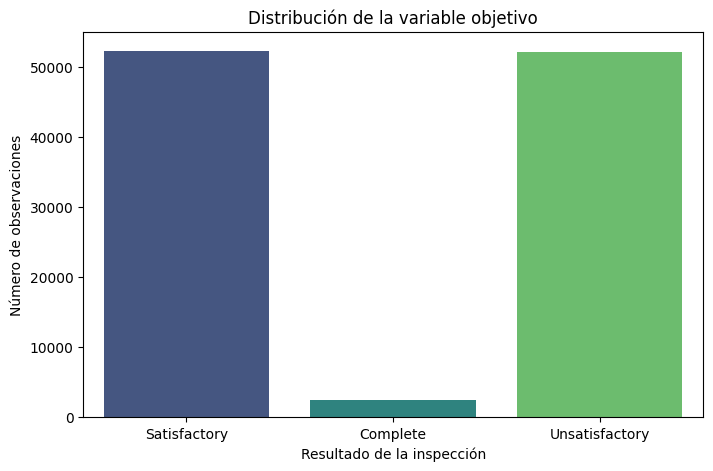

In [ ]:
import seaborn as sns
plt.figure(figsize=(8,5))

sns.countplot(
    data=raw_original,
    x="Inspection Result",
    palette="viridis"
)

plt.title("Distribución de la variable objetivo")
plt.xlabel("Resultado de la inspección")
plt.ylabel("Número de observaciones")

plt.show()

Aunque aparentemente parecieran balanceadas, existen dos elementos que van a estar muy presentes en el análisis: 1) la existencia de 16 mil actas que documentan más de una infracción, lo que inclinará la balanza hacia los resultados satisfactorios y, la categoría "Complete" cuyo objeto a priori no debe ser depurado en el marco del objetivo propuesto.

In [ ]:
numericas=raw_original.select_dtypes(include=["int64","float64"]).columns
categoricas=raw_original.select_dtypes(include=["object"]).columns

print(f"Número de variables numéricas: {len(numericas)}")

print(f"Número de variables categóricas: {len(categoricas)}")

Número de variables numéricas: 3
Número de variables categóricas: 17


In [ ]:
print("Variables numéricas")

display(pd.DataFrame(numericas,columns=["Variable"]))

print("\n")

print("Variables categóricas")

display(pd.DataFrame(categoricas,columns=["Variable"]))

Variables numéricas


,Variable
0,Inspection Score
1,Risk Category
2,Violation Points




Variables categóricas


,Variable
0,Name
1,Program Identifier
2,Inspection Date
3,Classification
4,Address
5,City
6,Zip Code
7,Inspection Type
8,Inspection Result
9,Inspection Closed Business


In [ ]:
# descripción de las variables

raw_original[numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
Inspection Score,106995.0,15.573999,21.398284,-1.0,0.0,8.0,23.0,167.0
Risk Category,106369.0,2.771165,0.563647,1.0,3.0,3.0,3.0,3.0
Violation Points,106995.0,4.614739,5.737085,0.0,0.0,5.0,5.0,25.0


In [ ]:
raw_original[categoricas].describe().T

,count,unique,top,freq
Name,106995,9846,LEVY RESTAURANTS @ LUMEN FIELD,723
Program Identifier,19519,2390,LUNCHROOM,1087
Inspection Date,106995,1666,06/10/2026,221
Classification,106995,15,General Food Services,83214
Address,106994,9484,800 OCCIDENTAL AVE S,829
City,106987,111,SEATTLE,37451
Zip Code,106994,131,98101,4210
Inspection Type,106995,3,Routine Inspection/Field Review,102360
Inspection Result,106995,3,Satisfactory,52363
Inspection Closed Business,106995,2,No,106820


In [ ]:
# y la cardinalidad

valores_unicos = pd.DataFrame({
    "Variable": raw_original.columns,
    "Valores únicos": raw_original.nunique().values
})

valores_unicos.sort_values(
    by="Valores únicos",
    ascending=False
)

,Variable,Valores únicos
19,Inspection_Serial_Num,72070
18,Business_ID,12299
0,Name,9846
4,Address,9484
17,Parcel Number,7255
1,Program Identifier,2390
2,Inspection Date,1666
6,Zip Code,131
8,Inspection Score,127
5,City,111


In [ ]:
# y buscamos posibles valores constantes y casi para eventualmente descartarlos
# las casi constantes no lo son, sino que describen tipologías y el resultado de la inspección, de modo que no se eliminan

constantes = []

for col in raw_original.columns:

    if raw_original[col].nunique()==1:

        constantes.append(col)

print(constantes)

casi_constantes=[]

for col in raw_original.columns:

    frecuencia=raw_original[col].value_counts(normalize=True).iloc[0]

    if frecuencia>0.90:

        casi_constantes.append(col)

print(casi_constantes)

[]
['Inspection Type', 'Inspection Closed Business']


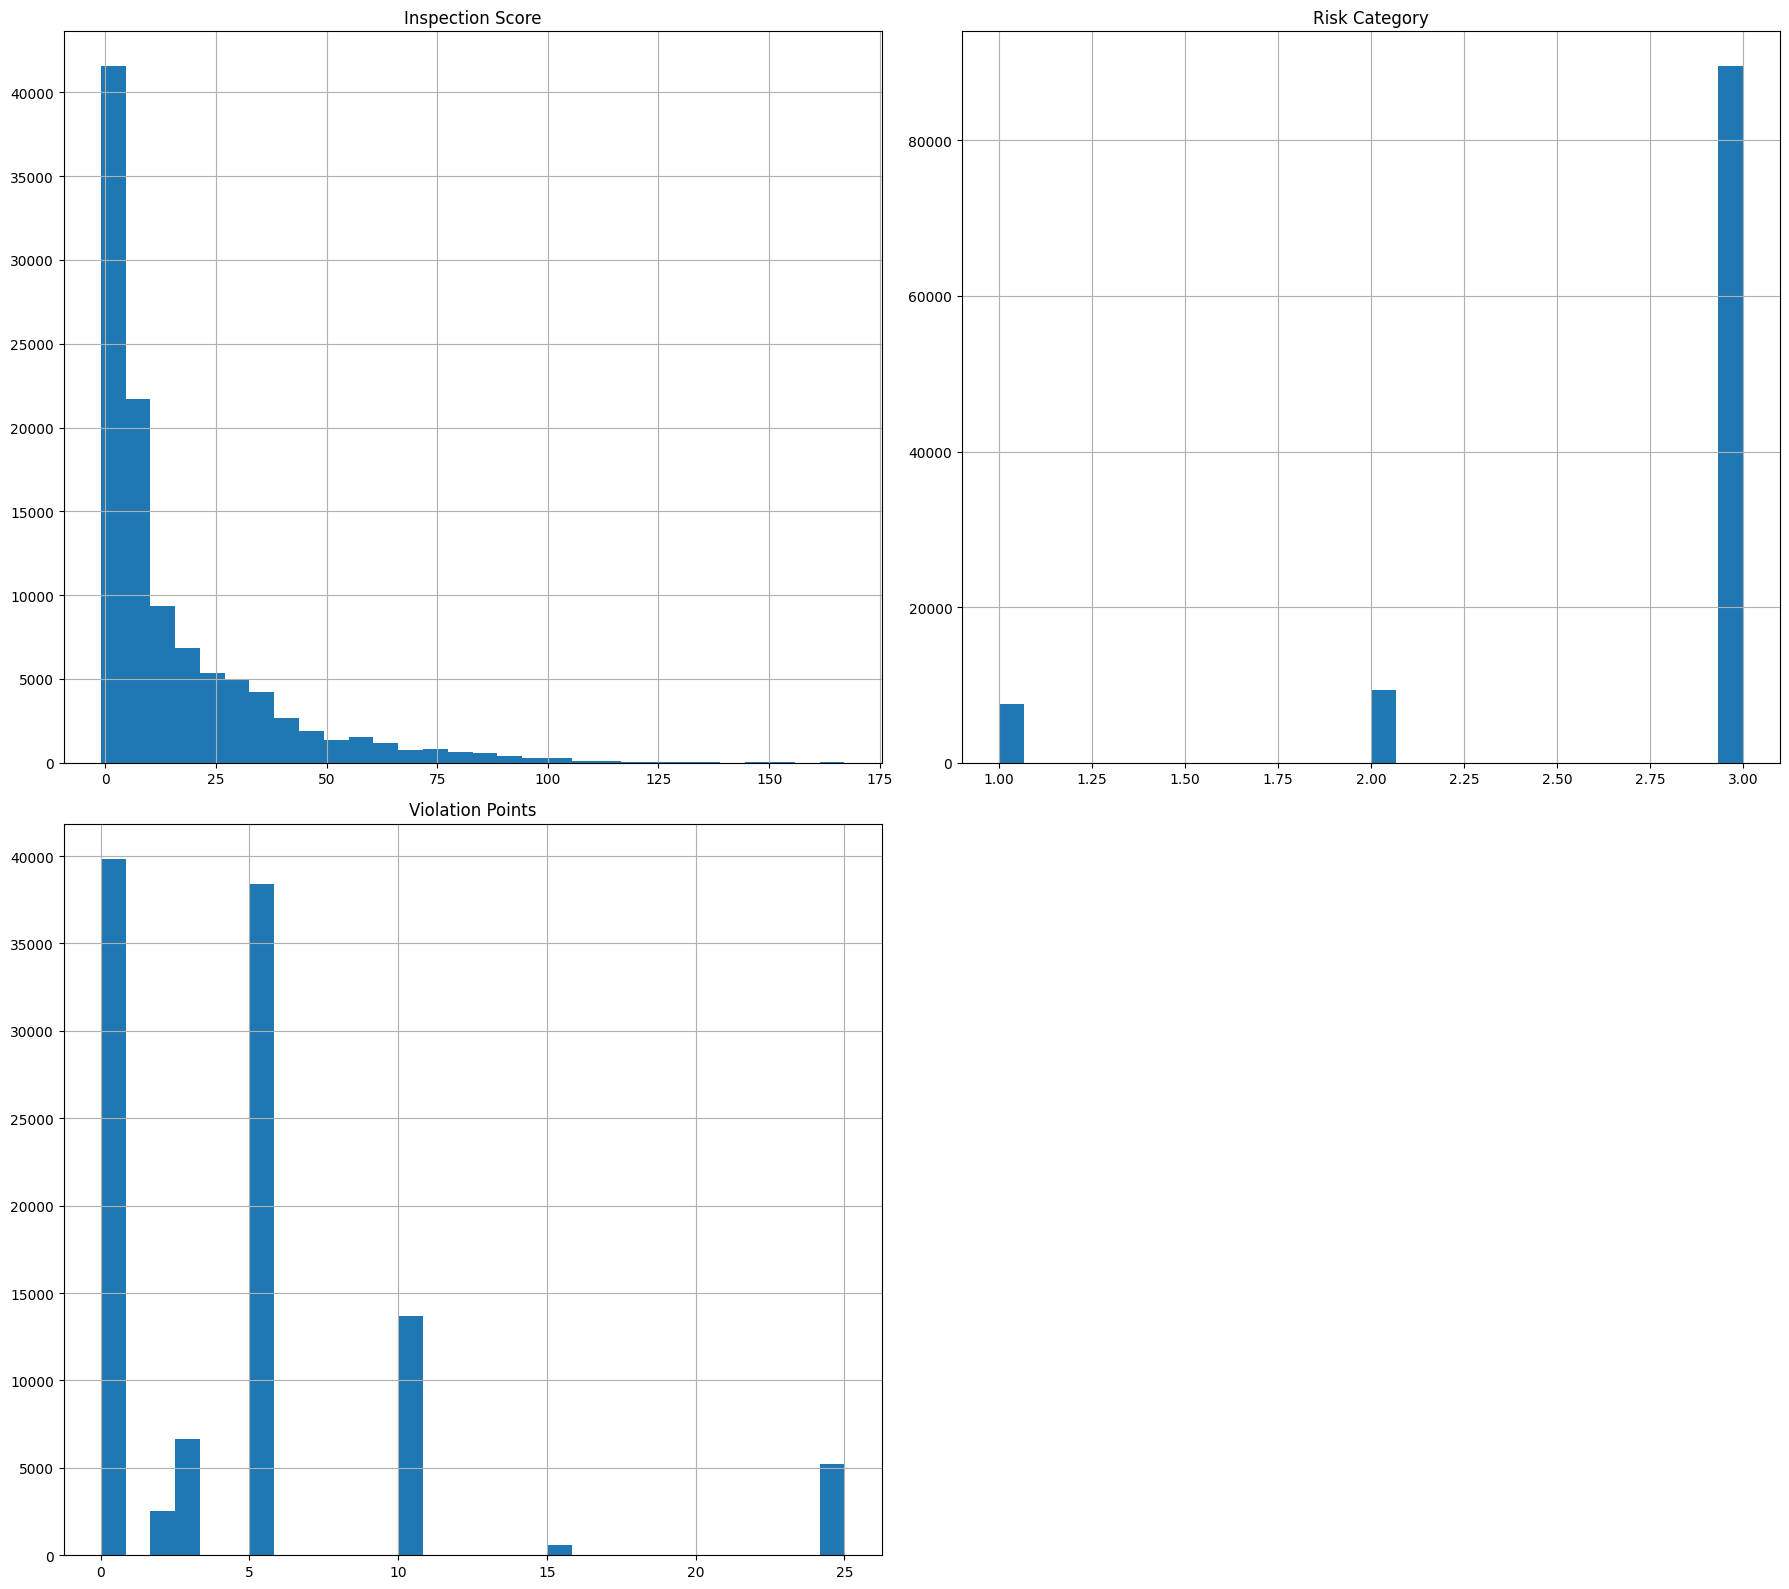

In [ ]:
# visualizamos esta información

numericas = raw_original.select_dtypes(include=["int64","float64"]).columns

raw_original[numericas].hist(
    figsize=(18,16),
    bins=30
)

plt.tight_layout()

plt.show()

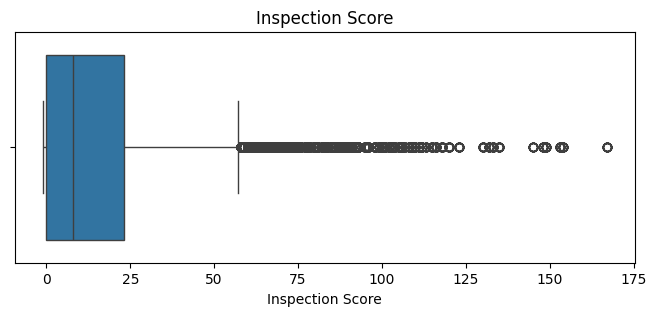

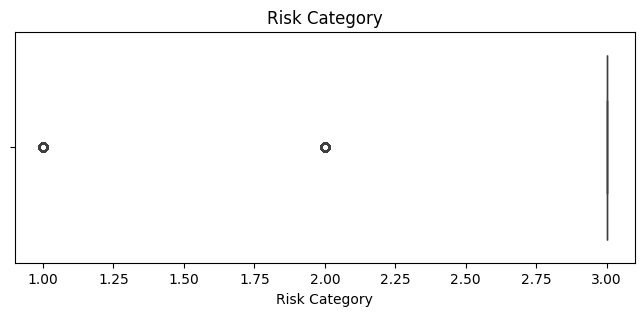

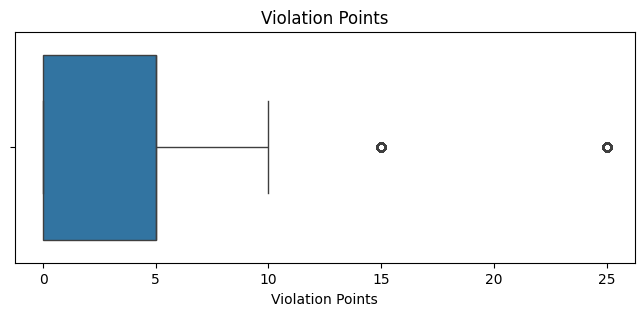

In [ ]:
for columna in numericas:

    plt.figure(figsize=(8,3))

    sns.boxplot(
        x=raw_original[columna]
    )

    plt.title(columna)

    plt.show()

Con esta representación podemos adelantar que junto con establecimientos, los menos, que concntran gran número de infracciones, y que podrían llegar a ser objeto de un tratamiento separado, el grueso del trabajo de los inspectores se centrará en dedicar sus esfuerzos a un colectivo numeroso de establecimientos que concentran menor número de infracciones (5), pero que cuantitativamente agrupan valores altos.

También analizamos la posible correlación entre las variables numéricas.

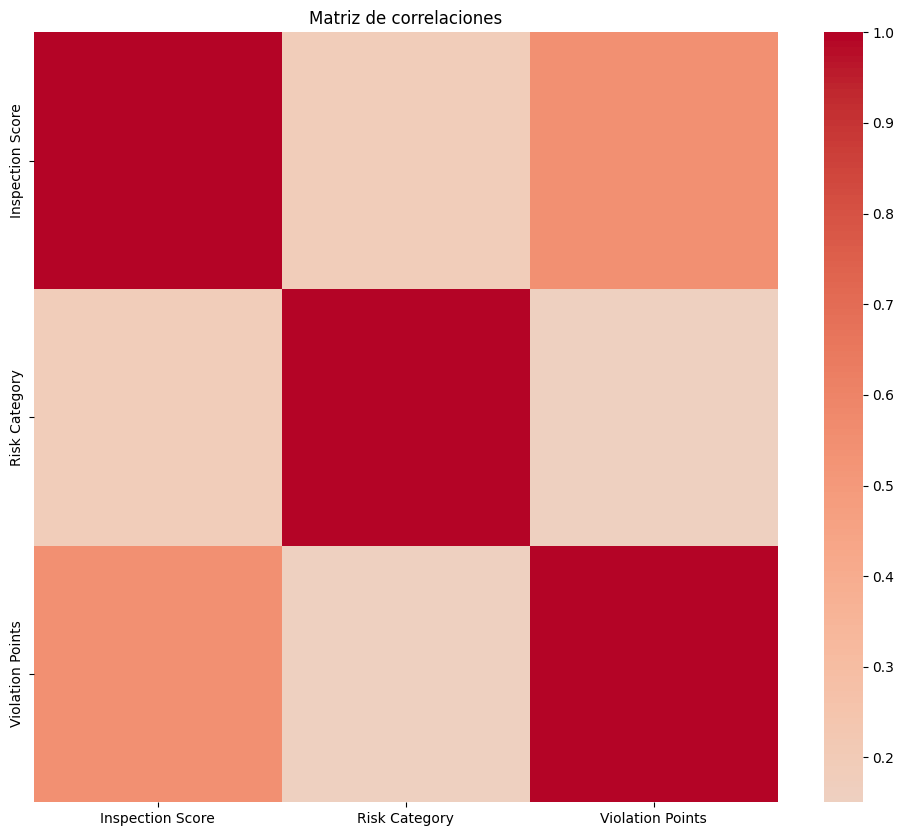

In [ ]:
corr = raw_original[numericas].corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlaciones")

plt.show()

In [ ]:
# pero descartamos la correlación

corr_matrix = raw_original[numericas].corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape),k=1).astype(bool)
)

correladas = []

for columna in upper.columns:

    if any(upper[columna]>0.90):

        correladas.append(columna)

print(correladas)

[]


Las variables categóricas, por su gran cardinalidad en este dataset, ofrecen innegables dificultades, especialmente porque nos enfrentamos al reto de que la información permita bajar al detalle que permita disponer a los inspectores de criterios adaptados tanto a la localización como a la tipología de los establecimientos

In [ ]:
for columna in categoricas:

    print("="*60)
    print(columna)
    print("="*60)

    display(raw_original[columna].value_counts().head(10))

    print("\n")

Name


,count
Name,
LEVY RESTAURANTS @ LUMEN FIELD,723
T-MOBILE PARK,592
ARENA AT SEATTLE CENTER,436
SUBWAY,319
PCC COMMUNITY MARKETS,283
TACO TIME,259
PAGLIACCI PIZZA INC,185
WENDY'S,175
WHOLE FOODS MARKET,171




Program Identifier


,count
Program Identifier,
LUNCHROOM,1087
QFC - GROCERY,76
GROCERY,61
PCC COMMUNITY MARKETS - DELI,53
TAQUERIA EL HERRADERO LLC (KC242)@2800 NE SUNSET,48
SAFEWAY STORE #1508,44
UWAJIMAYA - DELI,43
FOU LEE MARKET & DELI,42
DELI,41




Inspection Date


...

,count
Parcel Number,
7666204876.0,829
7666206483,600
2823049016.0,500
1985200003.0,442
9202470010.0,293
2725059039.0,282
323049164.0,241
2625059123.0,238
1544100040.0,233




Business_ID


,count
Business_ID,
PFE-PR-3128874,115
PFE-PR-3127355,105
PFE-PR-3137682,100
PFE-PR-3144069,99
PFE-PR-3127686,79
PFE-PR-3143924,71
PFE-PR-3139404,71
PFE-PR-3143306,65
PFE-PR-3129029,65




Inspection_Serial_Num


,count
Inspection_Serial_Num,
PFE-DAGM7JOI4,19
PFE-DAPA0QENU,19
PFE-DAXK1YYUE,18
PFE-DAS3YBJ3Z,16
PFE-DAIIVHGVL,16
PFE-RT-0459028-2025,16
PFE-DAN2BM0IB,16
PFE-DAVRBVMYG,16
PFE-DAMT3C0KE,16


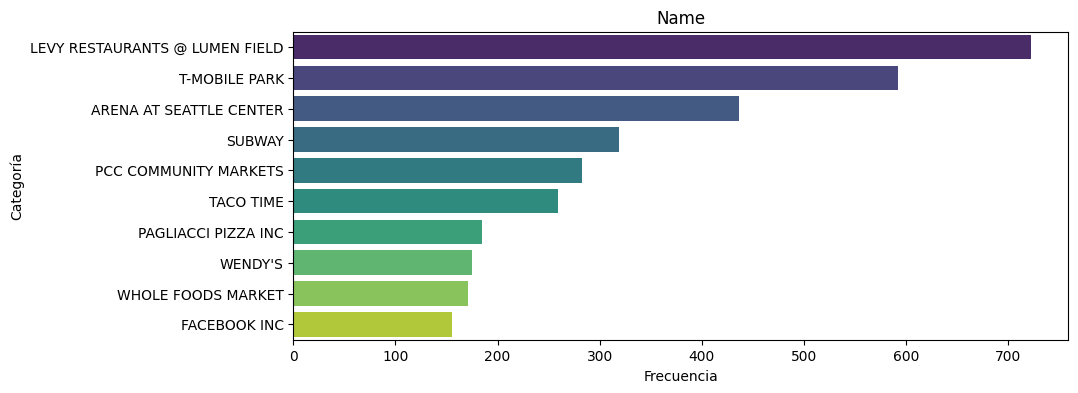

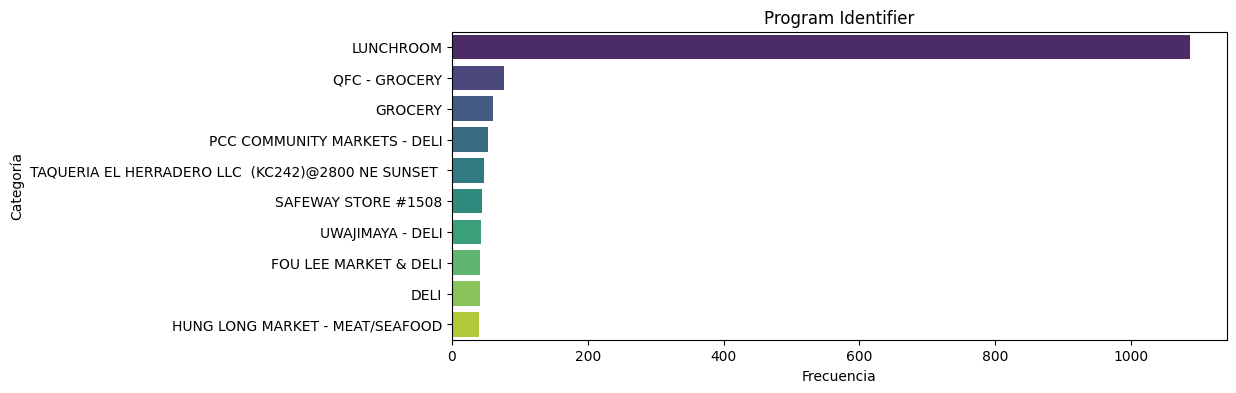

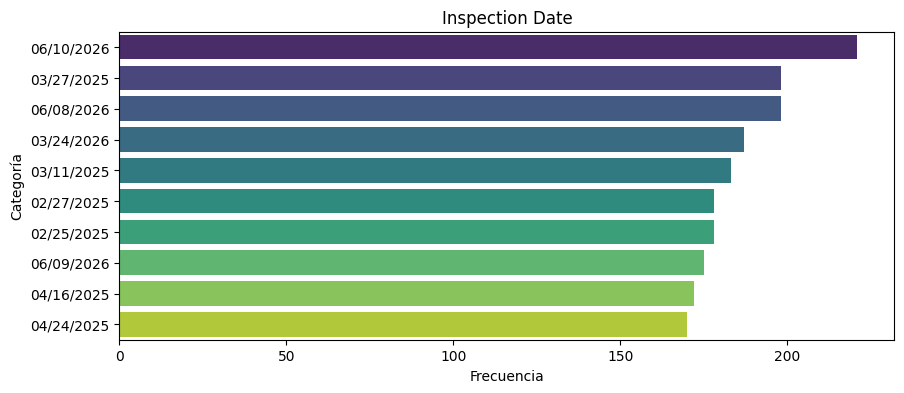

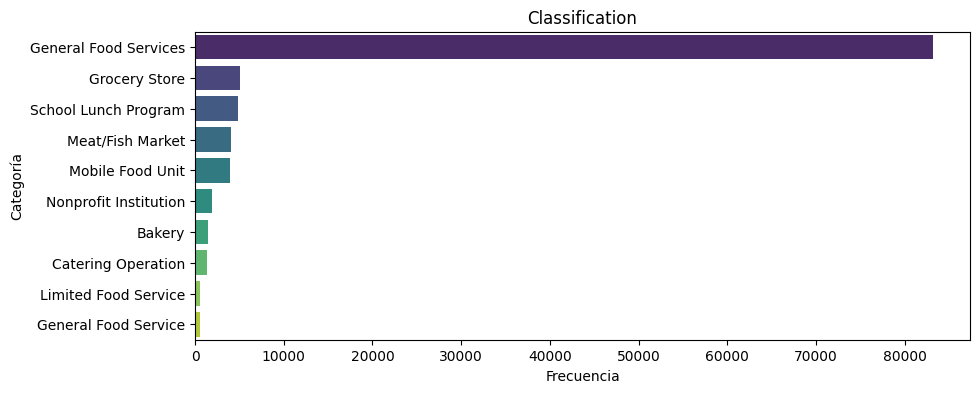

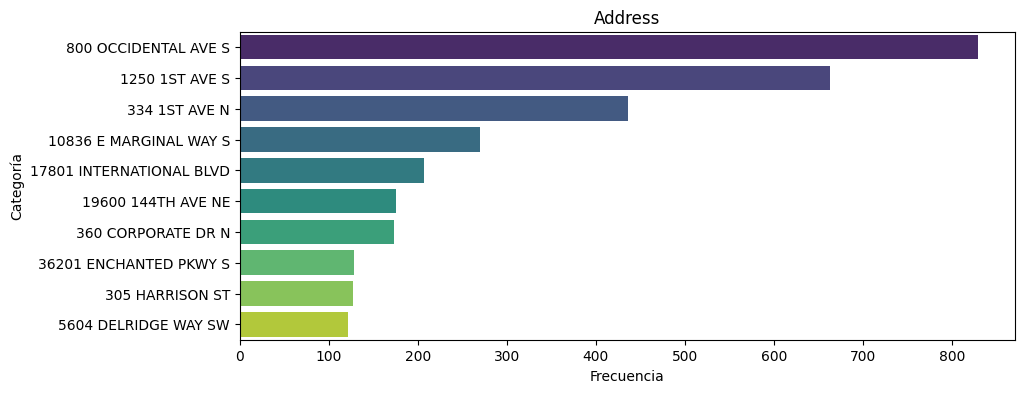

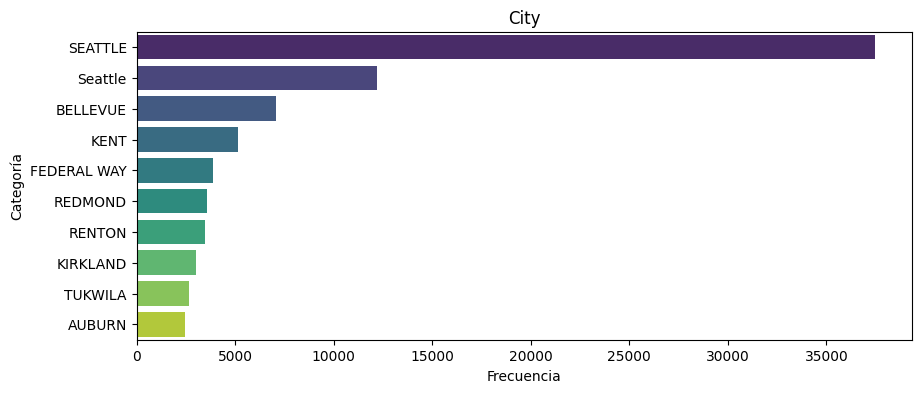

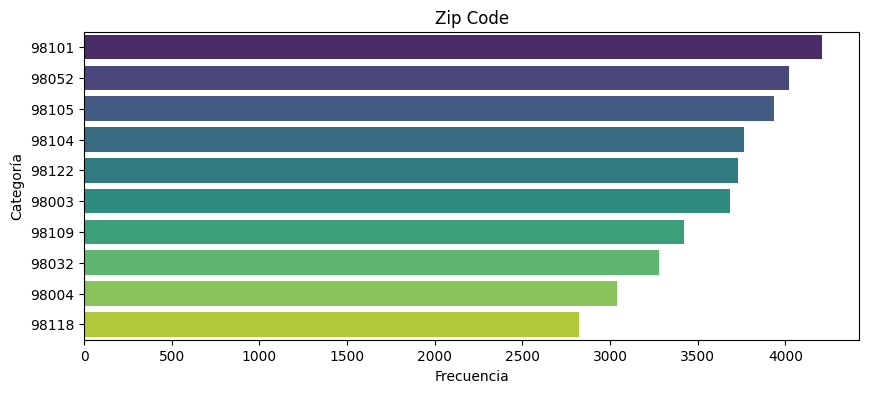

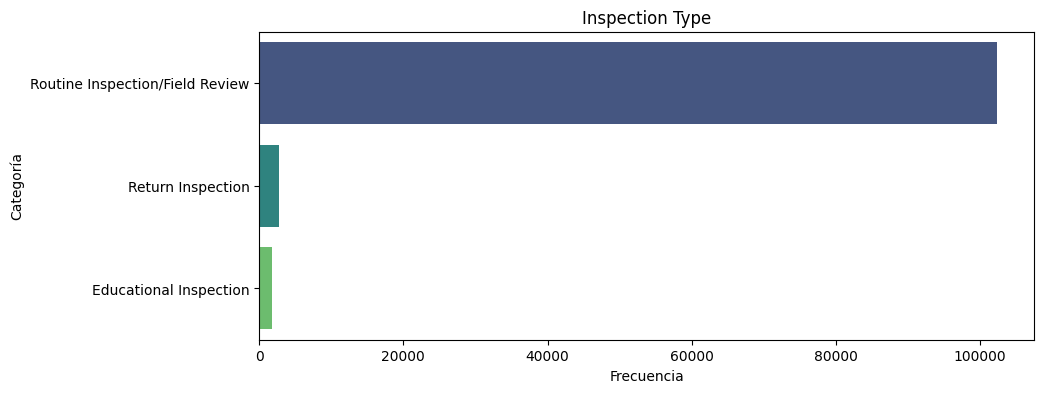

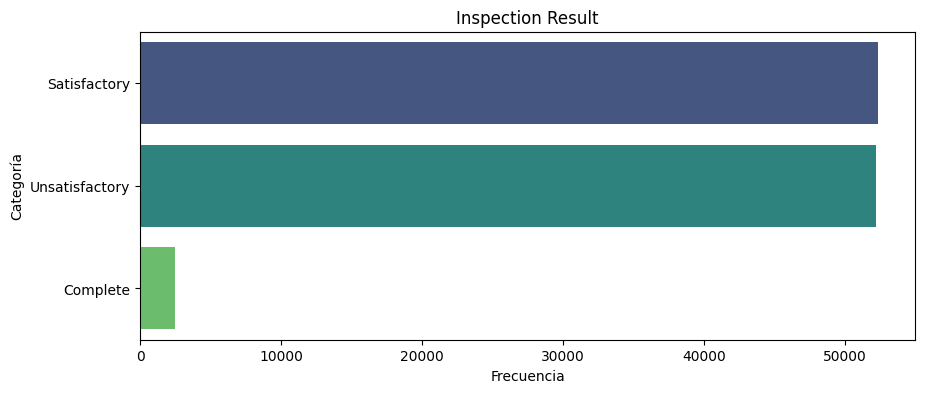

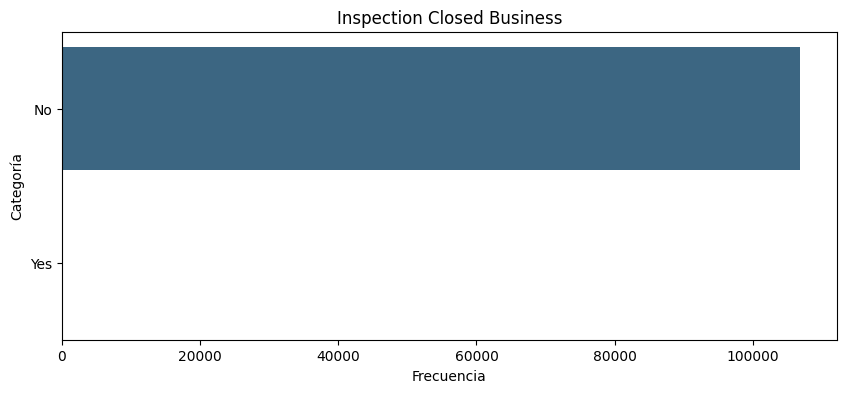

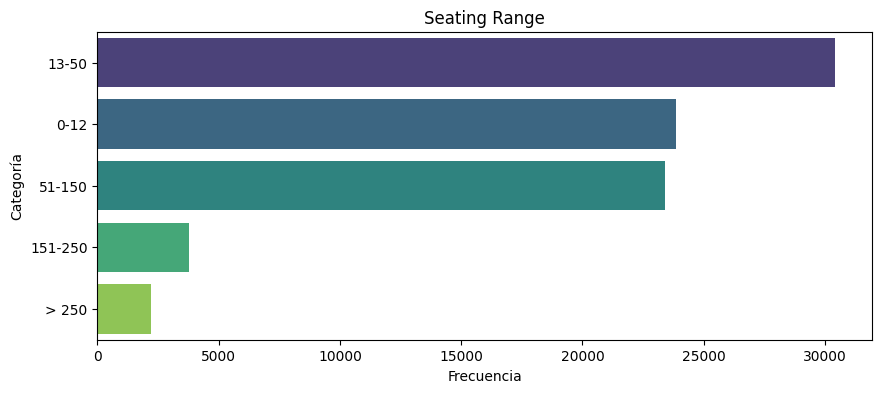

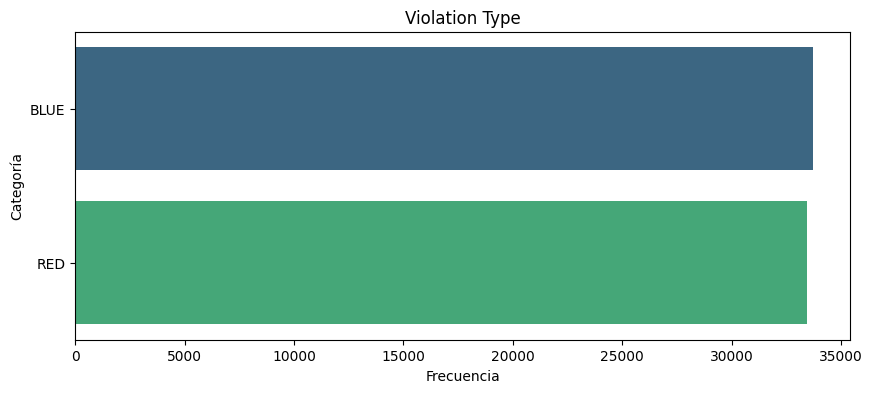

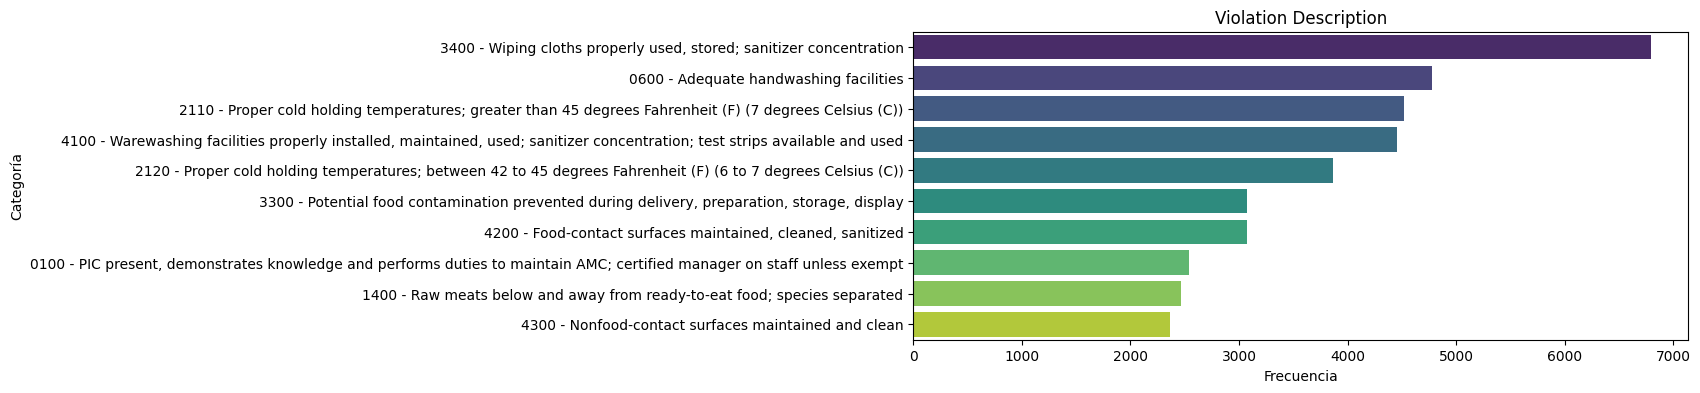

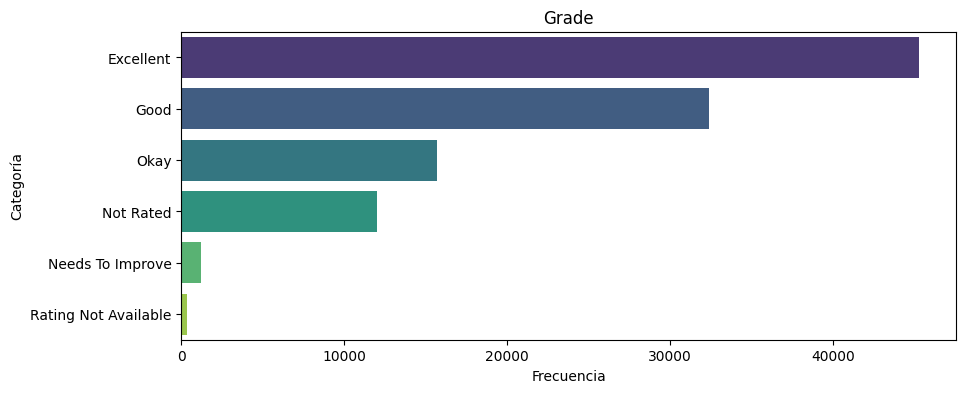

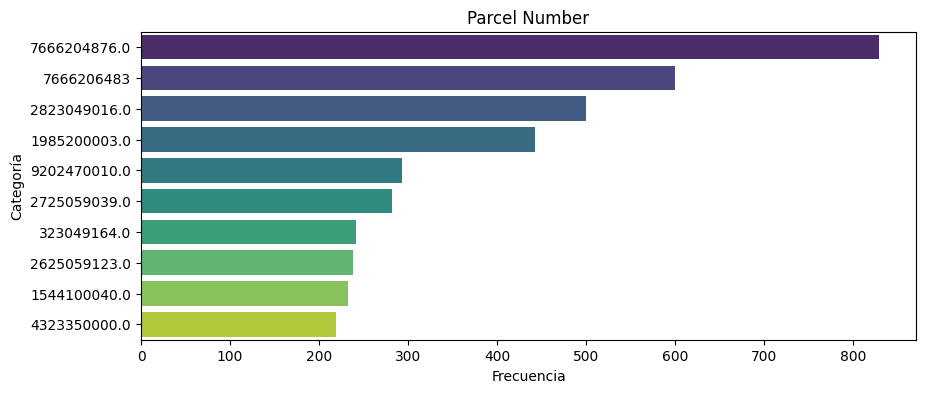

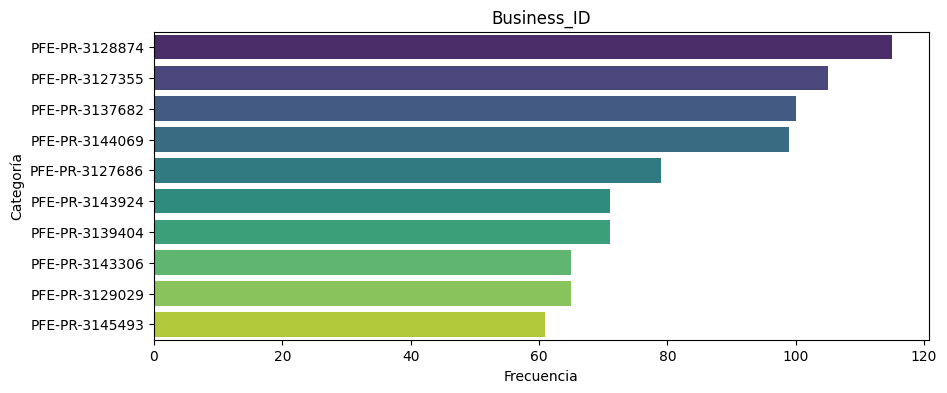

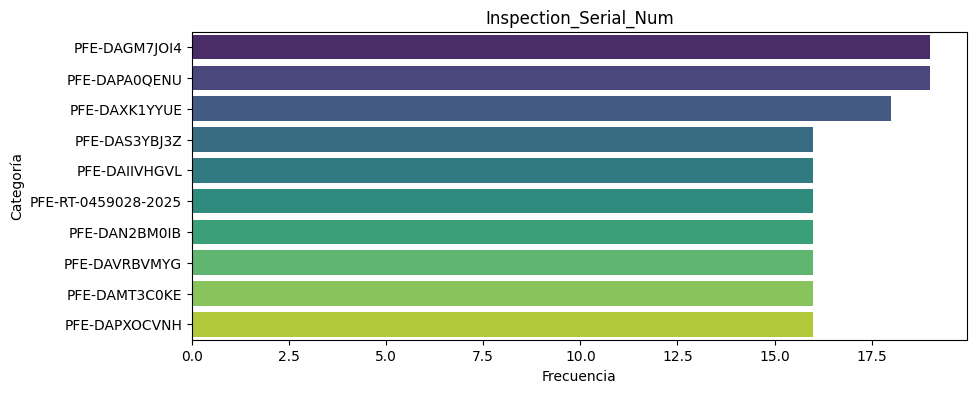

In [ ]:
for columna in categoricas:

    plt.figure(figsize=(10,4))

    top = raw_original[columna].value_counts().head(10)

    sns.barplot(

        x=top.values,

        y=top.index,

        palette="viridis"

    )

    plt.title(columna)

    plt.xlabel("Frecuencia")

    plt.ylabel("Categoría")

    plt.show()

Ahora, y siempre antes de depurar los errores que los propios gráficos nos devuelven y de los que nos ocuparemos en el bloque siguiente, hacemos una aproximación a la relación entre las variables categóricas y las variable objetivo.

<Figure size 1000x500 with 0 Axes>

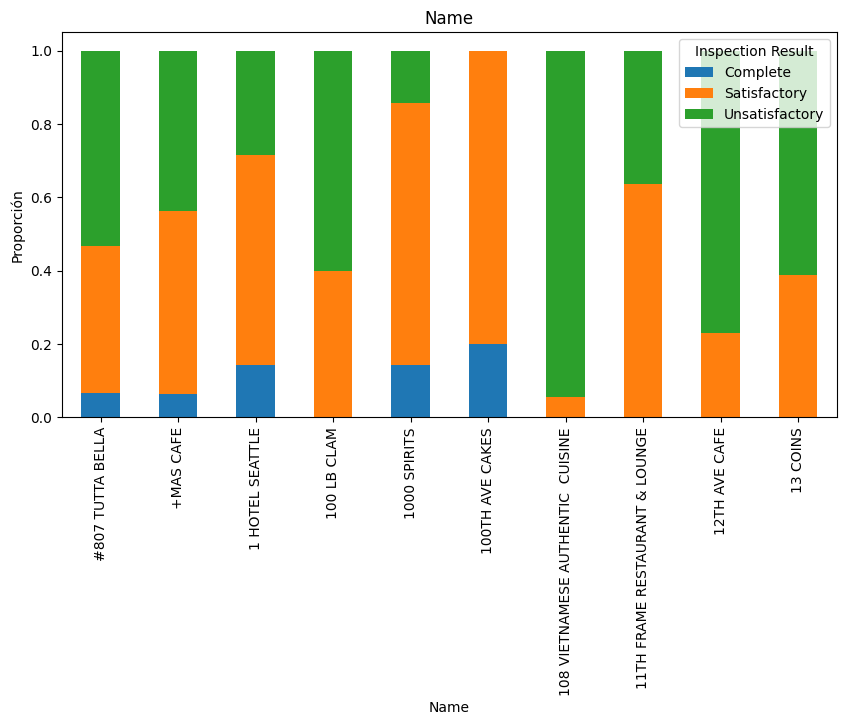

<Figure size 1000x500 with 0 Axes>

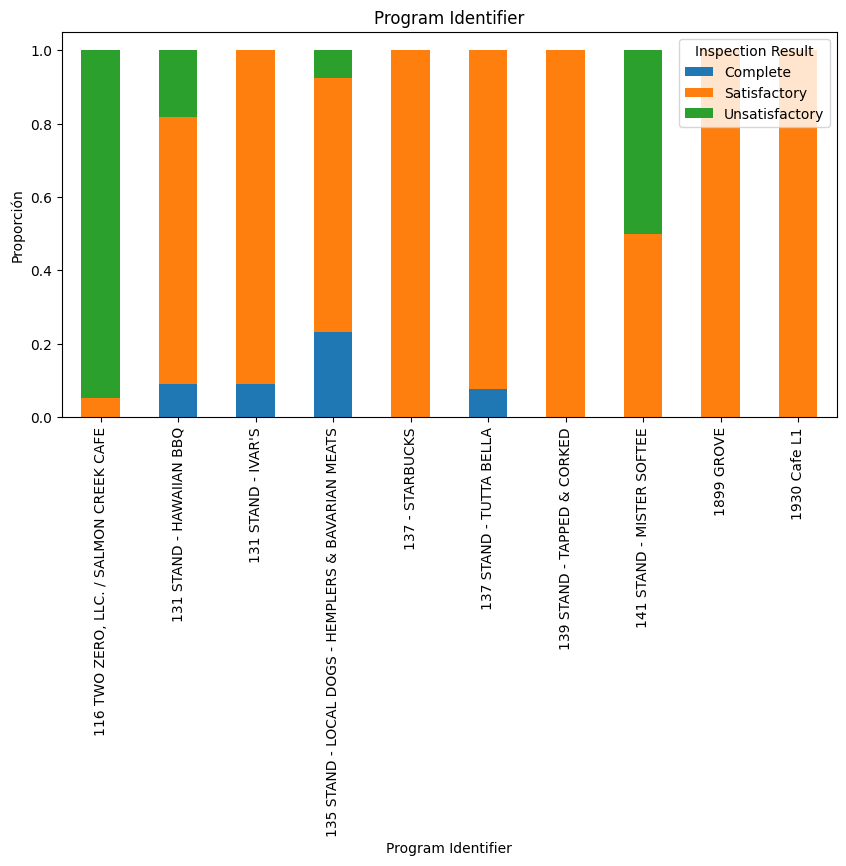

<Figure size 1000x500 with 0 Axes>

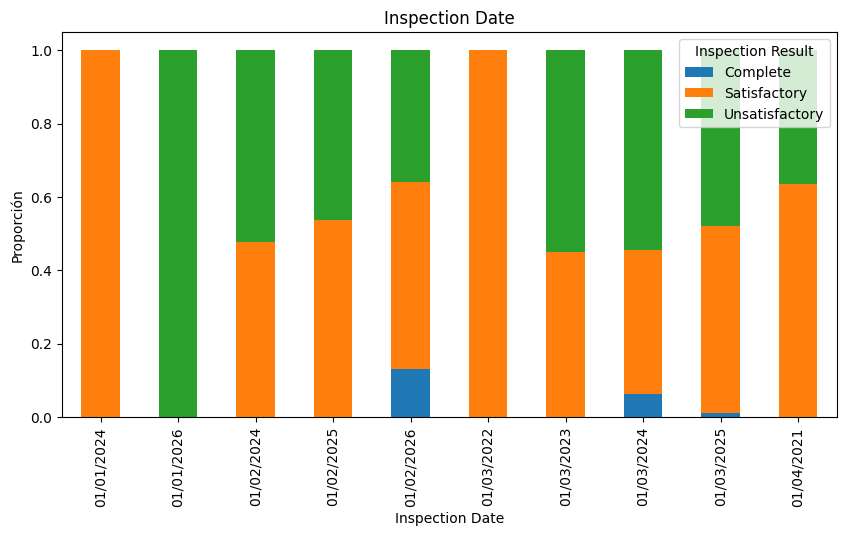

<Figure size 1000x500 with 0 Axes>

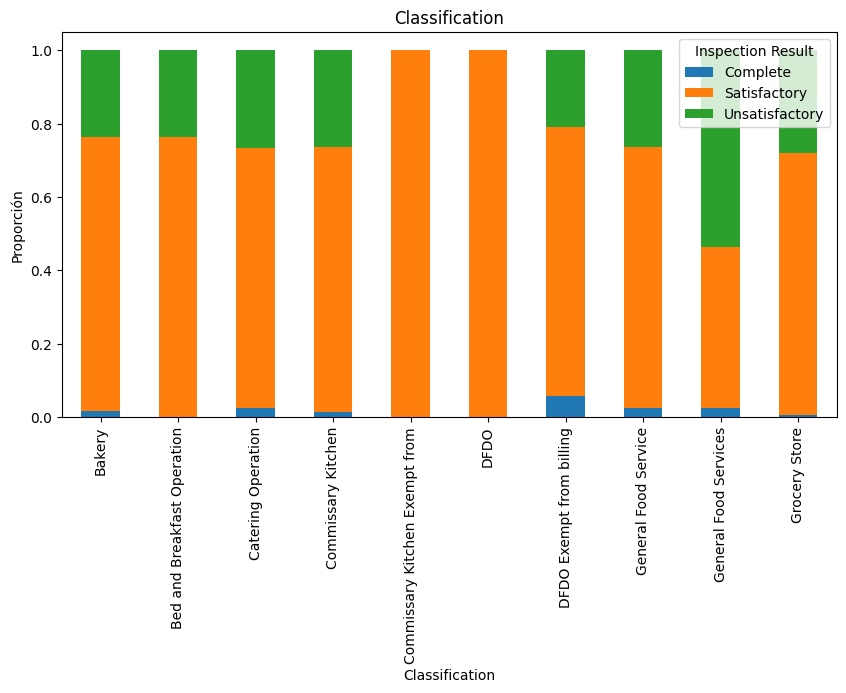

<Figure size 1000x500 with 0 Axes>

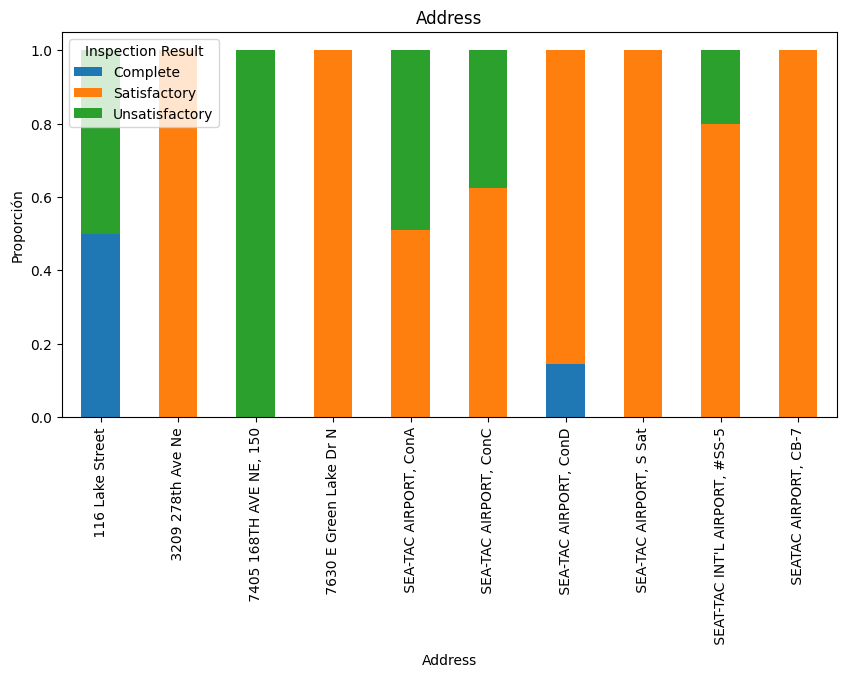

<Figure size 1000x500 with 0 Axes>

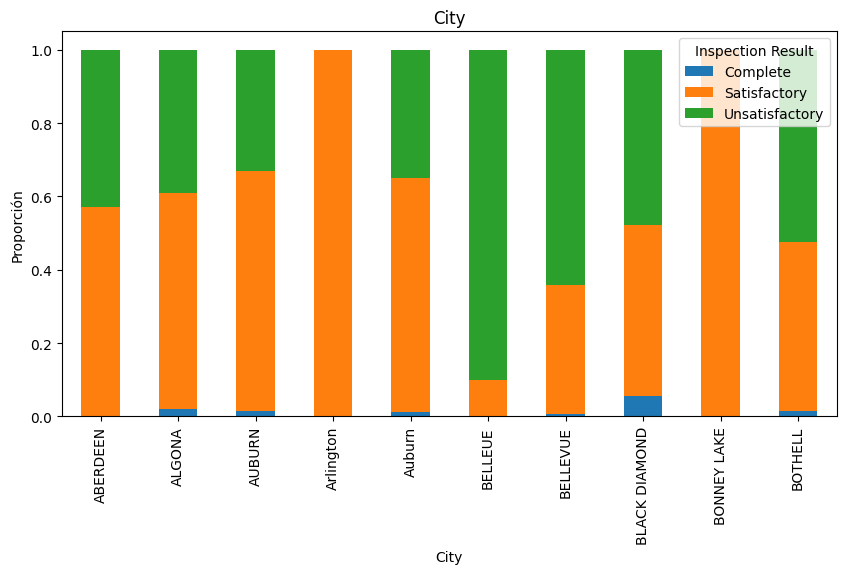

<Figure size 1000x500 with 0 Axes>

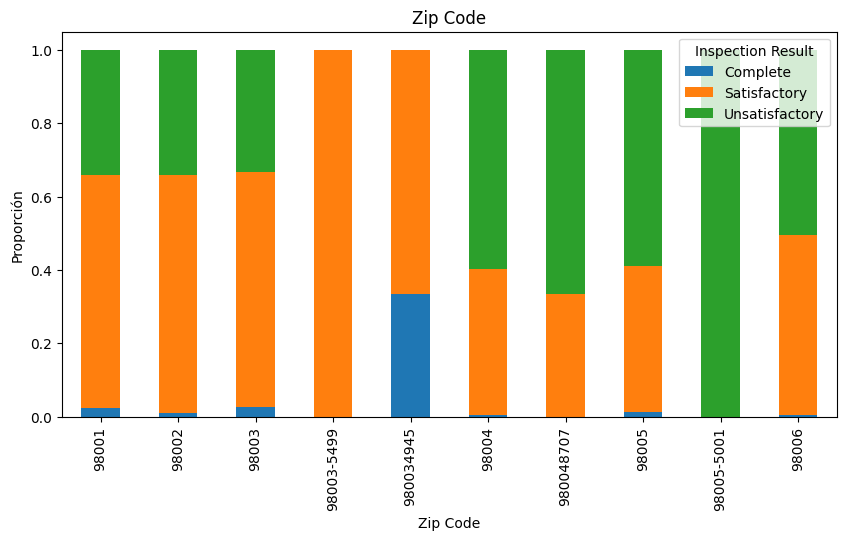

<Figure size 1000x500 with 0 Axes>

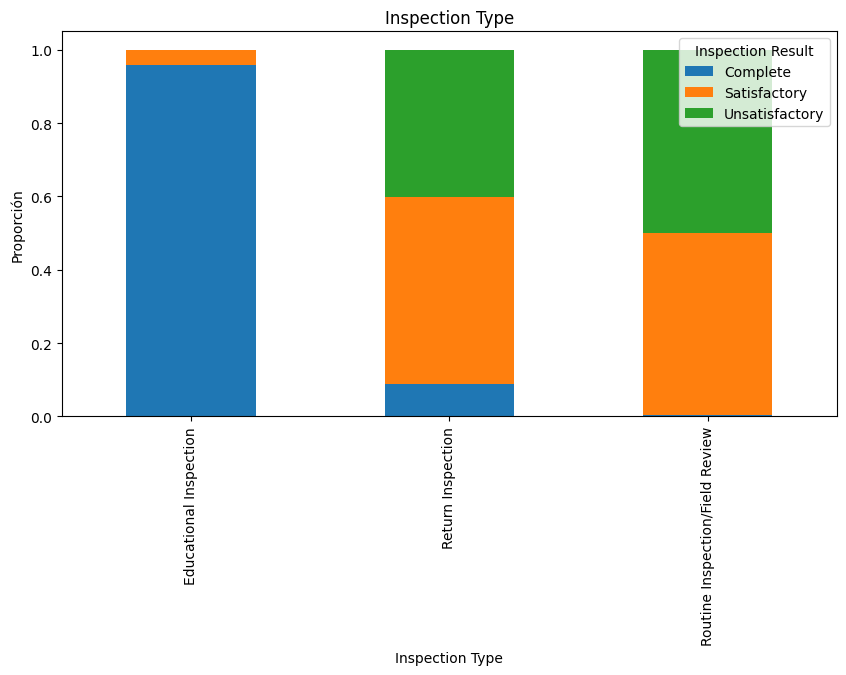

<Figure size 1000x500 with 0 Axes>

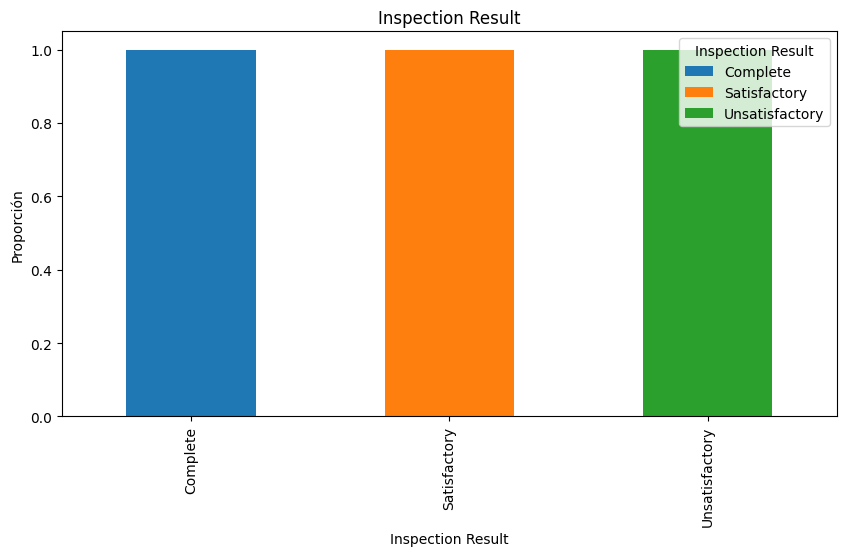

<Figure size 1000x500 with 0 Axes>

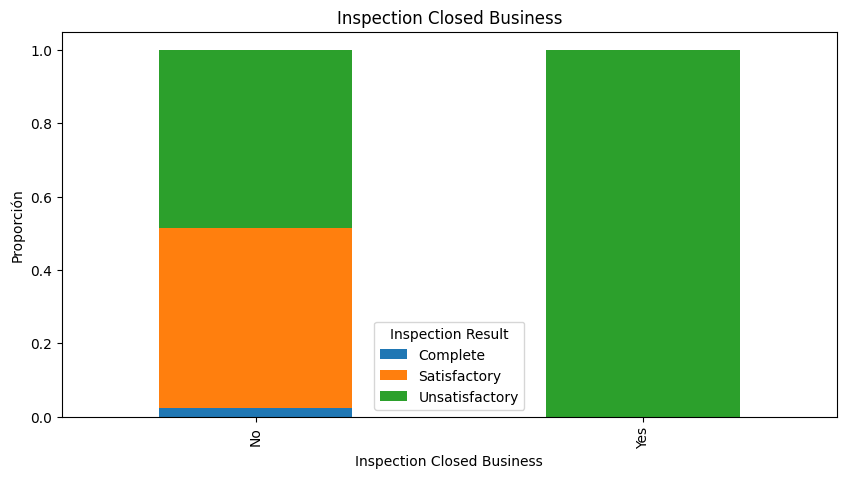

<Figure size 1000x500 with 0 Axes>

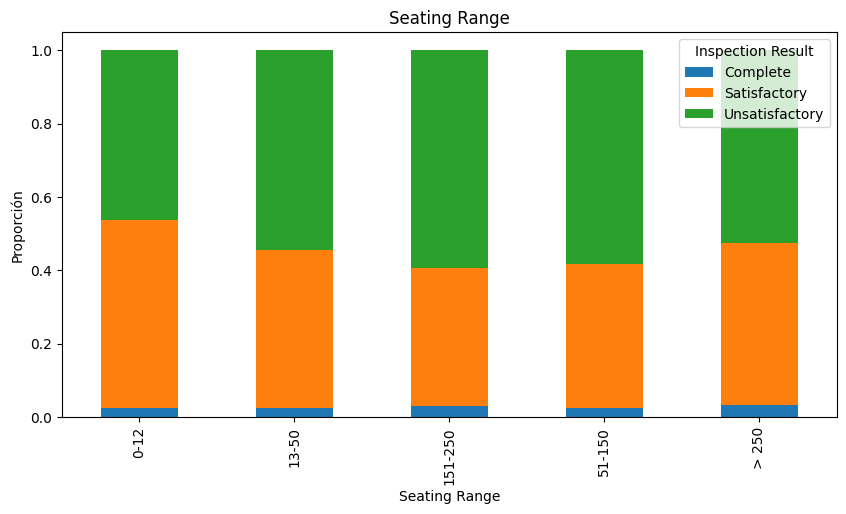

<Figure size 1000x500 with 0 Axes>

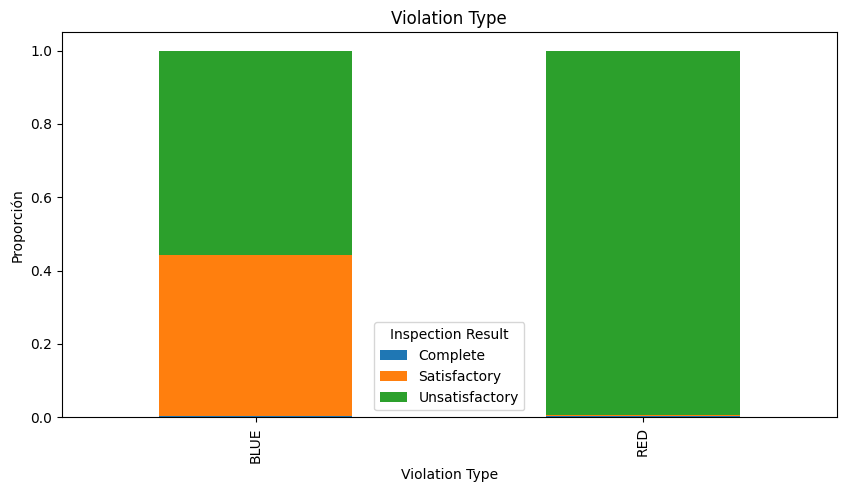

<Figure size 1000x500 with 0 Axes>

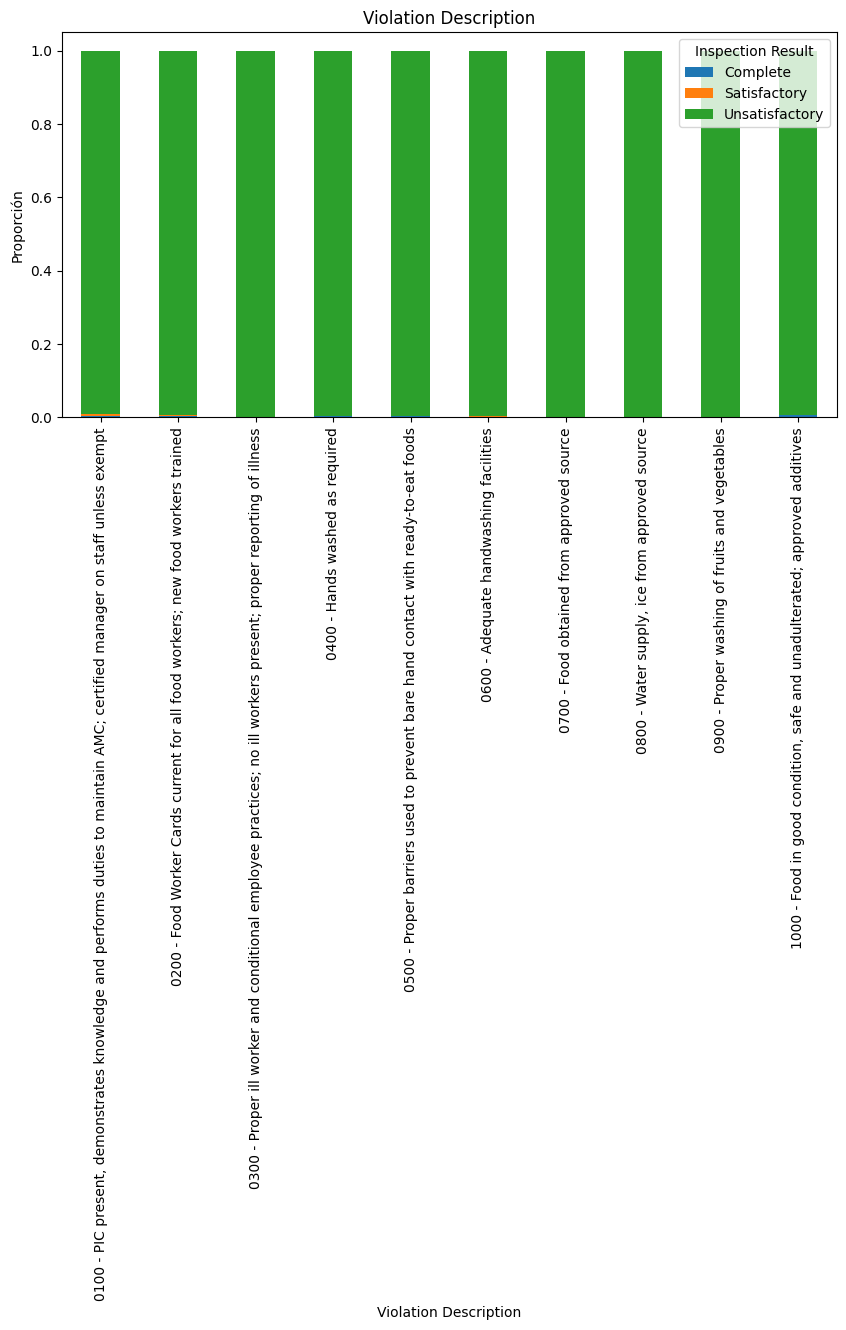

<Figure size 1000x500 with 0 Axes>

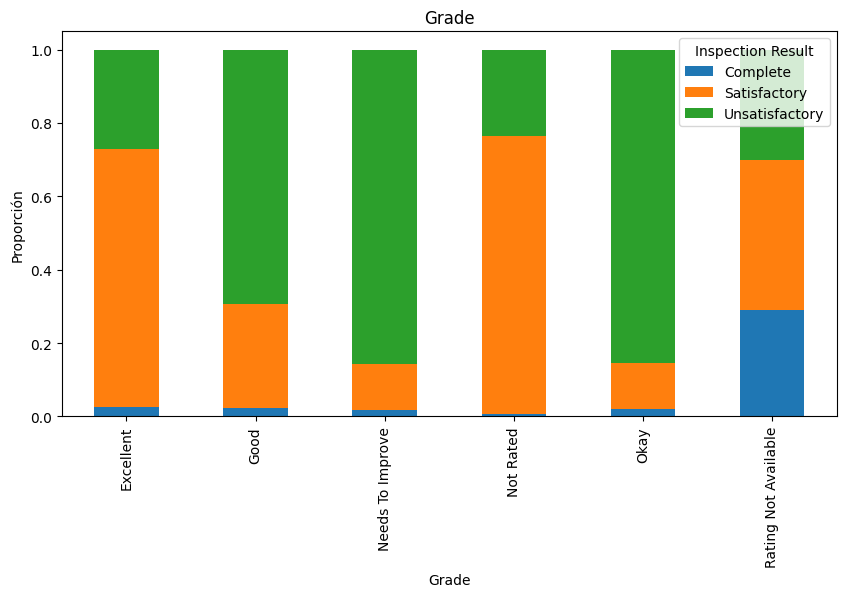

<Figure size 1000x500 with 0 Axes>

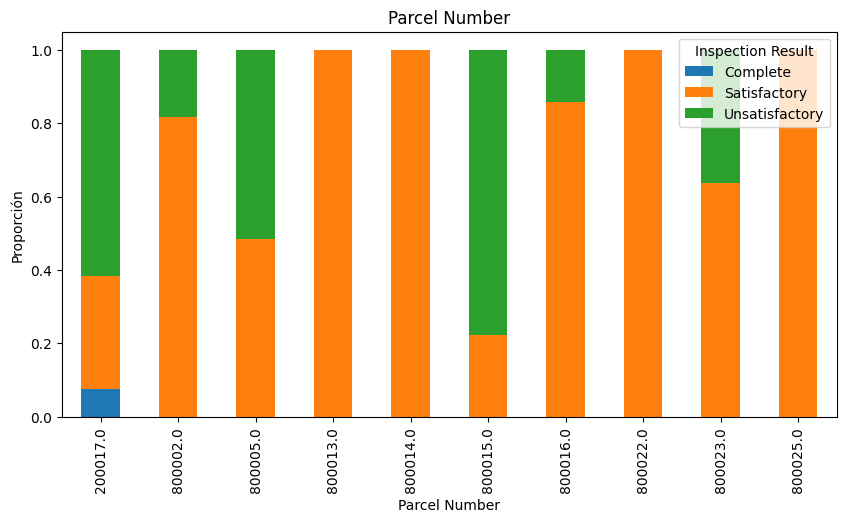

<Figure size 1000x500 with 0 Axes>

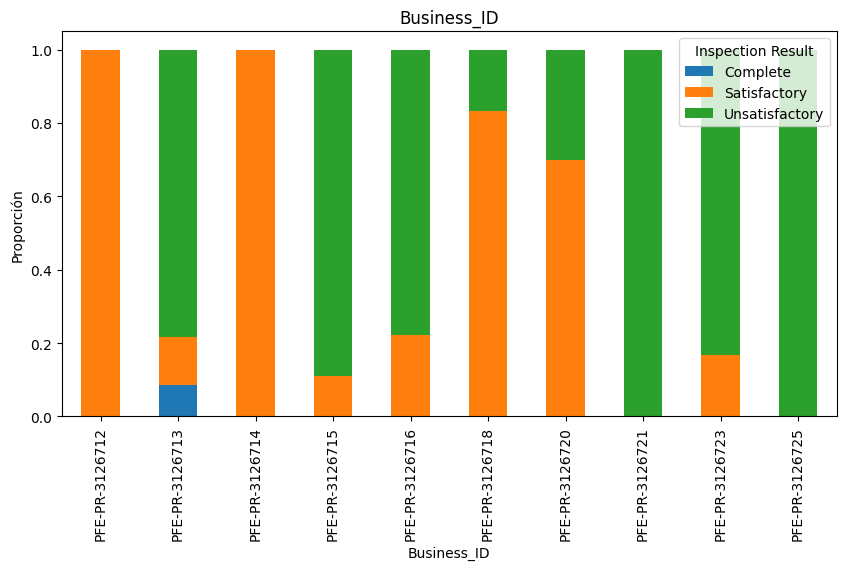

<Figure size 1000x500 with 0 Axes>

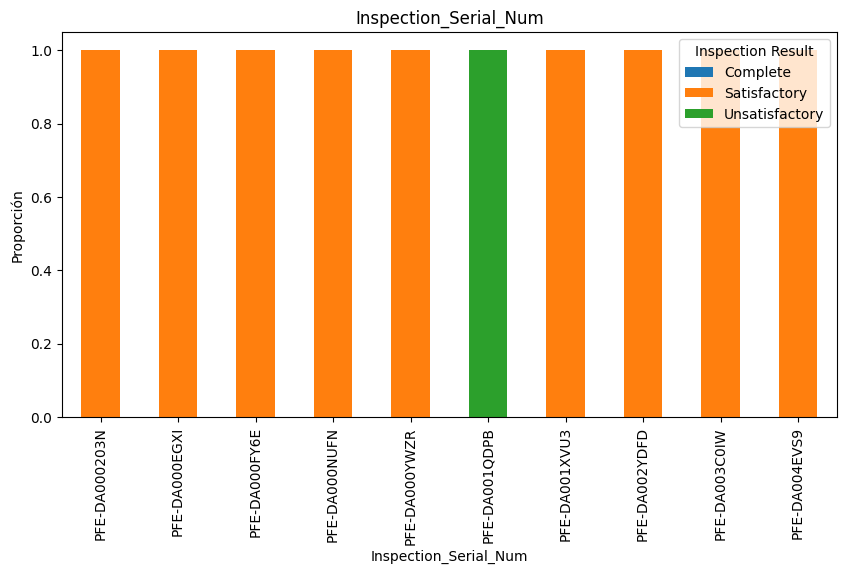

In [ ]:
for columna in categoricas:

    plt.figure(figsize=(10,5))

    tabla = pd.crosstab(

        raw_original[columna],

        raw_original["Inspection Result"],

        normalize="index"

    )

    tabla.head(10).plot(

        kind="bar",

        stacked=True,

        figsize=(10,5)

    )

    plt.title(columna)

    plt.ylabel("Proporción")

    plt.show()

Y hacemos lo mismo con las numéricas

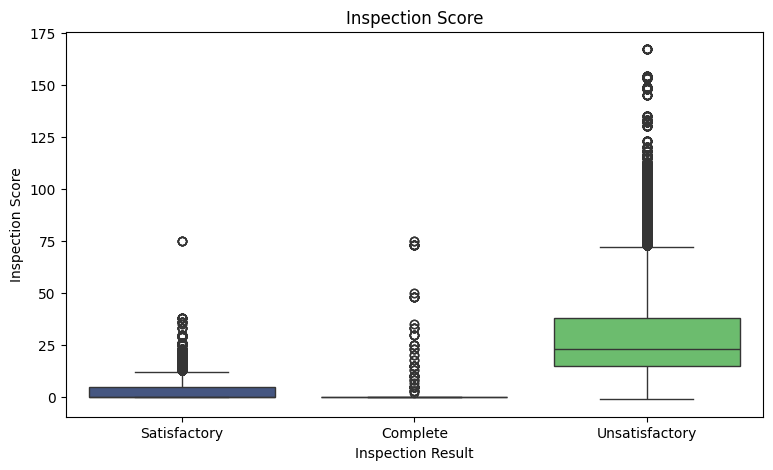

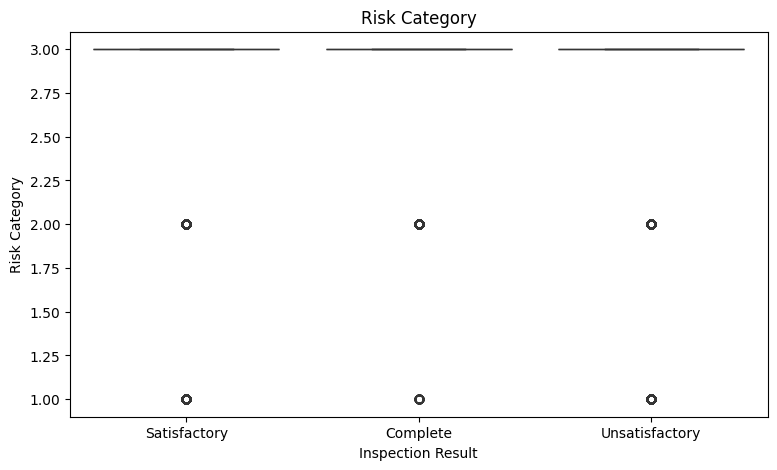

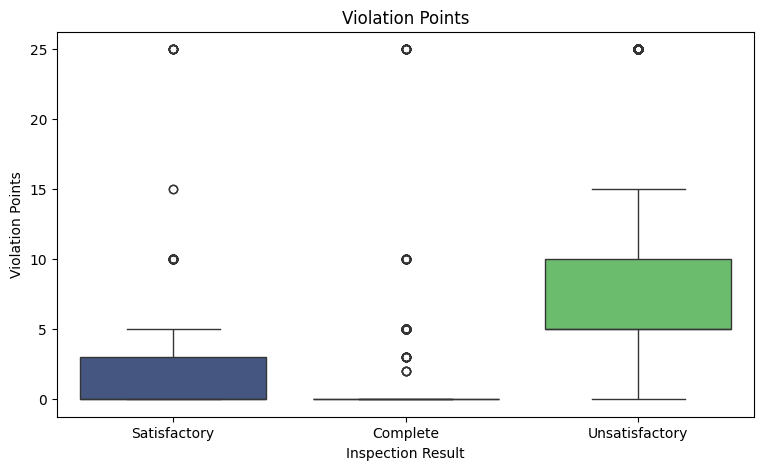

In [ ]:
# el resultado, como no podía ser de otra manera, muestra la relación de la puntuación de la inspección con las inspecciones con resultado insatisfactorio
for columna in numericas:

    plt.figure(figsize=(9,5))

    sns.boxplot(

        data=raw_original,

        x="Inspection Result",

        y=columna,

        palette="viridis"

    )

    plt.title(columna)

    plt.show()

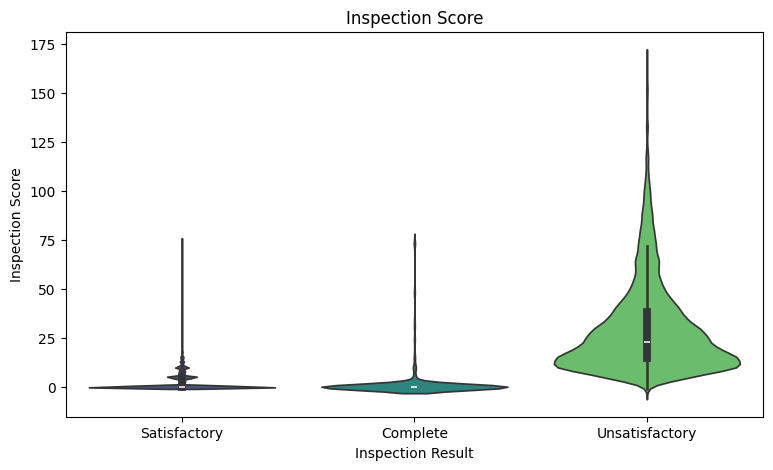

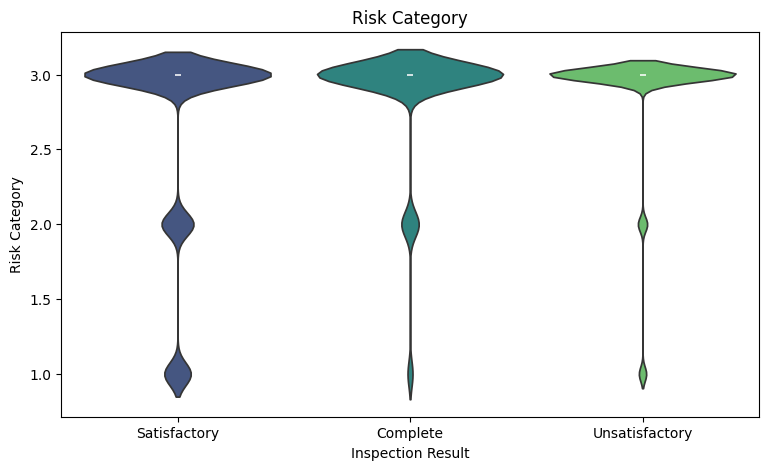

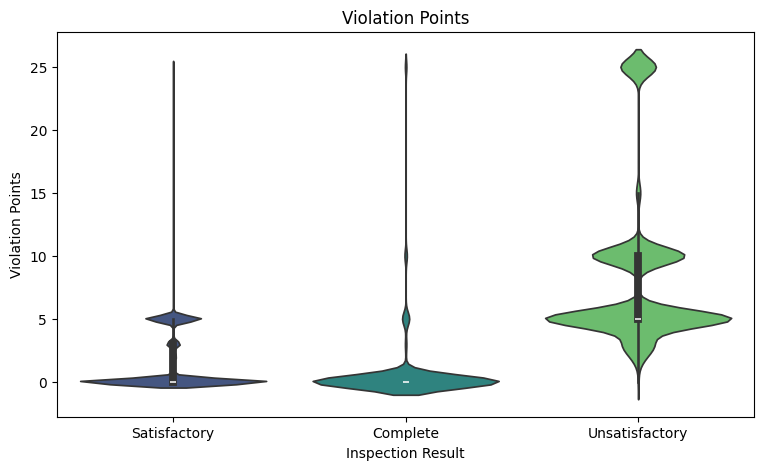

In [ ]:
for columna in numericas:

    plt.figure(figsize=(9,5))

    sns.violinplot(

        data=raw_original,

        x="Inspection Result",

        y=columna,

        palette="viridis"

    )

    plt.title(columna)

    plt.show()

Por último, y por si más adelante, una vez hecha la limpieza, se pudieran agrupar, estudiamos qué variables categóricas tienen poca frecuencia

In [ ]:
for columna in categoricas:

    frecuencia = raw_original[columna].value_counts()

    raras = (frecuencia < 10).sum()

    print(f"{columna:25} -> {raras} categorías aparecen menos de 10 veces")

Name                      -> 5882 categorías aparecen menos de 10 veces
Program Identifier        -> 1764 categorías aparecen menos de 10 veces
Inspection Date           -> 224 categorías aparecen menos de 10 veces
Classification            -> 2 categorías aparecen menos de 10 veces
Address                   -> 5417 categorías aparecen menos de 10 veces
City                      -> 33 categorías aparecen menos de 10 veces
Zip Code                  -> 42 categorías aparecen menos de 10 veces
Inspection Type           -> 0 categorías aparecen menos de 10 veces
Inspection Result         -> 0 categorías aparecen menos de 10 veces
Inspection Closed Business -> 0 categorías aparecen menos de 10 veces
Seating Range             -> 0 categorías aparecen menos de 10 veces
Violation Type            -> 0 categorías aparecen menos de 10 veces
Violation Description     -> 1 categorías aparecen menos de 10 veces
Grade                     -> 0 categorías aparecen menos de 10 veces
Parcel Number       

### Funciones básicas y limpieza

In [ ]:
# primero abordamos todos los problemas de los nulos y la normalización

def first_non_null(s):
    """Devuelve el primer valor no nulo de una serie."""
    s = s.dropna()
    return s.iloc[0] if len(s) else np.nan


def unique_join(s):
    """Une valores únicos no nulos"""
    vals = (
        s.dropna().astype(str).str.strip()
        .replace({"": np.nan})
        .dropna().unique()
    )
    return " | ".join(sorted(vals))


def normalize_columns(df):
    """normalización de literales."""
    df = df.copy()
    df.columns = (
        df.columns.str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
    )
    return df


def normalize_text_columns(df):
    """Normalizo texto para evitar categorías duplicadas por mayúsculas/espacios."""
    df = df.copy()
    text_cols = [
        "name", "address", "city", "classification", "inspection_type",
        "inspection_result", "inspection_closed_business", "seating_range",
        "violation_type", "violation_description", "grade",
        "business_id", "inspection_serial_num"
    ]
    for col in text_cols:
        if col in df.columns:
            df[col] = (
                df[col].astype(str)
                .str.strip()
                .str.lower()
                .str.replace(r"\s+", " ", regex=True)
            )
    return df


def normalize_address(address):
    """Normalizo dirección para poder imputar ciudad/dirección por coincidencias y facilitar información al inspector."""
    if pd.isna(address):
        return pd.NA

    abbreviations = {
        "ST": "STREET", "STE": "SUITE", "AVE": "AVENUE", "AV": "AVENUE",
        "RD": "ROAD", "RDG": "RIDGE", "BLVD": "BOULEVARD", "DR": "DRIVE",
        "LN": "LANE", "CT": "COURT", "CIR": "CIRCLE", "PL": "PLACE",
        "PKWY": "PARKWAY", "HWY": "HIGHWAY", "TER": "TERRACE",
        "TRL": "TRAIL", "SQ": "SQUARE", "EXPY": "EXPRESSWAY",
        "TPKE": "TURNPIKE", "N": "NORTH", "S": "SOUTH", "E": "EAST",
        "W": "WEST", "NE": "NORTHEAST", "NW": "NORTHWEST",
        "SE": "SOUTHEAST", "SW": "SOUTHWEST"
    }

    address = str(address).upper().strip().replace(".", "")
    address = re.sub(r"[^A-Z0-9\s]", " ", address)
    address = re.sub(r"\s+", " ", address).strip()
    return " ".join(abbreviations.get(w, w) for w in address.split())


def add_mode_imputation(df, target, keys):
    """
    Imputo una variable categórica usando la moda por las claves indicadas.
    No invento una categoría: si no existe referencia, dejo el valor nulo para no alterar resultados NaN.
    """
    df = df.copy()
    ref = (
        df.dropna(subset=[target] + keys)
        .groupby(keys)[target]
        .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA)
    )
    mask = df[target].isna()
    if mask.any():
        idx = df.loc[mask, keys].apply(tuple, axis=1)
        mapping = ref.to_dict()
        df.loc[mask, target] = idx.map(mapping).values
    return df


def safe_str_series(s, default="UNKNOWN"):
    """Relleno categóricas con una categoría explícita para normalizarlas."""
    return (
        s.astype("string").str.strip()
        .replace({"": pd.NA, "nan": pd.NA, "none": pd.NA})
        .fillna(default)
    )


def add_common_features(df):
    """Añade variables de calendario y marco las infracciones para apreciar reincidencia."""
    df = df.copy()
    df["inspection_month"] = df["inspection_date"].dt.month
    df["inspection_quarter"] = df["inspection_date"].dt.quarter
    df["inspection_year"] = df["inspection_date"].dt.year

    # La depuro que si la descripción/tipo vacío significa "sin infracción documentada", ya que si no tengo infracción la inspeccción no es un nulo, sino sencillamente que no se ha producido.
    desc = df["violation_descriptions"].fillna("").astype(str)
    types = df["violation_types"].fillna("").astype(str)

    df["has_red_violation"] = types.str.contains("red", case=False, na=False).astype(int)
    df["has_blue_violation"] = types.str.contains("blue", case=False, na=False).astype(int)
    df["has_any_violation"] = (df["number_violations"] > 0).astype(int)

    # determino el resultado actual: nos será útil para predecir la siguiente inspección porque en el momento de planificar la siguiente ya conocemos el resultado actual.
    df["current_unsatisfactory"] = (
        df["inspection_result"].eq("unsatisfactory").astype(int)
    )
    return df

# Datos esenciales

### Construcción de inspecciones e histórico

Sabemos, porque nos lo facilita la fuente de los datos que un mismo (inspection_serial_num)  puede tener varias filas porque contiene varias infracciones. Por eso consolido los datos para evita contar una misma inspección varias veces.

In [ ]:
def build_inspections(raw):
    """
    Consolido las filas de infracciones a nivel de acta.

    """
    sort_cols = ["business_id", "inspection_date", "inspection_serial_num"]
    tmp = raw.sort_values(sort_cols, kind="mergesort").copy()

    # Y genero un dataset que agrega para las variables que son una propiedad del acta.
    inspections = (
        tmp.groupby("inspection_serial_num", sort=False)
        .agg(
            business_id=("business_id", "first"),
            name=("name", "first"),
            inspection_date=("inspection_date", "first"),
            classification=("classification", "first"),
            address=("address", "first"),
            city=("city", "first"),
            zip_code=("zip_code", "first"),
            parcel_number=("parcel_number", "first"),
            inspection_type=("inspection_type", "first"),
            inspection_closed_business=("inspection_closed_business", "first"),
            seating_range=("seating_range", "first"),
            risk_category=("risk_category", "first"),
            inspection_score=("inspection_score", "first"),
            grade=("grade_treated", "first"),
            violation_points=("violation_points", "sum"),
            number_violations=("has_violation_row", "sum"),
            inspection_result=("inspection_result_clean", "first"),
        )
        .reset_index()
    )

    # Las descripciones y tipos de infracción se agregan aparte porque van a ser esenciales en el estudio.

    v = tmp.loc[
        tmp["has_violation_row"],
        ["inspection_serial_num", "violation_description", "violation_type"]
    ].drop_duplicates()

    if not v.empty:
        v_desc = (
            v.dropna(subset=["violation_description"])
            .groupby("inspection_serial_num", sort=False)["violation_description"]
            .agg(" | ".join)
            .rename("violation_descriptions")
        )
        v_type = (
            v.dropna(subset=["violation_type"])
            .groupby("inspection_serial_num", sort=False)["violation_type"]
            .agg(" | ".join)
            .rename("violation_types")
        )
        inspections = inspections.merge(v_desc, on="inspection_serial_num", how="left")
        inspections = inspections.merge(v_type, on="inspection_serial_num", how="left")
    else:
        inspections["violation_descriptions"] = np.nan
        inspections["violation_types"] = np.nan

    inspections["violation_set"] = (
        inspections["violation_descriptions"].fillna("")
        .apply(lambda x: {v.strip() for v in x.split(" | ") if v.strip()})
    )

    inspections = inspections.sort_values(
        ["business_id", "inspection_date", "inspection_serial_num"]
    ).reset_index(drop=True)

    return inspections


def add_history_features(inspections):
    """
    Para estudiar la trayectoria de un establecimiento, construimos las variables históricas:
    número de inspecciones anteriores, tasa histórica de resultados
    insatisfactorios, puntos anteriores y tiempo desde la inspección previa.
    """
    df = inspections.copy()
    g = df.groupby("business_id", group_keys=False)

    df["next_inspection_date"] = g["inspection_date"].shift(-1)
    df["next_inspection_result"] = g["inspection_result"].shift(-1)
    df["days_to_next_inspection"] = (
        df["next_inspection_date"] - df["inspection_date"]
    ).dt.days

    df["next_violation_set"] = g["violation_set"].shift(-1)

    df["reincidence"] = (
        df["next_inspection_result"].eq("unsatisfactory")
        .fillna(False).astype(int)
    )

    def overlap(row):
        current = row["violation_set"]
        nxt = row["next_violation_set"]
        if not isinstance(current, set) or not current:
            return 0
        if not isinstance(nxt, set) or not nxt:
            return 0
        return int(bool(current.intersection(nxt)))

    df["specific_recurrence"] = df.apply(overlap, axis=1)

    # Historial disponible ANTES de la inspección actual. Es relevante porque no todos los establecimientos tienen que haber tenido inspecciones previas

    df["previous_inspections"] = g.cumcount()

    df["previous_unsatisfactory"] = (
        g["inspection_result"]
        .transform(lambda x: x.eq("unsatisfactory").shift(1).fillna(False).cumsum())
    )

    df["previous_unsatisfactory_rate"] = (
        df["previous_unsatisfactory"]
        / df["previous_inspections"].replace(0, np.nan)
    )

    df["previous_violations"] = (
        g["number_violations"]
        .transform(lambda x: x.shift(1).fillna(0).cumsum())
    )

    df["previous_violation_points"] = (
        g["violation_points"]
        .transform(lambda x: x.shift(1).fillna(0).cumsum())
    )

    df["previous_avg_violation_points"] = (
        g["violation_points"].transform(
            lambda x: x.shift(1).expanding().mean()
        )
    )

    df["previous_max_violation_points"] = (
        g["violation_points"].transform(
            lambda x: x.shift(1).expanding().max()
        )
    )

    df["days_since_previous"] = (
        df.groupby("business_id")["inspection_date"].diff().dt.days
    )

    df["previous_result"] = g["inspection_result"].shift(1)
    df["previous_inspection_points"] = g["violation_points"].shift(1)

    # Pero además del histórico, el inspector puede necesitar evaluar qué ha sucedido antes, esto es contar con la información anterior a la inspección actual.
    df["unsat_last_3"] = (
        g["current_unsatisfactory"]
        .transform(lambda x: x.shift(1).rolling(3, min_periods=1).sum())
        .fillna(0)
    )

    df["violations_last_3"] = (
        g["number_violations"]
        .transform(lambda x: x.shift(1).rolling(3, min_periods=1).sum())
        .fillna(0)
    )

    df["points_last_3"] = (
        g["violation_points"]
        .transform(lambda x: x.shift(1).rolling(3, min_periods=1).sum())
        .fillna(0)
    )

    df["points_trend_last_5"] = (
        g["violation_points"]
        .transform(
            lambda x: x.shift(1).rolling(5, min_periods=2)
            .apply(lambda z: np.polyfit(np.arange(len(z)), z, 1)[0], raw=True)
        )
    )

    # La primera inspección de cada negocio va a ser esencialpara valorar el riesgo del resultado en una primera inspección.
    df["is_first_observed_inspection"] = (df["previous_inspections"] == 0).astype(int)

    return df

### Limpieza y consolidación

El trabajo que se sintetiza en esta celda proviene de las decisiones adoptadas tras revisar una a una la problemática de cada variable.

In [ ]:
def clean_raw_dataset(input_path, output_dir):
    print("\n" + "=" * 80)
    print("1. CARGA Y LIMPIEZA")
    print("=" * 80)

    raw = pd.read_csv(input_path, low_memory=False)
    print(f"Filas originales: {len(raw):,}")

    raw = normalize_columns(raw)
    raw = normalize_text_columns(raw)

    # Fecha y numéricas
    raw["inspection_date"] = pd.to_datetime(
        raw["inspection_date"], format="%m/%d/%Y", errors="coerce"
    )

    for col in ["inspection_score", "violation_points", "risk_category"]:
        raw[col] = pd.to_numeric(raw[col], errors="coerce")

    raw["zip_code"] = (
        raw["zip_code"].astype("string")
        .str.extract(r"(\d{5})", expand=False)
    )

    # Parcel Number puede ser alfanumérico en otros datasets; aquí lo conservo en string para no perder los ceros
    # conserva como string para no perder identificadores.
    raw["parcel_number"] = raw["parcel_number"].astype(str).replace("nan", np.nan).str.strip()

    # Valores implícitamente nulos se agrupan y normalizan como nan.
    implicit_nulls = [
        "NOT RATED", "RATING NOT AVAILABLE", "NONE",
        "UNKNOWN", "N/A", "NAN", ""
    ]
    raw = raw.replace(implicit_nulls, np.nan)

    # Volvemos a normalizar campos afectados por el replace.
    raw = normalize_text_columns(raw)

    # En la visualización hemos detectado que existen errores de redacción en las clasificaciones que corregimos.
    raw.loc[
        raw["classification"].eq("general food service"),
        "classification"
    ] = "general food services"

    raw.loc[
        raw["classification"].eq("dfdo"),
        "classification"
    ] = "dfdo exempt from billing"

    # Dirección normalizada para tratar las direcciones igual en todas las ciudades ciudad.
    raw["address_normalized"] = raw["address"].apply(normalize_address)


    # CITY

    raw["city_original"] = raw["city"]

    # La primera opción para rellenar ciudad, será encontrar si el mismo establecimiento tiene otra inspección (Business_ID)
    # se establece como regla porque en este dataset en su conformación actual puede no ser útil, pero sí ser la mejor opción en el futuro.
    raw = add_mode_imputation(raw, "city", ["name", "business_id"])

    # Después ZIP. Se opta por el ZIP correspondiente a la ciudad en la que se encuentra.
    raw = add_mode_imputation(raw, "city", ["zip_code"])

    # Finalmente, si no es posible, no eliminamos: se marca UNKNOWN ya que no es posible hacer seguimientos a establecimientos que no sabemos dónde están.

    raw["city"] = safe_str_series(raw["city"])


    # ADDRESS
# se aplica el mismo criterio que a city.
    raw = add_mode_imputation(raw, "address", ["name", "business_id"])
    raw = add_mode_imputation(raw, "address", ["zip_code"])
    raw["address"] = safe_str_series(raw["address"])

    # SEATING RANGE
# de la exploración del dataset hemos concluido que esta valoración exclusivamente se lleva a cabo para los establecimientos de "general food services"
# se han detectado dos únicos registros indebidamente clasificados pese a no ser de esa categoría, por lo que se opta por sustituir los nulos
#por "not_applicable" para todas aquellas categorías que no son general food services, y para los que, dentro de general food services siguen siendo nulos
#aplicamos el criterio de buscar otra inspección en ese establecimiento, y si no, la moda.

    mask_non_gfs = raw["classification"].ne("general food services")
    raw.loc[mask_non_gfs, "seating_range"] = "not_applicable"

    gfs = raw["classification"].eq("general food services")
    ref_seat = (
        raw.dropna(subset=["seating_range", "business_id"])
        .groupby("business_id")["seating_range"].first()
    )
    raw.loc[gfs & raw["seating_range"].isna(), "seating_range"] = (
        raw.loc[gfs & raw["seating_range"].isna(), "business_id"]
        .map(ref_seat)
    )

    gfs_mode = raw.loc[gfs & raw["seating_range"].notna(), "seating_range"].mode()
    if len(gfs_mode):
        raw.loc[gfs & raw["seating_range"].isna(), "seating_range"] = gfs_mode.iloc[0]
    raw["seating_range"] = safe_str_series(raw["seating_range"], "not_applicable")


    # RISK CATEGORY

    # aplicamos el mismo criterio business_id y rellenamos el resto.

    raw["risk_category"] = (
        pd.to_numeric(raw["risk_category"], errors="coerce")
    )
    raw["risk_category_was_missing"] = raw["risk_category"].isna().astype(int)


    raw["risk_category"] = (
        raw.sort_values(["business_id", "inspection_date"])
        .groupby("business_id")["risk_category"]
        .transform(lambda x: x.ffill().bfill())
    )
    raw["risk_category"] = raw["risk_category"].fillna(-1)

    # GRADE

    # El problema detectado es que existían tipologías de establecimientos que no recibían valoración en este apartado.
    # Por ello, se incorporar para ellas una nueva categoría de "not_rated" pues no se trata de auténticos nulos

    raw["grade_treated"] = safe_str_series(raw["grade"], "not_rated")
    raw["grade_treated"] = raw["grade_treated"].replace({
        "rating not available": "not_rated",
        "not rated": "not_rated"
    })

    mask_exempt = raw["classification"].isin(CLASIFICACIONES_SIN_NOTA)
    raw.loc[mask_exempt, "grade_treated"] = "not_rated"



    # VIOLACIONES / NULLS

    # IMPORTANTE: aquí está la solución conceptual al problema de "inspections".
    # Un NULL en violation_description/type no significa "dato desconocido"
    # cuando la inspección tiene 0 puntos y no hay infracción: significa
    # que no se ha producido una "no violation". Lo incorporamos antes de consolidar las actas.
    raw["violation_points"] = pd.to_numeric(
        raw["violation_points"], errors="coerce"
    ).fillna(0)

    raw["inspection_score"] = pd.to_numeric(
        raw["inspection_score"], errors="coerce"
    )

    raw["has_violation_row"] = (
        raw["violation_description"].notna()
        & ~raw["violation_description"].fillna("").astype(str)
        .str.lower().str.strip()
        .isin(["", "nan", "none", "no violation"])
    )

    # Si no hay descripción/tipo y no hay puntos, se trata como ausencia
    # de infracción documentada.
    no_violation = (
        (~raw["has_violation_row"])
        & (raw["violation_points"] == 0)
    )
    raw.loc[no_violation, "violation_description"] = "no violation"
    raw.loc[no_violation, "violation_type"] = "no violation"


    # RESULTADO: necesitamos la limpieza a nivel de acta porque cada acta implica una visita,
    #y se lleva a cabo en un único establecimiento.

    flags = (
        raw.groupby("inspection_serial_num")
        .agg(
            has_violation=("has_violation_row", "any"),
            total_violation_points=("violation_points", "sum"),
            original_result=("inspection_result", "first")
        )
    )
# también nos ocupamos del resultado "complete", que para el objetivo buscado, agruparemos en función
# de si se han producido o no vulneraciones de la norma.

    def clean_result(row):
        result = row["original_result"]
        if result == "complete":
            return (
                "unsatisfactory"
                if (row["has_violation"] or row["total_violation_points"] > 0)
                else "satisfactory"
            )
        if result == "unsatisfactory":
            # Regla: si no hay violación ni puntos,
            # la inspección se reclasifica como satisfactoria y viceversa, si lo hay, es insatisfactoria

            if (not row["has_violation"]) and row["total_violation_points"] == 0:
                return "satisfactory"
        return result

    flags["inspection_result_clean"] = flags.apply(clean_result, axis=1)

    raw = raw.merge(
        flags["inspection_result_clean"],
        left_on="inspection_serial_num",
        right_index=True,
        how="left"
    )


    # VALOR ATÍPICO IDENTIFICADO

    # Al explorar los datos hemos detectado el resultado de inspección negativo.
    #Se elimina score negativo (-1), considerado error de registro.

    raw = raw[raw["inspection_score"].ge(0) | raw["inspection_score"].isna()].copy()

    # ELIMINACIÓN DE VARIABLES.

    # Program Identifier tenía un porcentaje de nulos de un 80%. Tras tratar de depurar
    #se descarta porque se llega a la conclusión que en ese apartado los inspectores anotan
    #distintas casuísticas imposibles de sistematizar

    if "program_identifier" in raw.columns:
        raw = raw.drop(columns=["program_identifier"])

    # Comprobación final de columnas.

    raw.to_csv(output_dir / "dataset_limpio_final.csv", index=False)

    print("\nNulos después de limpieza:")
    print(raw.isna().sum().sort_values(ascending=False).head(15))

    return raw


def create_inspection_dataset(raw):
    print("\n" + "=" * 80)
    print("2. CONSOLIDACIÓN A NIVEL DE INSPECCIÓN")
    print("=" * 80)

    inspections = build_inspections(raw)

    # Añadimos variables comunes ANTES de construir históricos.
    inspections = add_common_features(inspections)

    # Reordenamos para que las ventanas históricas respeten el tiempo.
    inspections = inspections.sort_values(
        ["business_id", "inspection_date", "inspection_serial_num"]
    ).reset_index(drop=True)

    inspections = add_history_features(inspections)

    # El modelo no necesita conjuntos Python en la exportación.
    inspections_export = inspections.copy()
    inspections_export["violation_set"] = inspections_export["violation_set"].apply(
        lambda x: " | ".join(sorted(x)) if isinstance(x, set) else ""
    )
    inspections_export["next_violation_set"] = inspections_export[
        "next_violation_set"
    ].apply(lambda x: " | ".join(sorted(x)) if isinstance(x, set) else "")

    inspections_export.to_csv(
        OUTPUT_DIR / "inspections_nivel_acta.csv", index=False
    )

    print(f"Inspecciones únicas: {len(inspections):,}")
    print(f"Establecimientos únicos: {inspections['business_id'].nunique():,}")
    print("\nResultados:")
    print(inspections["inspection_result"].value_counts(dropna=False))

    # Diagnóstico de nulos: separar estructurales de problemáticos.
    null_report = (
        inspections.isna().sum()
        .rename("n_null")
        .to_frame()
    )
    null_report["pct_null"] = (null_report["n_null"] / len(inspections) * 100).round(2)
    null_report["interpretation"] = "Revisar"
    structural = [
        "days_since_previous", "previous_result",
        "previous_inspection_points", "next_inspection_date",
        "next_inspection_result", "days_to_next_inspection",
        "next_violation_set", "previous_avg_violation_points",
        "previous_max_violation_points"
    ]
    for col in structural:
        if col in null_report.index:
            null_report.loc[col, "interpretation"] = (
                "Estructural: no existe inspección previa/siguiente"
            )
    null_report.to_csv(OUTPUT_DIR / "null_report_inspections.csv")

    print("\nNulos estructurales esperables:")
    print(null_report[null_report["n_null"] > 0].sort_values("pct_null").tail(20))

    return inspections

### Preparación y evaluación de modelos
Del análisis previo del dataset hemos visto que hay un gran número de variables categóricas, lo que nos obliga a preparar los datos. Se elige OneHotEncoder para evitar que se asignen números arbitrarios con LabelEncoder que nos den un orden artificial.

In [ ]:
def make_preprocessor(cat_features, num_features):

    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ])

    transformers = [("cat", cat_pipe, cat_features)]

    if num_features:
        transformers.append(("num", num_pipe, num_features))

    return ColumnTransformer(transformers, remainder='passthrough')

# también es relevante de cara a hacer el corte, que nos movemos en una ventana de tiempo,
# en el que la cronología es esencial, y no podemos permitir mezclar los resultados del pasado con los del presente
# porque se ha podido producir una evolución.

def chronological_split(df, date_col="inspection_date", frac=0.80):
    """80/20 temporal, evitando mezclar pasado y futuro."""
    df = df.sort_values(date_col).reset_index(drop=True)
    cut = int(len(df) * frac)
    return df.iloc[:cut].copy(), df.iloc[cut:].copy()


def fit_and_evaluate_models(X_train, y_train, X_test, y_test,
                            cat_features, num_features, model_kind="recurrence"):
    """
   Vamos a probar y comparar tres modelos, para no poder tener término de comparación
    """
    pre = make_preprocessor(cat_features, num_features)

    # scale_pos_weight para XGBoost: útil si hay cierto desequilibrio.

    pos = max(int(y_train.sum()), 1)
    neg = max(int((y_train == 0).sum()), 1)
    scale_pos_weight = neg / pos

    models = {
        "Random Forest": RandomForestClassifier(
            n_estimators=250,
            max_features="sqrt",
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "Extra Trees": ExtraTreesClassifier(
            n_estimators=250,
            max_features="sqrt",
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "XGBoost": XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            scale_pos_weight=scale_pos_weight
        )
    }

    fitted = {}
    rows = []

    for name, estimator in models.items():
        pipe = Pipeline([
            ("prep", pre),
            ("model", estimator)
        ])

        pipe.fit(X_train, y_train)
        scores = pipe.predict_proba(X_test)[:, 1]
        pred = (scores >= 0.5).astype(int)

        rows.append({
            "model": name,
            "roc_auc": roc_auc_score(y_test, scores),
            "average_precision": average_precision_score(y_test, scores),
            "brier": brier_score_loss(y_test, scores),
            "accuracy_at_0_5": (pred == y_test).mean(),
            "positive_rate_test": y_test.mean(),
            "n_train": len(y_train),
            "n_test": len(y_test),
            "problem": model_kind
        })
        fitted[name] = pipe

    results = pd.DataFrame(rows).sort_values(
        "average_precision", ascending=False
    ).reset_index(drop=True)

    best_name = results.iloc[0]["model"]
    return fitted, results, best_name


def add_risk_group(s):
    """Clasificación relativa por percentiles, no por umbrales arbitrarios."""
    q50 = s.quantile(0.50)
    q75 = s.quantile(0.75)
    q90 = s.quantile(0.90)

    return pd.cut(
        s,
        bins=[-np.inf, q50, q75, q90, np.inf],
        labels=["Bajo", "Moderado", "Alto", "Muy alto"],
        include_lowest=True
    ).astype(str)


def smoothed_rates(df, success_col, n_col, global_rate, prior_strength=20):
    """Suavizamos los resultados porque hemos visto en los datos que grupos pequeños podrían distorsionarlos por la enorme diversidad."""
    out = df.copy()
    out["smoothed_rate"] = (
        out[success_col] + global_rate * prior_strength
    ) / (out[n_col] + prior_strength)
    return out


def aggregate_risk(df, group_cols, target="reincidence"):
    """Tabla de riesgo por clasificación/ciudad/ZIP."""
    out = (
        df.groupby(group_cols)
        .agg(
            inspections=("business_id", "size"),
            businesses=("business_id", "nunique"),
            reincidences=(target, "sum"),
            recurrence_rate=(target, "mean")
        )
        .reset_index()
    )
    return out


def export_plot(fig, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.close(fig)

### Modelos predictivos

In [ ]:
def train_recurrence_model(inspections):
    print("\n" + "=" * 80)
    print("3. MODELO DE REINCIDENCIA")
    print("=" * 80)

    # Para entrenar la reincidencia necesitamos conocer la siguiente inspección.
    model_base = inspections[
        inspections["next_inspection_date"].notna()
        & inspections["next_inspection_result"].isin(["satisfactory", "unsatisfactory"])
    ].copy()

    # Filtramos Complete ya que el objetivo final es binario.
    model_base = model_base[
        model_base["inspection_result"].isin(["satisfactory", "unsatisfactory"])
    ].copy()

    # Intervalo observado hasta la siguiente inspección.
    model_base["planned_days_to_next"] = model_base["days_to_next_inspection"]

    categorical = [
        "classification", "city", "zip_code", "inspection_type",
        "inspection_closed_business", "seating_range", "grade",
        "previous_result"
    ]
    numeric = [
        "inspection_score", "violation_points", "number_violations",
        "risk_category", "current_unsatisfactory",
        "previous_inspections", "previous_unsatisfactory",
        "previous_unsatisfactory_rate", "previous_violations",
        "previous_violation_points", "previous_avg_violation_points",
        "previous_max_violation_points", "days_since_previous",
        "previous_inspection_points", "unsat_last_3",
        "violations_last_3", "points_last_3", "points_trend_last_5",
        "has_red_violation", "has_blue_violation",
        "planned_days_to_next", "inspection_month", "inspection_quarter",
        "inspection_year"
    ]

    categorical = [c for c in categorical if c in model_base.columns]
    numeric = [c for c in numeric if c in model_base.columns]

    # Eliminamos filas cuyo target sea nulo.
    model_base = model_base.dropna(subset=["reincidence"]).copy()

    train, test = chronological_split(model_base, "inspection_date", 0.80)

    X_train = train[categorical + numeric]
    y_train = train["reincidence"].astype(int)

    X_test = test[categorical + numeric]
    y_test = test["reincidence"].astype(int)

    print(f"Observaciones modelo: {len(model_base):,}")
    print(f"Train: {len(train):,} | Test: {len(test):,}")
    print(f"Reincidencia train: {y_train.mean():.2%}")
    print(f"Reincidencia test:  {y_test.mean():.2%}")

    fitted, results, best_name = fit_and_evaluate_models(
        X_train, y_train, X_test, y_test,
        categorical, numeric, model_kind="reincidence"
    )

    print("\nComparación de modelos:")
    print(results.round(4))

    best_model = fitted[best_name]
    test_scores = best_model.predict_proba(X_test)[:, 1]

    print(f"\nMEJOR MODELO: {best_name}")
    print(classification_report(
        y_test, (test_scores >= 0.5).astype(int), zero_division=0
    ))
    print("Matriz de confusión:")
    print(confusion_matrix(y_test, (test_scores >= 0.5).astype(int)))

    # Guardar comparación.
    results.to_csv(OUTPUT_DIR / "model_comparison_recurrence.csv", index=False)

    # Curva de calibración.
    frac_pos, mean_pred = calibration_curve(
        y_test, test_scores, n_bins=10, strategy="quantile"
    )
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(mean_pred, frac_pos, marker="o", label=best_name)
    ax.plot([0, 1], [0, 1], linestyle="--", label="Calibración perfecta")
    ax.set_xlabel("Probabilidad media predicha")
    ax.set_ylabel("Frecuencia observada")
    ax.set_title("Calibración de probabilidades — reincidencia")
    ax.legend()
    export_plot(fig, OUTPUT_DIR / "calibracion_reincidencia.png")

    # --------------------------------------------------------
    # IMPORTANCIA: permutation importance no se hace sobre
    # miles de dummies para que el CSV sea legible. Usamos
    # importancia del modelo transformado y agregamos dummies
    # al nombre de la variable original.
    # --------------------------------------------------------
    try:
        prep = best_model.named_steps["prep"]
        estimator = best_model.named_steps["model"]
        names = prep.get_feature_names_out()
        importances = getattr(estimator, "feature_importances_", None)
        if importances is not None:
            imp = pd.DataFrame({
                "feature_transformed": names,
                "importance": importances
            }).sort_values("importance", ascending=False)
            imp.to_csv(
                OUTPUT_DIR / "feature_importance_recurrence_transformed.csv",
                index=False
            )
    except Exception as exc:
        print("No se pudo exportar importancia:", exc)

    # --------------------------------------------------------
    # Score de todos los registros con siguiente inspección
    # --------------------------------------------------------
    scored = model_base.copy()
    scored["probability_recurrence"] = best_model.predict_proba(
        scored[categorical + numeric]
    )[:, 1]

    scored["risk_group"] = add_risk_group(scored["probability_recurrence"])

    recurrence_predictions = scored[[
        "inspection_serial_num", "business_id", "name", "inspection_date",
        "classification", "city", "zip_code", "inspection_result",
        "next_inspection_date", "days_to_next_inspection",
        "probability_recurrence", "risk_group"
    ]].copy()

    recurrence_predictions.to_csv(
        OUTPUT_DIR / "recurrence_predictions.csv", index=False
    )

    # Ranking por establecimiento: última observación disponible.
    latest = (
        scored.sort_values(["business_id", "inspection_date"])
        .groupby("business_id", as_index=False).tail(1)
    )

    ranking = latest[[
        "business_id", "name", "classification", "address", "city", "zip_code",
        "probability_recurrence", "risk_group", "inspection_date",
        "previous_result", "previous_inspections",
        "previous_unsatisfactory", "previous_unsatisfactory_rate",
        "unsat_last_3", "violations_last_3", "points_last_3",
        "points_trend_last_5"
    ]].sort_values("probability_recurrence", ascending=False)

    ranking.to_csv(OUTPUT_DIR / "inspector_ranking.csv", index=False)

    return {
        "model_base": model_base,
        "train": train,
        "test": test,
        "categorical": categorical,
        "numeric": numeric,
        "fitted": fitted,
        "best_name": best_name,
        "best_model": best_model,
        "test_scores": test_scores,
        "ranking": ranking,
        "results": results
    }


def train_first_inspection_model(inspections):
    """
    Modelo específico para el caso "no hay historial previo".

    Target:
        resultado de la PRIMERA inspección observada de cada establecimiento.

    Predictoras:
        información que puede conocerse antes de inspeccionar:
        classification, city, ZIP, inspection type, closed business,
        seating range y risk category.

    IMPORTANTE:
        para un establecimiento completamente nuevo que ni siquiera aparece
        en el dataset, hay que aportar sus variables de registro. El dataset
        histórico no contiene establecimientos con cero inspecciones.
    """
    print("\n" + "=" * 80)
    print("4. MODELO DE PRIMERA INSPECCIÓN")
    print("=" * 80)

    first = inspections[
        inspections["is_first_observed_inspection"].eq(1)
        & inspections["inspection_result"].isin(["satisfactory", "unsatisfactory"])
    ].copy()

    first["target_first_unsatisfactory"] = (
        first["inspection_result"].eq("unsatisfactory").astype(int)
    )

    categorical = [
        "classification", "city", "zip_code", "inspection_type",
        "inspection_closed_business", "seating_range"
    ]
    numeric = ["risk_category"]

    # Process numeric features in 'first' DataFrame before splitting
    # Ensure risk_category is float and uses np.nan for missing values
    for col in numeric:
        if col in first.columns:
            # Step 1: Replace -1 with np.nan
            first[col] = first[col].replace({-1: np.nan})
            # Step 2: Convert to numeric, coercing any non-numeric values to np.nan
            first[col] = pd.to_numeric(first[col], errors='coerce')
            # Step 3: Fill any remaining np.nan with the median of the column in the full 'first' dataset.
            # This handles cases where coerce might introduce NaNs or where -1 was not the only missing marker.
            first[col] = first[col].fillna(first[col].median())
            # Step 4: Ensure float type
            first[col] = first[col].astype(float)

    # Ensure categorical columns use np.nan for missing values for SimpleImputer compatibility
    for col in categorical:
        if col in first.columns:
            # Convert to object dtype and replace pd.NA with np.nan. SimpleImputer will handle these np.nan later.
            first[col] = first[col].astype(object).replace({pd.NA: np.nan})


    train, test = chronological_split(first, "inspection_date", 0.80)

    X_train = train[categorical + numeric]
    y_train = train["target_first_unsatisfactory"]

    X_test = test[categorical + numeric]
    y_test = test["target_first_unsatisfactory"]

    # Defensive step: Ensure numeric columns in X_train and X_test are float and have np.nan
    # This is mostly redundant if 'first' DataFrame preprocessing was robust, but good for consistency.
    # The median should be calculated from X_train for train/test split consistency.
    median_risk_category_train = X_train['risk_category'].median()

    for col in numeric:
        if col in X_train.columns:
            X_train[col] = X_train[col].fillna(median_risk_category_train).astype(float)
        if col in X_test.columns:
            X_test[col] = X_test[col].fillna(median_risk_category_train).astype(float)

    # Now, call fit_and_evaluate_models without 'risk_category' in the numeric features list
    # because it's already manually preprocessed and we want remainder='passthrough' to handle it.
    fitted, results, best_name = fit_and_evaluate_models(
        X_train, y_train, X_test, y_test,
        categorical, [], model_kind="first_inspection" # Pass empty list for numeric features
    )

    print(results.round(4))
    print(f"Mejor modelo primera inspección: {best_name}")

    best_model = fitted[best_name]
    scores = best_model.predict_proba(X_test)[:, 1]

    # Curva de calibración.
    frac_pos, mean_pred = calibration_curve(
        y_test, scores, n_bins=10, strategy="quantile"
    )
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(mean_pred, frac_pos, marker="o", label=best_name)
    ax.plot([0, 1], [0, 1], linestyle="--", label="Calibración perfecta")
    ax.set_xlabel("Probabilidad media predicha")
    ax.set_ylabel("Frecuencia observada")
    ax.set_title("Calibración — primera inspección insatisfactoria")
    ax.legend()
    export_plot(fig, OUTPUT_DIR / "calibracion_primera_inspeccion.png")

    results.to_csv(
        OUTPUT_DIR / "model_comparison_first_inspection.csv", index=False
    )

    # Entrenamos una versión final con todos los primeros registros para
    # disponer de un modelo operativo.
    # We must ensure that 'first' DataFrame's 'risk_category' is also clean and without NaNs
    # to be compatible with the final model's expectations (as it will also pass through).
    final_model = fitted[best_name]

    # Recalculate 'numeric' with only features that *would* go through imputer if they existed,
    # but here it's implicitly handled by the final model after ColumnTransformer's passthrough.
    # The ColumnTransformer itself for final_model.fit will also have remainder='passthrough'.
    # So the 'numeric' list must be empty here too to avoid the Imputer.
    final_model.fit(first[categorical + [n for n in numeric if n in first.columns]], first["target_first_unsatisfactory"])

    first_scored = first[[
        "business_id", "name", "classification", "city", "zip_code",
        "inspection_type", "seating_range", "risk_category",
        "inspection_date", "inspection_result"
    ]].copy()

    first_scored["probability_first_inspection_unsatisfactory"] = (
        final_model.predict_proba(first[categorical + [n for n in numeric if n in first.columns]])[:, 1]
    )
    first_scored["risk_group"] = add_risk_group(
        first_scored["probability_first_inspection_unsatisfactory"]
    )

    first_scored.to_csv(
        OUTPUT_DIR / "first_inspection_predictions.csv", index=False
    )

    return {
        "first": first,
        "model": final_model,
        "best_name": best_name,
        "categorical": categorical,
        "numeric": numeric,
        "results": results,
        "test_scores": scores
    }


### Riesgos, intervalo e infracciones

In [ ]:
def analyze_violations(raw, inspections):
    print("\n" + "=" * 80)
    print("7. ANÁLISIS DE INFRACCIONES")
    print("=" * 80)

    violations = raw[raw["has_violation_row"]].copy()
    violations["violation_description_clean"] = (
        violations["violation_description"].astype(str).str.strip()
    )

    # Frecuencia global.
    frequency = (
        violations.groupby("violation_description_clean")
        .agg(
            rows=("inspection_serial_num", "size"),
            inspections=("inspection_serial_num", "nunique"),
            businesses=("business_id", "nunique"),
            total_points=("violation_points", "sum"),
            mean_points=("violation_points", "mean")
        )
        .reset_index()
    )

    # Reincidencia específica: misma infracción en al menos dos inspecciones
    # diferentes del mismo establecimiento.
    counts = (
        violations.groupby(
            ["business_id", "violation_description_clean"]
        )["inspection_serial_num"]
        .nunique()
        .reset_index(name="n_inspections_with_violation")
    )
    counts["repeated"] = (
        counts["n_inspections_with_violation"] >= 2
    ).astype(int)

    # Aggregate recurrence information, renaming 'businesses' to avoid conflict
    recurrence_agg = (
        counts.groupby("violation_description_clean")
        .agg(
            businesses_for_recurrence_rate=("business_id", "nunique"),
            businesses_recurrent=("repeated", "sum"),
            mean_inspections_per_business=("n_inspections_with_violation", "mean")
        )
        .reset_index()
    )

    recurrence_agg["specific_recurrence_rate"] = (
        recurrence_agg["businesses_recurrent"]
        / recurrence_agg["businesses_for_recurrence_rate"]
    )

    global_violations = frequency.merge(
        recurrence_agg,
        on="violation_description_clean",
        how="left"
    )

    global_violations = global_violations.sort_values(
        ["inspections", "total_points"],
        ascending=False
    )

    global_violations.to_csv(
        OUTPUT_DIR / "global_violations.csv", index=False
    )

    # Por clasificación.
    vc = (
        violations.groupby(
            ["classification", "violation_description_clean"]
        )
        .agg(
            inspections=("inspection_serial_num", "nunique"),
            businesses=("business_id", "nunique"),
            total_points=("violation_points", "sum"),
            mean_points=("violation_points", "mean")
        )
        .reset_index()
    )

    vc["share_within_classification"] = (
        vc["inspections"]
        / vc.groupby("classification")["inspections"].transform("sum")
    )

    top_by_class = (
        vc.sort_values(
            ["classification", "inspections"],
            ascending=[True, False]
        )
        .groupby("classification", group_keys=False)
        .head(10)
    )

    top_by_class.to_csv(
        OUTPUT_DIR / "top_violations_by_classification.csv",
        index=False
    )

    # Establecimientos que más cometen las infracciones más frecuentes.
    top_viols = global_violations.head(20)[
        "violation_description_clean"
    ].tolist()

    by_business = (
        violations[
            violations["violation_description_clean"].isin(top_viols)
        ]
        .groupby(
            ["violation_description_clean", "business_id", "name",
             "classification", "city"]
        )
        .agg(
            inspections_with_violation=("inspection_serial_num", "nunique"),
            total_points=("violation_points", "sum")
        )
        .reset_index()
        .sort_values(
            ["violation_description_clean", "inspections_with_violation"],
            ascending=[True, False]
        )
    )

    by_business.to_csv(
        OUTPUT_DIR / "top_violations_by_business.csv", index=False
    )

    # Gráfico de infracciones más frecuentes.
    top = global_violations.head(20).sort_values("inspections")
    fig, ax = plt.subplots(figsize=(11, 8))
    ax.barh(top["violation_description_clean"], top["inspections"])
    ax.set_xlabel("Número de inspecciones con la infracción")
    ax.set_ylabel("Infracción")
    ax.set_title("20 infracciones más frecuentes")
    export_plot(fig, OUTPUT_DIR / "top_20_violations_frequency.png")

    # Gráfico de reincidencia específica.
    top_rec = (
        global_violations[global_violations["businesses"] >= MIN_GROUP_SIZE]
        .sort_values("specific_recurrence_rate", ascending=False)
        .head(20)
        .sort_values("specific_recurrence_rate")
    )
    if not top_rec.empty:
        fig, ax = plt.subplots(figsize=(11, 8))
        ax.barh(
            top_rec["violation_description_clean"],
            top_rec["specific_recurrence_rate"]
        )
        ax.set_xlabel("Tasa de reincidencia específica")
        ax.set_ylabel("Infracción")
        ax.set_title("Infracciones con mayor reincidencia específica")
        export_plot(fig, OUTPUT_DIR / "top_20_violations_recurrence.png")

    # Gravedad vs frecuencia.
    priority = global_violations[[
        "violation_description_clean", "inspections", "businesses",
        "total_points", "mean_points", "specific_recurrence_rate"
    ]].copy()
    priority["priority_score"] = (
        priority["inspections"].rank(pct=True)
        * priority["mean_points"].rank(pct=True)
        * priority["specific_recurrence_rate"].rank(pct=True)
    )
    priority.sort_values("priority_score", ascending=False).to_csv(
        OUTPUT_DIR / "violation_priority.csv", index=False
    )

    return {
        "global_violations": global_violations,
        "top_by_class": top_by_class,
        "by_business": by_business
    }

### Archivos para dashboard

In [ ]:
def create_dashboard_files(inspections, recurrence, first_model,
                           risk_tables, violation_tables, interval_df):
    """
    Crea una carpeta con CSV sencillos de consumir desde Power BI, Tableau,
    Looker Studio, Streamlit, etc.
    """
    print("\n" + "=" * 80)
    print("8. ARCHIVOS PARA DASHBOARD")
    print("=" * 80)

    # Snapshot por establecimiento: última inspección conocida + riesgo.
    scored = recurrence["model_base"].copy()
    model = recurrence["best_model"]
    cats = recurrence["categorical"]
    nums = recurrence["numeric"]

    scored["probability_recurrence"] = model.predict_proba(
        scored[cats + nums]
    )[:, 1]
    scored["risk_group"] = add_risk_group(scored["probability_recurrence"])

    establishment = (
        scored.sort_values(["business_id", "inspection_date"])
        .groupby("business_id", as_index=False).tail(1)
        .copy()
    )

    establishment_dashboard = establishment[[
        "business_id", "name", "classification", "address", "city", "zip_code",
        "inspection_date", "inspection_result", "inspection_score",
        "number_violations", "violation_points", "previous_inspections",
        "previous_unsatisfactory", "previous_unsatisfactory_rate",
        "unsat_last_3", "violations_last_3", "points_last_3",
        "days_since_previous", "probability_recurrence", "risk_group"
    ]].copy()

    establishment_dashboard.to_csv(
        OUTPUT_DIR / "dashboard_establishments.csv", index=False
    )

    # Serie temporal mensual.
    monthly = (
        inspections.assign(
            month=inspections["inspection_date"].dt.to_period("M").astype(str),
            unsatisfactory=inspections["inspection_result"].eq("unsatisfactory").astype(int)
        )
        .groupby("month")
        .agg(
            inspections=("inspection_serial_num", "nunique"),
            unsatisfactory=("unsatisfactory", "sum"),
            mean_score=("inspection_score", "mean"),
            mean_violations=("number_violations", "mean"),
            mean_points=("violation_points", "mean")
        )
        .reset_index()
    )
    monthly["unsatisfactory_rate"] = (
        monthly["unsatisfactory"] / monthly["inspections"]
    )
    monthly.to_csv(OUTPUT_DIR / "dashboard_monthly.csv", index=False)

    # Dataset de inspecciones ya preparado para detalle.
    detail = inspections.copy()
    detail["violation_set"] = detail["violation_set"].apply(
        lambda x: " | ".join(sorted(x)) if isinstance(x, set) else ""
    )
    detail["next_violation_set"] = detail["next_violation_set"].apply(
        lambda x: " | ".join(sorted(x)) if isinstance(x, set) else ""
    )
    detail.to_csv(OUTPUT_DIR / "dashboard_inspections.csv", index=False)

    # KPI general.
    kpi = pd.DataFrame([{
        "total_inspections": len(inspections),
        "total_businesses": inspections["business_id"].nunique(),
        "unsatisfactory_inspections": int(
            inspections["inspection_result"].eq("unsatisfactory").sum()
        ),
        "unsatisfactory_rate": inspections["inspection_result"].eq(
            "unsatisfactory"
        ).mean(),
        "inspections_with_next": int(
            inspections["next_inspection_date"].notna().sum()
        ),
        "recurrence_rate": recurrence["model_base"]["reincidence"].mean(),
        "best_recurrence_model": recurrence["best_name"],
        "best_first_inspection_model": first_model["best_name"],
    }])
    kpi.to_csv(OUTPUT_DIR / "dashboard_kpis.csv", index=False)

    print("CSV creados en:", OUTPUT_DIR.resolve())

## 5. Cargar y revisar el dataset

Primero leemos el CSV y comprobamos su tamaño y las columnas. Tu dataset contiene registros a nivel de infracción; posteriormente los consolidaremos a nivel de **acta / `inspection_serial_num`**.

In [ ]:
# ============================================================
# 4. CARGA Y PRIMERA REVISIÓN
# ============================================================

raw_original = pd.read_csv(CSV_PATH, low_memory=False)
print(f'Filas originales: {len(raw_original):,}')
print(f'Columnas originales: {len(raw_original.columns)}')

display(raw_original.head())

print('\nColumnas:')
print(raw_original.columns.tolist())

Filas originales: 106,995
Columnas originales: 20


,Name,Program Identifier,Inspection Date,Classification,Address,City,Zip Code,Inspection Type,Inspection Score,Inspection Result,Inspection Closed Business,Seating Range,Risk Category,Violation Type,Violation Description,Violation Points,Grade,Parcel Number,Business_ID,Inspection_Serial_Num
0,#807 TUTTA BELLA,NaN,05/28/2026,General Food Services,2746 NE 45TH ST,SEATTLE,98105,Routine Inspection/Field Review,0,Satisfactory,No,0-12,3.0,NaN,NaN,0,Excellent,0925049330,PFE-PR-3147569,PFE-RT-0465692-2025
1,#807 TUTTA BELLA,NaN,12/23/2025,General Food Services,2746 NE 45TH ST,SEATTLE,98105,Educational Inspection,0,Complete,No,0-12,3.0,NaN,NaN,0,Excellent,0925049330,PFE-PR-3147569,PFE-EDU-104561-2025
2,#807 TUTTA BELLA,NaN,08/15/2025,General Food Services,2746 NE 45TH ST,SEATTLE,98105,Routine Inspection/Field Review,0,Satisfactory,No,0-12,3.0,NaN,NaN,0,Excellent,0925049330,PFE-PR-3147569,PFE-DAXHJEKXU
3,#807 TUTTA BELLA,NaN,03/24/2025,General Food Services,2746 NE 45TH ST,SEATTLE,98105,Routine Inspection/Field Review,5,Unsatisfactory,No,0-12,3.0,RED,2120 - Proper cold holding temperatures; betwe...,5,Excellent,0925049330,PFE-PR-3147569,PFE-DA05TOC3V
4,#807 TUTTA BELLA,NaN,08/02/2024,General Food Services,2746 NE 45TH ST,SEATTLE,98105,Routine Inspection/Field Review,15,Unsatisfactory,No,0-12,3.0,BLUE,"3400 - Wiping cloths properly used, stored; sa...",5,Excellent,0925049330,PFE-PR-3147569,PFE-DAPY60A5G



Columnas:
['Name', 'Program Identifier', 'Inspection Date', 'Classification', 'Address', 'City', 'Zip Code', 'Inspection Type', 'Inspection Score', 'Inspection Result', 'Inspection Closed Business', 'Seating Range', 'Risk Category', 'Violation Type', 'Violation Description', 'Violation Points', 'Grade', 'Parcel Number', 'Business_ID', 'Inspection_Serial_Num']


## 6. Limpiar los NULL y el problema de `inspections`

Aquí aplicamos la solución central del proyecto. Un NULL en `Violation Description` o `Violation Type` no significa necesariamente que falte información: cuando el acta tiene cero puntos y no hay infracción documentada, representa **ausencia de infracción**.

Además, los NULL históricos como `days_since_previous` en la primera inspección de un establecimiento son **estructurales** y no deben eliminarse.

In [ ]:
# ============================================================
# 5. LIMPIEZA
# ============================================================

raw = clean_raw_dataset(CSV_PATH, OUTPUT_DIR)

print('\n✅ Limpieza terminada.')
print('Filas después de limpieza:', f'{len(raw):,}')
display(raw.isna().sum().sort_values(ascending=False).head(20).to_frame('n_null'))


1. CARGA Y LIMPIEZA
Filas originales: 106,995

Nulos después de limpieza:
parcel_number                 358
zip_code                        1
name                            0
address                         0
inspection_date                 0
city                            0
inspection_type                 0
inspection_score                0
classification                  0
inspection_result               0
inspection_closed_business      0
risk_category                   0
seating_range                   0
violation_type                  0
violation_description           0
dtype: int64

✅ Limpieza terminada.
Filas después de limpieza: 106,994


,n_null
parcel_number,358
zip_code,1
name,0
address,0
inspection_date,0
city,0
inspection_type,0
inspection_score,0
classification,0
inspection_result,0


### Diagnóstico sencillo de los NULL

Vamos a mirar específicamente los campos que interesan para entender qué NULL son normales y cuáles merecen revisión.

In [ ]:
nulls = raw.isna().sum().sort_values(ascending=False).to_frame('n_null')
nulls['pct_null'] = (nulls['n_null'] / len(raw) * 100).round(2)
display(nulls.head(25))

,n_null,pct_null
parcel_number,358,0.33
zip_code,1,0.00
name,0,0.00
address,0,0.00
inspection_date,0,0.00
city,0,0.00
inspection_type,0,0.00
inspection_score,0,0.00
classification,0,0.00
inspection_result,0,0.00


## 7. Consolidar las filas en una inspección por acta

Una inspección puede ocupar varias filas porque una misma visita puede tener varias infracciones. Por ello, para los modelos predictivos necesitamos **una fila por `inspection_serial_num`**. Esta es una decisión fundamental del análisis.

In [ ]:
# ============================================================
# 6. DATASET A NIVEL DE ACTA
# ============================================================

inspections = create_inspection_dataset(raw)

print('✅ Dataset de inspecciones creado.')
print('Inspecciones únicas:', f'{len(inspections):,}')
print('Establecimientos únicos:', f'{inspections["business_id"].nunique():,}')

print('\nResultado de las inspecciones:')
display(inspections['inspection_result'].value_counts(dropna=False).to_frame('n'))

display(inspections.head())


2. CONSOLIDACIÓN A NIVEL DE INSPECCIÓN
Inspecciones únicas: 72,069
Establecimientos únicos: 12,299

Resultados:
inspection_result
satisfactory      50569
unsatisfactory    21500
Name: count, dtype: int64

Nulos estructurales esperables:
                               n_null  pct_null  \
zip_code                            1      0.00   
parcel_number                     304      0.42   
next_inspection_result          12299     17.07   
next_inspection_date            12299     17.07   
days_to_next_inspection         12299     17.07   
next_violation_set              12299     17.07   
previous_avg_violation_points   12299     17.07   
previous_unsatisfactory_rate    12299     17.07   
previous_result                 12299     17.07   
previous_inspection_points      12299     17.07   
previous_max_violation_points   12299     17.07   
days_since_previous             12299     17.07   
violation_descriptions          39809     55.24   
violation_types                 39809     55.24 

,n
inspection_result,
satisfactory,50569
unsatisfactory,21500


,inspection_serial_num,business_id,name,inspection_date,classification,address,city,zip_code,parcel_number,inspection_type,...,previous_avg_violation_points,previous_max_violation_points,days_since_previous,previous_result,previous_inspection_points,unsat_last_3,violations_last_3,points_last_3,points_trend_last_5,is_first_observed_inspection
0,pfe-damu1adcx,pfe-pr-3126712,old fifth ave llc,2021-06-23,general food services,8507 5th ave ne,seattle,98115,9206000005,routine inspection/field review,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,1
1,pfe-daxfcpa2p,pfe-pr-3126712,old fifth ave llc,2022-05-03,general food services,8507 5th ave ne,seattle,98115,9206000005,routine inspection/field review,...,0.000000,0.0,314.0,satisfactory,0.0,0.0,0.0,0.0,NaN,0
2,pfe-da1n5mrx7,pfe-pr-3126712,old fifth ave llc,2023-01-11,general food services,8507 5th ave ne,seattle,98115,9206000005,routine inspection/field review,...,2.500000,5.0,253.0,satisfactory,5.0,0.0,1.0,5.0,NaN,0
3,pfe-dali0je1y,pfe-pr-3126712,old fifth ave llc,2023-07-31,general food services,8507 5th ave ne,seattle,98115,9206000005,routine inspection/field review,...,1.666667,5.0,201.0,satisfactory,0.0,0.0,1.0,5.0,NaN,0
4,pfe-da8jzf9cc,pfe-pr-3126712,old fifth ave llc,2024-01-31,general food services,8507 5th ave ne,seattle,98115,9206000005,routine inspection/field review,...,2.500000,5.0,184.0,satisfactory,5.0,0.0,2.0,10.0,NaN,0


## 8. Modelo de reincidencia

La variable objetivo es: **¿la siguiente inspección será insatisfactoria?**

Se entrenan tres modelos solicitados: Random Forest, Extra Trees y XGBoost. Para evitar fuga de información temporal, la evaluación utiliza una división cronológica 80/20: el pasado para entrenar y el tramo final para evaluar.

In [ ]:
# ============================================================
# 7. MODELO DE REINCIDENCIA
# ============================================================

recurrence = train_recurrence_model(inspections)

print('\n✅ Modelo de reincidencia terminado.')
print('Mejor modelo:', recurrence['best_name'])
display(recurrence['results'])


3. MODELO DE REINCIDENCIA
Observaciones modelo: 59,770
Train: 47,816 | Test: 11,954
Reincidencia train: 32.37%
Reincidencia test:  24.41%

Comparación de modelos:
           model  roc_auc  average_precision   brier  accuracy_at_0_5  \
0        XGBoost   0.7988             0.5479  0.1827           0.7637   
1  Random Forest   0.7974             0.5423  0.1652           0.7708   
2    Extra Trees   0.7931             0.5387  0.1792           0.7455   

   positive_rate_test  n_train  n_test      problem  
0              0.2441    47816   11954  reincidence  
1              0.2441    47816   11954  reincidence  
2              0.2441    47816   11954  reincidence  

MEJOR MODELO: XGBoost
              precision    recall  f1-score   support

           0       0.89      0.79      0.83      9036
           1       0.51      0.69      0.59      2918

    accuracy                           0.76     11954
   macro avg       0.70      0.74      0.71     11954
weighted avg       0.80      0.7

,model,roc_auc,average_precision,brier,accuracy_at_0_5,positive_rate_test,n_train,n_test,problem
0,XGBoost,0.798755,0.547904,0.182719,0.763677,0.244102,47816,11954,reincidence
1,Random Forest,0.797380,0.542332,0.165195,0.770788,0.244102,47816,11954,reincidence
2,Extra Trees,0.793111,0.538652,0.179220,0.745525,0.244102,47816,11954,reincidence


### Interpretar las métricas

- **ROC-AUC:** capacidad general para ordenar casos positivos por encima de negativos.
- **Average Precision:** especialmente útil cuando la clase positiva está desbalanceada.
- **Brier Score:** mide la calidad de las probabilidades; cuanto más bajo, mejor.

En el TFM conviene valorar el modelo no solo por accuracy, sino por su capacidad de discriminar y por la calidad de sus probabilidades.

In [ ]:
# Ver las predicciones de reincidencia
recurrence_predictions = pd.read_csv(OUTPUT_DIR / 'recurrence_predictions.csv')

print('Ejemplo de probabilidades:')
display(recurrence_predictions.head(10))

print('\nTop 20 por probabilidad de reincidencia:')
display(
    recurrence_predictions
    .sort_values('probability_recurrence', ascending=False)
    .head(20)
)

Ejemplo de probabilidades:


,inspection_serial_num,business_id,name,inspection_date,classification,city,zip_code,inspection_result,next_inspection_date,days_to_next_inspection,probability_recurrence,risk_group
0,pfe-damu1adcx,pfe-pr-3126712,old fifth ave llc,2021-06-23,general food services,seattle,98115,satisfactory,2022-05-03,314.0,0.496984,Moderado
1,pfe-daxfcpa2p,pfe-pr-3126712,old fifth ave llc,2022-05-03,general food services,seattle,98115,satisfactory,2023-01-11,253.0,0.538554,Moderado
2,pfe-da1n5mrx7,pfe-pr-3126712,old fifth ave llc,2023-01-11,general food services,seattle,98115,satisfactory,2023-07-31,201.0,0.482117,Moderado
3,pfe-dali0je1y,pfe-pr-3126712,old fifth ave llc,2023-07-31,general food services,seattle,98115,satisfactory,2024-01-31,184.0,0.445762,Moderado
4,pfe-da8jzf9cc,pfe-pr-3126712,old fifth ave llc,2024-01-31,general food services,seattle,98115,satisfactory,2025-08-05,552.0,0.274561,Bajo
5,pfe-da0iw0x0t,pfe-pr-3126712,old fifth ave llc,2025-08-05,general food services,seattle,98115,satisfactory,2026-02-23,202.0,0.270323,Bajo
6,pfe-dag4v9gcn,pfe-pr-3126713,zouave restaurant,2021-03-30,general food services,seattle,98115,unsatisfactory,2022-08-09,497.0,0.945921,Muy alto
7,pfe-da6mqfk4e,pfe-pr-3126713,zouave restaurant,2022-08-09,general food services,seattle,98115,satisfactory,2024-07-17,708.0,0.918604,Muy alto
8,pfe-da3p0dgjr,pfe-pr-3126713,zouave restaurant,2024-07-17,general food services,seattle,98115,unsatisfactory,2024-08-06,20.0,0.511140,Moderado
9,pfe-dasvyc8qv,pfe-pr-3126713,zouave restaurant,2024-08-06,general food services,seattle,98115,satisfactory,2025-06-17,315.0,0.912629,Muy alto



Top 20 por probabilidad de reincidencia:


,inspection_serial_num,business_id,name,inspection_date,classification,city,zip_code,inspection_result,next_inspection_date,days_to_next_inspection,probability_recurrence,risk_group
46405,pfe-da7y9mg3s,pfe-pr-3145493,tian fu,2024-04-08,general food services,seattle,98125,unsatisfactory,2024-11-05,211.0,0.982502,Muy alto
50503,pfe-darkq1yjr,pfe-pr-3146940,taste of xian bellevue llc,2025-01-14,general food services,bellevue,98007,unsatisfactory,2025-11-20,310.0,0.980546,Muy alto
50502,pfe-dapejhxrg,pfe-pr-3146940,taste of xian bellevue llc,2024-02-27,general food services,bellevue,98007,unsatisfactory,2025-01-14,322.0,0.975992,Muy alto
40806,pfe-dalgkxgaz,pfe-pr-3143306,tasty szechuan,2024-01-05,general food services,bellevue,98007,unsatisfactory,2025-01-15,376.0,0.975814,Muy alto
42587,pfe-daxr37xnf,pfe-pr-3144069,tiger bites,2024-04-12,general food services,bellevue,98007,satisfactory,2024-10-09,180.0,0.975050,Muy alto
29694,pfe-da3kmgnwb,pfe-pr-3137791,pho 7,2023-03-16,general food services,kent,98030,satisfactory,2024-04-04,385.0,0.975020,Muy alto
52737,pfe-das1ywytc,pfe-pr-3147662,spicy popo szechuan fish,2024-09-13,general food services,bellevue,98007,unsatisfactory,2025-02-07,147.0,0.974618,Muy alto
42591,pfe-dasvtjp8x,pfe-pr-3144069,tiger bites,2025-09-10,general food services,bellevue,98007,satisfactory,2026-04-01,203.0,0.974518,Muy alto
2830,pfe-davfrimcu,pfe-pr-3127686,red onion tavern,2024-10-24,general food services,seattle,98112,unsatisfactory,2025-03-11,138.0,0.973493,Muy alto
39950,pfe-damm3ccsn,pfe-pr-3142913,benjarong thai,2024-09-25,general food services,maple valley,98038,unsatisfactory,2025-09-16,356.0,0.972737,Muy alto


## 9. Modelo para una primera inspección

Este segundo modelo responde a un caso distinto: cuando no disponemos de historial previo. Utiliza únicamente información que puede conocerse antes de la inspección, como clasificación, ciudad, ZIP, tipo de inspección, aforo y categoría de riesgo.

In [ ]:
# ============================================================
# 9. MODELO PARA UNA PRIMERA INSPECCIÓN
# ============================================================

first_model = train_first_inspection_model(inspections)


4. MODELO DE PRIMERA INSPECCIÓN
           model  roc_auc  average_precision   brier  accuracy_at_0_5  \
0  Random Forest   0.6069             0.2770  0.2436           0.5874   
1        XGBoost   0.6096             0.2765  0.2485           0.5488   
2    Extra Trees   0.5998             0.2677  0.2535           0.5744   

   positive_rate_test  n_train  n_test           problem  
0              0.2159     9839    2460  first_inspection  
1              0.2159     9839    2460  first_inspection  
2              0.2159     9839    2460  first_inspection  
Mejor modelo primera inspección: Random Forest


## 10. Gráficos de riesgo por ciudad, tipo de establecimiento y otras variables

Aquí se generan las tablas y gráficos que permiten responder:

- ¿Qué tipos de establecimiento tienen mayor riesgo?
- ¿Qué ciudades presentan mayor riesgo?
- ¿Qué combinaciones ciudad + clasificación destacan?
- ¿Cómo se distribuyen las probabilidades predichas?

In [ ]:
def risk_tables_and_plots(inspections, recurrence):
    print("\n" + "=" * 80)
    print("5. RIESGO POR TIPOLOGÍA, CIUDAD Y UBICACIÓN")
    print("=" * 80)

    model_base = recurrence["model_base"]
    scored = (
        model_base.assign(
            predicted_probability=recurrence["best_model"].predict_proba(
                model_base[recurrence["categorical"] + recurrence["numeric"]]
            )[:, 1]
        )
    )

    global_rate = scored["reincidence"].mean()

    tables = {}
    for col, filename in [
        ("classification", "classification_risk.csv"),
        ("city", "city_risk.csv"),
        ("zip_code", "zip_risk.csv"),
    ]:
        t = aggregate_risk(scored, [col])
        t = smoothed_rates(
            t, "reincidences", "inspections", global_rate, prior_strength=20
        )
        t = t.sort_values("smoothed_rate", ascending=False)
        tables[col] = t
        t.to_csv(OUTPUT_DIR / filename, index=False)

        plot = t[t["inspections"] >= MIN_GROUP_SIZE].head(15).copy()
        if not plot.empty:
            fig, ax = plt.subplots(figsize=(10, 6))
            ax.barh(
                plot[col].astype(str).iloc[::-1],
                plot["smoothed_rate"].iloc[::-1]
            )
            ax.set_xlabel("Tasa suavizada de reincidencia")
            ax.set_ylabel(col)
            ax.set_title(f"Top grupos por riesgo — {col}")
            export_plot(fig, OUTPUT_DIR / f"risk_{col}.png")

    # Combinación clasificación + ciudad.
    cc = aggregate_risk(scored, ["classification", "city"])
    cc = smoothed_rates(
        cc, "reincidences", "inspections", global_rate, prior_strength=20
    )
    cc = cc[cc["inspections"] >= MIN_GROUP_SIZE].sort_values(
        "smoothed_rate", ascending=False
    )
    cc.to_csv(OUTPUT_DIR / "classification_city_risk.csv", index=False)

    # Heatmap sin seaborn: pivot + imshow.
    top_classes = cc["classification"].value_counts().head(10).index
    top_cities = cc["city"].value_counts().head(15).index
    heat = cc[
        cc["classification"].isin(top_classes)
        & cc["city"].isin(top_cities)
    ].pivot_table(
        index="classification",
        columns="city",
        values="smoothed_rate",
        aggfunc="mean"
    )

    if not heat.empty:
        fig, ax = plt.subplots(figsize=(14, 7))
        im = ax.imshow(heat.values, aspect="auto")
        ax.set_xticks(range(len(heat.columns)))
        ax.set_xticklabels(heat.columns, rotation=60, ha="right")
        ax.set_yticks(range(len(heat.index)))
        ax.set_yticklabels(heat.index)
        ax.set_title("Riesgo suavizado por clasificación y ciudad")
        fig.colorbar(im, ax=ax, label="Tasa suavizada")
        export_plot(fig, OUTPUT_DIR / "heatmap_classification_city_risk.png")

    # Distribución de probabilidad.
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.hist(scored["predicted_probability"], bins=20)
    ax.set_xlabel("Probabilidad predicha de reincidencia")
    ax.set_ylabel("Número de inspecciones")
    ax.set_title("Distribución del riesgo predicho")
    export_plot(fig, OUTPUT_DIR / "distribution_predicted_recurrence.png")

    return tables, scored


def optimize_inspection_interval(recurrence):
    """
    Estima qué intervalo observado estaría asociado a menor riesgo predicho.

    No es un ensayo causal. El intervalo de inspección puede estar condicionado
    por el riesgo: establecimientos problemáticos pueden ser inspeccionados
    antes. Por tanto, el resultado debe interpretarse como recomendación
    predictiva/operativa, no como "X días causan menos infracciones".
    """
    print("\n" + "=" * 80)
    print("6. OPTIMIZACIÓN ORIENTATIVA DEL INTERVALO")
    print("=" * 80)

    model_base = recurrence["model_base"].copy()
    model = recurrence["best_model"]
    cats = recurrence["categorical"]
    nums = recurrence["numeric"]

    # Solo usamos filas con historial previo suficiente para que el intervalo
    # tenga sentido operativo.
    eligible = model_base[
        model_base["previous_inspections"] >= 1
    ].copy()

    if eligible.empty:
        print("No hay suficientes observaciones para optimizar intervalo.")
        return pd.DataFrame()

    rows = []
    for days in INTERVAL_CANDIDATES:
        scenario = eligible.copy()
        scenario["planned_days_to_next"] = days

        # El modelo espera las mismas columnas.
        X_s = scenario[cats + nums]
        p = model.predict_proba(X_s)[:, 1]

        rows.append({
            "planned_interval_days": days,
            "planned_interval_months": days / 30.4375,
            "mean_predicted_unsatisfactory_probability": p.mean(),
            "median_predicted_probability": np.median(p),
            "p90_predicted_probability": np.quantile(p, 0.90),
            "n_establishments_scored": len(scenario)
        })

    interval_df = pd.DataFrame(rows)
    interval_df.to_csv(
        OUTPUT_DIR / "optimal_inspection_interval.csv", index=False
    )

    best = interval_df.loc[
        interval_df["mean_predicted_unsatisfactory_probability"].idxmin()
    ]

    print(
        "Intervalo de menor riesgo predicho:",
        int(best["planned_interval_days"]),
        "días (aprox.",
        round(best["planned_interval_months"], 1),
        "meses)"
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(
        interval_df["planned_interval_days"],
        interval_df["mean_predicted_unsatisfactory_probability"],
        marker="o"
    )
    ax.axvline(
        best["planned_interval_days"],
        linestyle="--",
        label="Mínimo predicho"
    )
    ax.set_xlabel("Intervalo planificado (días)")
    ax.set_ylabel("Probabilidad media predicha de siguiente inspección insatisfactoria")
    ax.set_title("Riesgo predicho según intervalo entre inspecciones")
    ax.legend()
    export_plot(fig, OUTPUT_DIR / "optimal_inspection_interval.png")

    return interval_df

risk_tables, scored = risk_tables_and_plots(inspections, recurrence)

print('✅ Tablas y gráficos de riesgo creados.')

for key, table in risk_tables.items():
    print(f'\n--- {key} ---')
    display(table.head(15))



5. RIESGO POR TIPOLOGÍA, CIUDAD Y UBICACIÓN
✅ Tablas y gráficos de riesgo creados.

--- classification ---


,classification,inspections,businesses,reincidences,recurrence_rate,smoothed_rate
5,general food services,44102,8265,15210,0.344882,0.344865
9,mobile food unit,2060,557,702,0.340777,0.340459
1,bed and breakfast operation,11,4,3,0.272727,0.295331
8,meat/fish market,2586,379,697,0.269528,0.269822
4,dfdo exempt from billing,35,4,8,0.228571,0.257368
10,nonprofit institution,1287,269,276,0.214452,0.215880
7,limited food service,328,97,65,0.198171,0.204469
6,grocery store,3443,878,698,0.202730,0.203337
2,catering operation,868,246,174,0.200461,0.202878
3,commissary kitchen,23,14,2,0.086957,0.189657



--- city ---


,city,inspections,businesses,reincidences,recurrence_rate,smoothed_rate
39,preston,17,3,13,0.764706,0.517710
58,vashon island,215,46,100,0.465116,0.451725
4,belleue,3,1,3,1.000000,0.398055
5,bellevue,3639,796,1403,0.385545,0.385120
55,tacoma,9,3,5,0.555556,0.384664
52,snoqualmie,412,76,159,0.385922,0.382304
48,"seattle,",4,1,3,0.750000,0.381469
12,covington,426,74,157,0.368545,0.365819
23,kent,3081,574,1116,0.362220,0.361869
27,maple valley,661,106,235,0.355522,0.354119



--- zip_code ---


,zip_code,inspections,businesses,reincidences,recurrence_rate,smoothed_rate
6,98007,814,162,426,0.523342,0.518172
31,98050,17,3,13,0.764706,0.517710
19,98030,534,125,278,0.520599,0.512916
36,98056,518,95,260,0.501931,0.494712
57,98112,629,109,308,0.489666,0.484060
20,98031,333,83,157,0.471471,0.462196
42,98070,224,49,103,0.459821,0.447358
55,98108,834,165,372,0.446043,0.442805
53,98106,506,110,224,0.442688,0.437558
61,98118,1526,223,639,0.418742,0.417306


In [ ]:
interval_df = optimize_inspection_interval(recurrence)

print('✅ Análisis del intervalo terminado.')
display(interval_df)

if not interval_df.empty:
    best_interval = interval_df.loc[
        interval_df['mean_predicted_unsatisfactory_probability'].idxmin()
    ]
    print(
        f"\nIntervalo con menor probabilidad media predicha: "
        f"{int(best_interval['planned_interval_days'])} días"
    )


6. OPTIMIZACIÓN ORIENTATIVA DEL INTERVALO
Intervalo de menor riesgo predicho: 30 días (aprox. 1.0 meses)
✅ Análisis del intervalo terminado.


,planned_interval_days,planned_interval_months,mean_predicted_unsatisfactory_probability,median_predicted_probability,p90_predicted_probability,n_establishments_scored
0,30,0.985626,0.356563,0.337987,0.598903,48369
1,60,1.971253,0.426471,0.362480,0.787513,48369
2,90,2.956879,0.429822,0.356636,0.814369,48369
3,120,3.942505,0.453066,0.380377,0.840549,48369
4,150,4.928131,0.460425,0.390426,0.842881,48369
5,180,5.913758,0.465053,0.398272,0.843666,48369
6,210,6.899384,0.465048,0.399041,0.844762,48369
7,240,7.885010,0.463945,0.401131,0.845259,48369
8,270,8.870637,0.469287,0.407835,0.848923,48369
9,300,9.856263,0.467603,0.402843,0.847786,48369



Intervalo con menor probabilidad media predicha: 30 días


In [ ]:
violation_tables = analyze_violations(raw, inspections)

print('✅ Análisis de infracciones terminado.')

for key, table in violation_tables.items():
    print(f'\n--- {key} ---')
    display(table.head(20))


7. ANÁLISIS DE INFRACCIONES
✅ Análisis de infracciones terminado.

--- global_violations ---


,violation_description_clean,rows,inspections,businesses,total_points,mean_points,businesses_for_recurrence_rate,businesses_recurrent,mean_inspections_per_business,specific_recurrence_rate
35,"3400 - wiping cloths properly used, stored; sa...",6797,6797,4261,33985,5.0,4261,1618,1.595165,0.379723
5,0600 - adequate handwashing facilities,4775,4775,3091,47750,10.0,3091,1067,1.544808,0.345196
21,2110 - proper cold holding temperatures; great...,4518,4518,3028,45180,10.0,3028,990,1.492074,0.326948
42,4100 - warewashing facilities properly install...,4453,4453,2887,22265,5.0,2887,1016,1.542432,0.351922
22,2120 - proper cold holding temperatures; betwe...,3865,3865,2823,19325,5.0,2823,755,1.369111,0.267446
34,3300 - potential food contamination prevented ...,3076,3076,2153,15380,5.0,2153,623,1.428704,0.289364
43,"4200 - food-contact surfaces maintained, clean...",3073,3073,2128,15365,5.0,2128,644,1.444079,0.302632
0,"0100 - pic present, demonstrates knowledge and...",2540,2540,1591,12700,5.0,1591,582,1.596480,0.365808
13,1400 - raw meats below and away from ready-to-...,2461,2461,1696,12305,5.0,1696,517,1.451061,0.304835
44,4300 - nonfood-contact surfaces maintained and...,2366,2366,1513,7098,3.0,1513,489,1.563781,0.323199



--- top_by_class ---


,classification,violation_description_clean,inspections,businesses,total_points,mean_points,share_within_classification
22,bakery,"3400 - wiping cloths properly used, stored; sa...",101,67,505,5.0,0.168053
29,bakery,4100 - warewashing facilities properly install...,87,55,435,5.0,0.144759
4,bakery,0600 - adequate handwashing facilities,56,43,560,10.0,0.093178
21,bakery,3300 - potential food contamination prevented ...,34,27,170,5.0,0.056572
31,bakery,4300 - nonfood-contact surfaces maintained and...,34,24,102,3.0,0.056572
1,bakery,0200 - food worker cards current for all food ...,27,21,135,5.0,0.044925
30,bakery,"4200 - food-contact surfaces maintained, clean...",24,21,120,5.0,0.039933
36,bakery,"4800 - physical facilities properly installed,...",20,17,40,2.0,0.033278
12,bakery,2110 - proper cold holding temperatures; great...,19,19,190,10.0,0.031614
13,bakery,2120 - proper cold holding temperatures; betwe...,17,14,85,5.0,0.028286



--- by_business ---


,violation_description_clean,business_id,name,classification,city,inspections_with_violation,total_points
78,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3127686,red onion tavern,general food services,seattle,8,40
316,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3130274,subway factoria,general food services,bellevue,8,40
1217,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3145493,tian fu,general food services,seattle,8,40
317,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3130288,tokyo japanese restaurant,general food services,bellevue,7,35
681,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3135252,mirch masala town,general food services,kent,7,35
992,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3141454,pho hien trang llc,general food services,renton,7,35
50,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3127355,patio fine thai cuisine,general food services,seattle,6,30
109,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3128046,"7-eleven, inc/mkt 2361- 27284b",general food services,federal way,6,30
145,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3128462,asian pacific market and deli,general food services,kent,6,30
291,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3130034,7-eleven #38807a,general food services,kent,6,30


In [ ]:
violation_tables = analyze_violations(raw, inspections)

print('✅ Análisis de infracciones terminado.')

for key, table in violation_tables.items():
    print(f'\n--- {key} ---')
    display(table.head(20))


7. ANÁLISIS DE INFRACCIONES
✅ Análisis de infracciones terminado.

--- global_violations ---


,violation_description_clean,rows,inspections,businesses,total_points,mean_points,businesses_for_recurrence_rate,businesses_recurrent,mean_inspections_per_business,specific_recurrence_rate
35,"3400 - wiping cloths properly used, stored; sa...",6797,6797,4261,33985,5.0,4261,1618,1.595165,0.379723
5,0600 - adequate handwashing facilities,4775,4775,3091,47750,10.0,3091,1067,1.544808,0.345196
21,2110 - proper cold holding temperatures; great...,4518,4518,3028,45180,10.0,3028,990,1.492074,0.326948
42,4100 - warewashing facilities properly install...,4453,4453,2887,22265,5.0,2887,1016,1.542432,0.351922
22,2120 - proper cold holding temperatures; betwe...,3865,3865,2823,19325,5.0,2823,755,1.369111,0.267446
34,3300 - potential food contamination prevented ...,3076,3076,2153,15380,5.0,2153,623,1.428704,0.289364
43,"4200 - food-contact surfaces maintained, clean...",3073,3073,2128,15365,5.0,2128,644,1.444079,0.302632
0,"0100 - pic present, demonstrates knowledge and...",2540,2540,1591,12700,5.0,1591,582,1.596480,0.365808
13,1400 - raw meats below and away from ready-to-...,2461,2461,1696,12305,5.0,1696,517,1.451061,0.304835
44,4300 - nonfood-contact surfaces maintained and...,2366,2366,1513,7098,3.0,1513,489,1.563781,0.323199



--- top_by_class ---


,classification,violation_description_clean,inspections,businesses,total_points,mean_points,share_within_classification
22,bakery,"3400 - wiping cloths properly used, stored; sa...",101,67,505,5.0,0.168053
29,bakery,4100 - warewashing facilities properly install...,87,55,435,5.0,0.144759
4,bakery,0600 - adequate handwashing facilities,56,43,560,10.0,0.093178
21,bakery,3300 - potential food contamination prevented ...,34,27,170,5.0,0.056572
31,bakery,4300 - nonfood-contact surfaces maintained and...,34,24,102,3.0,0.056572
1,bakery,0200 - food worker cards current for all food ...,27,21,135,5.0,0.044925
30,bakery,"4200 - food-contact surfaces maintained, clean...",24,21,120,5.0,0.039933
36,bakery,"4800 - physical facilities properly installed,...",20,17,40,2.0,0.033278
12,bakery,2110 - proper cold holding temperatures; great...,19,19,190,10.0,0.031614
13,bakery,2120 - proper cold holding temperatures; betwe...,17,14,85,5.0,0.028286



--- by_business ---


,violation_description_clean,business_id,name,classification,city,inspections_with_violation,total_points
78,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3127686,red onion tavern,general food services,seattle,8,40
316,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3130274,subway factoria,general food services,bellevue,8,40
1217,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3145493,tian fu,general food services,seattle,8,40
317,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3130288,tokyo japanese restaurant,general food services,bellevue,7,35
681,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3135252,mirch masala town,general food services,kent,7,35
992,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3141454,pho hien trang llc,general food services,renton,7,35
50,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3127355,patio fine thai cuisine,general food services,seattle,6,30
109,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3128046,"7-eleven, inc/mkt 2361- 27284b",general food services,federal way,6,30
145,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3128462,asian pacific market and deli,general food services,kent,6,30
291,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3130034,7-eleven #38807a,general food services,kent,6,30


In [ ]:
create_dashboard_files(
    inspections, recurrence, first_model,
    risk_tables, violation_tables, interval_df
)

print('\n✅ TODOS LOS ARCHIVOS HAN SIDO GENERADOS EN:')
print(OUTPUT_DIR)


8. ARCHIVOS PARA DASHBOARD
CSV creados en: /content/drive/MyDrive/TFM_INSPECCIONES/02_resultados

✅ TODOS LOS ARCHIVOS HAN SIDO GENERADOS EN:
/content/drive/MyDrive/TFM_INSPECCIONES/02_resultados


In [ ]:
violation_tables = analyze_violations(raw, inspections)

print('✅ Análisis de infracciones terminado.')

for key, table in violation_tables.items():
    print(f'\n--- {key} ---')
    display(table.head(20))


7. ANÁLISIS DE INFRACCIONES
✅ Análisis de infracciones terminado.

--- global_violations ---


,violation_description_clean,rows,inspections,businesses,total_points,mean_points,businesses_for_recurrence_rate,businesses_recurrent,mean_inspections_per_business,specific_recurrence_rate
35,"3400 - wiping cloths properly used, stored; sa...",6797,6797,4261,33985,5.0,4261,1618,1.595165,0.379723
5,0600 - adequate handwashing facilities,4775,4775,3091,47750,10.0,3091,1067,1.544808,0.345196
21,2110 - proper cold holding temperatures; great...,4518,4518,3028,45180,10.0,3028,990,1.492074,0.326948
42,4100 - warewashing facilities properly install...,4453,4453,2887,22265,5.0,2887,1016,1.542432,0.351922
22,2120 - proper cold holding temperatures; betwe...,3865,3865,2823,19325,5.0,2823,755,1.369111,0.267446
34,3300 - potential food contamination prevented ...,3076,3076,2153,15380,5.0,2153,623,1.428704,0.289364
43,"4200 - food-contact surfaces maintained, clean...",3073,3073,2128,15365,5.0,2128,644,1.444079,0.302632
0,"0100 - pic present, demonstrates knowledge and...",2540,2540,1591,12700,5.0,1591,582,1.596480,0.365808
13,1400 - raw meats below and away from ready-to-...,2461,2461,1696,12305,5.0,1696,517,1.451061,0.304835
44,4300 - nonfood-contact surfaces maintained and...,2366,2366,1513,7098,3.0,1513,489,1.563781,0.323199



--- top_by_class ---


,classification,violation_description_clean,inspections,businesses,total_points,mean_points,share_within_classification
22,bakery,"3400 - wiping cloths properly used, stored; sa...",101,67,505,5.0,0.168053
29,bakery,4100 - warewashing facilities properly install...,87,55,435,5.0,0.144759
4,bakery,0600 - adequate handwashing facilities,56,43,560,10.0,0.093178
21,bakery,3300 - potential food contamination prevented ...,34,27,170,5.0,0.056572
31,bakery,4300 - nonfood-contact surfaces maintained and...,34,24,102,3.0,0.056572
1,bakery,0200 - food worker cards current for all food ...,27,21,135,5.0,0.044925
30,bakery,"4200 - food-contact surfaces maintained, clean...",24,21,120,5.0,0.039933
36,bakery,"4800 - physical facilities properly installed,...",20,17,40,2.0,0.033278
12,bakery,2110 - proper cold holding temperatures; great...,19,19,190,10.0,0.031614
13,bakery,2120 - proper cold holding temperatures; betwe...,17,14,85,5.0,0.028286



--- by_business ---


,violation_description_clean,business_id,name,classification,city,inspections_with_violation,total_points
78,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3127686,red onion tavern,general food services,seattle,8,40
316,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3130274,subway factoria,general food services,bellevue,8,40
1217,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3145493,tian fu,general food services,seattle,8,40
317,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3130288,tokyo japanese restaurant,general food services,bellevue,7,35
681,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3135252,mirch masala town,general food services,kent,7,35
992,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3141454,pho hien trang llc,general food services,renton,7,35
50,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3127355,patio fine thai cuisine,general food services,seattle,6,30
109,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3128046,"7-eleven, inc/mkt 2361- 27284b",general food services,federal way,6,30
145,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3128462,asian pacific market and deli,general food services,kent,6,30
291,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3130034,7-eleven #38807a,general food services,kent,6,30


In [ ]:
create_dashboard_files(
    inspections, recurrence, first_model,
    risk_tables, violation_tables, interval_df
)

print('\n✅ TODOS LOS ARCHIVOS HAN SIDO GENERADOS EN:')
print(OUTPUT_DIR)


8. ARCHIVOS PARA DASHBOARD
CSV creados en: /content/drive/MyDrive/TFM_INSPECCIONES/02_resultados

✅ TODOS LOS ARCHIVOS HAN SIDO GENERADOS EN:
/content/drive/MyDrive/TFM_INSPECCIONES/02_resultados


In [ ]:
# ============================================================
# 9. RIESGO Y GRÁFICOS
# ============================================================

risk_tables, scored = risk_tables_and_plots(inspections, recurrence)

print('✅ Tablas y gráficos de riesgo creados.')

for key, table in risk_tables.items():
    print(f'\n--- {key} ---')
    display(table.head(15))


5. RIESGO POR TIPOLOGÍA, CIUDAD Y UBICACIÓN
✅ Tablas y gráficos de riesgo creados.

--- classification ---


,classification,inspections,businesses,reincidences,recurrence_rate,smoothed_rate
5,general food services,44102,8265,15210,0.344882,0.344865
9,mobile food unit,2060,557,702,0.340777,0.340459
1,bed and breakfast operation,11,4,3,0.272727,0.295331
8,meat/fish market,2586,379,697,0.269528,0.269822
4,dfdo exempt from billing,35,4,8,0.228571,0.257368
10,nonprofit institution,1287,269,276,0.214452,0.215880
7,limited food service,328,97,65,0.198171,0.204469
6,grocery store,3443,878,698,0.202730,0.203337
2,catering operation,868,246,174,0.200461,0.202878
3,commissary kitchen,23,14,2,0.086957,0.189657



--- city ---


,city,inspections,businesses,reincidences,recurrence_rate,smoothed_rate
39,preston,17,3,13,0.764706,0.517710
58,vashon island,215,46,100,0.465116,0.451725
4,belleue,3,1,3,1.000000,0.398055
5,bellevue,3639,796,1403,0.385545,0.385120
55,tacoma,9,3,5,0.555556,0.384664
52,snoqualmie,412,76,159,0.385922,0.382304
48,"seattle,",4,1,3,0.750000,0.381469
12,covington,426,74,157,0.368545,0.365819
23,kent,3081,574,1116,0.362220,0.361869
27,maple valley,661,106,235,0.355522,0.354119



--- zip_code ---


,zip_code,inspections,businesses,reincidences,recurrence_rate,smoothed_rate
6,98007,814,162,426,0.523342,0.518172
31,98050,17,3,13,0.764706,0.517710
19,98030,534,125,278,0.520599,0.512916
36,98056,518,95,260,0.501931,0.494712
57,98112,629,109,308,0.489666,0.484060
20,98031,333,83,157,0.471471,0.462196
42,98070,224,49,103,0.459821,0.447358
55,98108,834,165,372,0.446043,0.442805
53,98106,506,110,224,0.442688,0.437558
61,98118,1526,223,639,0.418742,0.417306


## 11. Intervalo óptimo entre inspecciones

El análisis compara distintos intervalos candidatos (30, 60, 90... días) y utiliza el modelo para estimar el riesgo asociado.

**Advertencia metodológica:** el resultado debe interpretarse como una herramienta predictiva para apoyar la planificación. No prueba por sí solo que cambiar el intervalo cause una reducción del número de inspecciones insatisfactorias.

In [ ]:
# ============================================================
# 10. INTERVALO DE INSPECCIÓN
# ============================================================

interval_df = optimize_inspection_interval(recurrence)

print('✅ Análisis del intervalo terminado.')
display(interval_df)

if not interval_df.empty:
    best_interval = interval_df.loc[
        interval_df['mean_predicted_unsatisfactory_probability'].idxmin()
    ]
    print(
        f"\nIntervalo con menor probabilidad media predicha: "
        f"{int(best_interval['planned_interval_days'])} días"
    )


6. OPTIMIZACIÓN ORIENTATIVA DEL INTERVALO
Intervalo de menor riesgo predicho: 30 días (aprox. 1.0 meses)
✅ Análisis del intervalo terminado.


,planned_interval_days,planned_interval_months,mean_predicted_unsatisfactory_probability,median_predicted_probability,p90_predicted_probability,n_establishments_scored
0,30,0.985626,0.356563,0.337987,0.598903,48369
1,60,1.971253,0.426471,0.362480,0.787513,48369
2,90,2.956879,0.429822,0.356636,0.814369,48369
3,120,3.942505,0.453066,0.380377,0.840549,48369
4,150,4.928131,0.460425,0.390426,0.842881,48369
5,180,5.913758,0.465053,0.398272,0.843666,48369
6,210,6.899384,0.465048,0.399041,0.844762,48369
7,240,7.885010,0.463945,0.401131,0.845259,48369
8,270,8.870637,0.469287,0.407835,0.848923,48369
9,300,9.856263,0.467603,0.402843,0.847786,48369



Intervalo con menor probabilidad media predicha: 30 días


Y como apoyo a los inspectores, se incorpora una función que les ayuda a predecir la mejor fecha para la inspección

In [ ]:
# ============================================================
# 13. FECHA RECOMENDADA DE PRÓXIMA INSPECCIÓN
# ============================================================

def predict_recommended_inspection_dates(recurrence):
    """
    Calcula un intervalo recomendado y una fecha recomendada
    para cada establecimiento.

    Importante:
    - Es una recomendación predictiva/operativa.
    - No implica causalidad.
    - Utiliza el modelo de reincidencia ya entrenado.
    """

    model_base = recurrence["model_base"].copy()
    model = recurrence["best_model"]
    cats = recurrence["categorical"]
    nums = recurrence["numeric"]

    # --------------------------------------------------------
    # 1. Establecimientos elegibles
    # --------------------------------------------------------

    eligible = model_base[
        model_base["previous_inspections"] >= 1
    ].copy()

    if eligible.empty:
        return pd.DataFrame()

    # --------------------------------------------------------
    # 2. Intervalos candidatos
    # --------------------------------------------------------

    candidate_intervals = INTERVAL_CANDIDATES

    results = []

    # --------------------------------------------------------
    # 3. Evaluación establecimiento por establecimiento
    # --------------------------------------------------------

    for business_id, group in eligible.groupby("business_id"):

        # Última observación conocida
        group = group.sort_values(
            ["inspection_date", "inspection_serial_num"]
        )

        row = group.iloc[-1].copy()

        candidate_results = []

        for days in candidate_intervals:

            scenario = pd.DataFrame(
                [row.to_dict()]
            )

            scenario["planned_days_to_next"] = days

            X = scenario[cats + nums]

            probability = model.predict_proba(X)[0, 1]

            candidate_results.append({
                "planned_interval_days": days,
                "predicted_probability": probability
            })

        candidate_df = pd.DataFrame(candidate_results)

        # ----------------------------------------------------
        # 4. Intervalo de menor riesgo
        # ----------------------------------------------------

        best_idx = candidate_df[
            "predicted_probability"
        ].idxmin()

        best = candidate_df.loc[best_idx]

        recommended_interval = int(
            best["planned_interval_days"]
        )

        predicted_probability = float(
            best["predicted_probability"]
        )

        # ----------------------------------------------------
        # 5. Fecha recomendada
        # ----------------------------------------------------

        last_date = pd.to_datetime(
            row["inspection_date"]
        )

        recommended_date = (
            last_date
            + pd.Timedelta(
                days=recommended_interval
            )
        )

        # ----------------------------------------------------
        # 6. Fecha actual
        # ----------------------------------------------------

        today = pd.Timestamp.today().normalize()

        days_until = (
            recommended_date - today
        ).days

        # ----------------------------------------------------
        # 7. Prioridad
        # ----------------------------------------------------

        if predicted_probability >= 0.80:
            priority = "Urgente"

        elif predicted_probability >= 0.60:
            priority = "Alta"

        elif predicted_probability >= 0.40:
            priority = "Media"

        else:
            priority = "Baja"

        # ----------------------------------------------------
        # 8. Ventana recomendada
        # ----------------------------------------------------

        # Ventana operativa de +/- 15 días
        window_start = (
            recommended_date
            - pd.Timedelta(days=15)
        )

        window_end = (
            recommended_date
            + pd.Timedelta(days=15)
        )

        # ----------------------------------------------------
        # 9. Guardar resultado
        # ----------------------------------------------------

        results.append({

            "business_id":
                business_id,

            "name":
                row.get("name", np.nan),

            "city":
                row.get("city", np.nan),

            "zip_code":
                row.get("zip_code", np.nan),

            "last_inspection_date":
                last_date,

            "last_inspection_result":
                row.get(
                    "inspection_result",
                    np.nan
                ),

            "current_probability_recurrence":
                row.get(
                    "probability_recurrence",
                    np.nan
                ),

            "current_risk_group":
                row.get(
                    "risk_group",
                    np.nan
                ),

            "recommended_interval_days":
                recommended_interval,

            "recommended_interval_months":
                round(
                    recommended_interval / 30.4375,
                    1
                ),

            "recommended_inspection_probability":
                predicted_probability,

            "recommended_inspection_date":
                recommended_date,

            "days_until_recommended_inspection":
                days_until,

            "recommended_window_start":
                window_start,

            "recommended_window_end":
                window_end,

            "inspection_priority":
                priority
        })

    recommended_df = pd.DataFrame(results)

    # --------------------------------------------------------
    # 10. Exportar
    # --------------------------------------------------------

    output_path = (
        OUTPUT_DIR /
        "recommended_inspection_dates.csv"
    )

    recommended_df.to_csv(
        output_path,
        index=False,
        encoding="utf-8-sig"
    )

    print(
        "\n✅ Fechas recomendadas calculadas"
    )

    print(
        f"Establecimientos: "
        f"{len(recommended_df):,}"
    )

    print(
        f"Archivo: {output_path}"
    )

    return recommended_df

In [ ]:
recommended_dates = (
    predict_recommended_inspection_dates(
        recurrence
    )
)

display(
    recommended_dates.head(20)
)


✅ Fechas recomendadas calculadas
Establecimientos: 10,442
Archivo: /content/drive/MyDrive/TFM_INSPECCIONES/02_resultados/recommended_inspection_dates.csv


,business_id,name,city,zip_code,last_inspection_date,last_inspection_result,current_probability_recurrence,current_risk_group,recommended_interval_days,recommended_interval_months,recommended_inspection_probability,recommended_inspection_date,days_until_recommended_inspection,recommended_window_start,recommended_window_end,inspection_priority
0,pfe-pr-3126712,old fifth ave llc,seattle,98115,2025-08-05,satisfactory,NaN,NaN,90,3.0,0.233446,2025-11-03,-315,2025-10-19,2025-11-18,Baja
1,pfe-pr-3126713,zouave restaurant,seattle,98115,2025-07-01,unsatisfactory,NaN,NaN,30,1.0,0.542425,2025-07-31,-410,2025-07-16,2025-08-15,Media
2,pfe-pr-3126715,7-eleven store #2360-14373c,seattle,98115,2025-01-22,satisfactory,NaN,NaN,30,1.0,0.578531,2025-02-21,-570,2025-02-06,2025-03-08,Media
3,pfe-pr-3126716,7-eleven store #2360-14360a,seattle,98107,2025-02-25,unsatisfactory,NaN,NaN,30,1.0,0.591146,2025-03-27,-536,2025-03-12,2025-04-11,Media
4,pfe-pr-3126718,7-eleven #16022g,seattle,98103,2025-03-19,satisfactory,NaN,NaN,30,1.0,0.224272,2025-04-18,-514,2025-04-03,2025-05-03,Baja
5,pfe-pr-3126720,the local 104,lake forest park,98155,2025-06-11,satisfactory,NaN,NaN,30,1.0,0.317220,2025-07-11,-430,2025-06-26,2025-07-26,Baja
6,pfe-pr-3126723,7-eleven store #22625d,shoreline,98155,2025-09-23,unsatisfactory,NaN,NaN,30,1.0,0.550139,2025-10-23,-326,2025-10-08,2025-11-07,Media
7,pfe-pr-3126725,7-eleven store #14354d,shoreline,98155,2025-03-26,unsatisfactory,NaN,NaN,30,1.0,0.706145,2025-04-25,-507,2025-04-10,2025-05-10,Alta
8,pfe-pr-3126726,sodhi holdings inc dba 7-eleven store #14396e,seattle,98115,2024-04-24,unsatisfactory,NaN,NaN,30,1.0,0.800962,2024-05-24,-843,2024-05-09,2024-06-08,Urgente
9,pfe-pr-3126727,7-eleven #18553e,seattle,98103,2025-10-30,satisfactory,NaN,NaN,90,3.0,0.158530,2026-01-28,-229,2026-01-13,2026-02-12,Baja


In [ ]:
null_counts = recommended_dates.isna().sum()
print(null_counts)


business_id                               0
name                                      0
city                                      0
zip_code                                  0
last_inspection_date                      0
last_inspection_result                    0
current_probability_recurrence        10442
current_risk_group                    10442
recommended_interval_days                 0
recommended_interval_months               0
recommended_inspection_probability        0
recommended_inspection_date               0
days_until_recommended_inspection         0
recommended_window_start                  0
recommended_window_end                    0
inspection_priority                       0
dtype: int64


## 12. Análisis de infracciones

Esta parte responde qué infracciones son más frecuentes, qué establecimientos / clasificaciones las presentan y en cuáles existe mayor nivel de reincidencia específica.

In [ ]:
# ============================================================
# 11. INFRACCIONES
# ============================================================

violation_tables = analyze_violations(raw, inspections)

print('✅ Análisis de infracciones terminado.')

for key, table in violation_tables.items():
    print(f'\n--- {key} ---')
    display(table.head(20))


7. ANÁLISIS DE INFRACCIONES
✅ Análisis de infracciones terminado.

--- global_violations ---


,violation_description_clean,rows,inspections,businesses,total_points,mean_points,businesses_for_recurrence_rate,businesses_recurrent,mean_inspections_per_business,specific_recurrence_rate
35,"3400 - wiping cloths properly used, stored; sa...",6797,6797,4261,33985,5.0,4261,1618,1.595165,0.379723
5,0600 - adequate handwashing facilities,4775,4775,3091,47750,10.0,3091,1067,1.544808,0.345196
21,2110 - proper cold holding temperatures; great...,4518,4518,3028,45180,10.0,3028,990,1.492074,0.326948
42,4100 - warewashing facilities properly install...,4453,4453,2887,22265,5.0,2887,1016,1.542432,0.351922
22,2120 - proper cold holding temperatures; betwe...,3865,3865,2823,19325,5.0,2823,755,1.369111,0.267446
34,3300 - potential food contamination prevented ...,3076,3076,2153,15380,5.0,2153,623,1.428704,0.289364
43,"4200 - food-contact surfaces maintained, clean...",3073,3073,2128,15365,5.0,2128,644,1.444079,0.302632
0,"0100 - pic present, demonstrates knowledge and...",2540,2540,1591,12700,5.0,1591,582,1.596480,0.365808
13,1400 - raw meats below and away from ready-to-...,2461,2461,1696,12305,5.0,1696,517,1.451061,0.304835
44,4300 - nonfood-contact surfaces maintained and...,2366,2366,1513,7098,3.0,1513,489,1.563781,0.323199



--- top_by_class ---


,classification,violation_description_clean,inspections,businesses,total_points,mean_points,share_within_classification
22,bakery,"3400 - wiping cloths properly used, stored; sa...",101,67,505,5.0,0.168053
29,bakery,4100 - warewashing facilities properly install...,87,55,435,5.0,0.144759
4,bakery,0600 - adequate handwashing facilities,56,43,560,10.0,0.093178
21,bakery,3300 - potential food contamination prevented ...,34,27,170,5.0,0.056572
31,bakery,4300 - nonfood-contact surfaces maintained and...,34,24,102,3.0,0.056572
1,bakery,0200 - food worker cards current for all food ...,27,21,135,5.0,0.044925
30,bakery,"4200 - food-contact surfaces maintained, clean...",24,21,120,5.0,0.039933
36,bakery,"4800 - physical facilities properly installed,...",20,17,40,2.0,0.033278
12,bakery,2110 - proper cold holding temperatures; great...,19,19,190,10.0,0.031614
13,bakery,2120 - proper cold holding temperatures; betwe...,17,14,85,5.0,0.028286



--- by_business ---


,violation_description_clean,business_id,name,classification,city,inspections_with_violation,total_points
78,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3127686,red onion tavern,general food services,seattle,8,40
316,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3130274,subway factoria,general food services,bellevue,8,40
1217,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3145493,tian fu,general food services,seattle,8,40
317,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3130288,tokyo japanese restaurant,general food services,bellevue,7,35
681,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3135252,mirch masala town,general food services,kent,7,35
992,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3141454,pho hien trang llc,general food services,renton,7,35
50,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3127355,patio fine thai cuisine,general food services,seattle,6,30
109,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3128046,"7-eleven, inc/mkt 2361- 27284b",general food services,federal way,6,30
145,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3128462,asian pacific market and deli,general food services,kent,6,30
291,"0100 - pic present, demonstrates knowledge and...",pfe-pr-3130034,7-eleven #38807a,general food services,kent,6,30


## 13. Crear los CSV para el dashboard

La siguiente celda genera los archivos finales. Están pensados para Power BI, Tableau, Looker Studio o un dashboard propio.

In [ ]:
# ============================================================
# 13. DATASET MAESTRO FINAL PARA TABLEAU
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import re
import csv


def clean_tableau_column_name(col):
    """
    Limpia y normaliza el nombre de una columna para que
    Tableau lo interprete correctamente.
    """

    col = str(col).strip()

    # Sustituir espacios por _
    col = re.sub(r"\s+", "_", col)

    # Mantener únicamente caracteres alfanuméricos y _
    col = re.sub(r"[^A-Za-z0-9_]", "_", col)

    # Evitar varios "_" consecutivos
    col = re.sub(r"_+", "_", col)

    # Eliminar "_" al principio y final
    col = col.strip("_")

    # Evitar nombres vacíos
    if col == "":
        col = "campo"

    return col


def make_unique_columns(columns):
    """
    Evita nombres de columnas duplicados.
    """

    seen = {}
    result = []

    for col in columns:

        if col not in seen:

            seen[col] = 0
            result.append(col)

        else:

            seen[col] += 1
            result.append(
                f"{col}_{seen[col]}"
            )

    return result


def create_tableau_master(
    inspections,
    recurrence,
    first_model,
    recommended_dates,
    output_dir=OUTPUT_DIR
):
    """
    Crea el dataset maestro definitivo para Tableau.

    Granularidad:
        1 fila = 1 inspección / acta

    Incluye:
        - información del establecimiento
        - localización
        - características
        - inspección
        - infracciones
        - histórico
        - siguiente inspección
        - predicción de reincidencia
        - riesgo actual
        - predicción de primera inspección
        - intervalo recomendado
        - fecha recomendada
        - prioridad
        - variables auxiliares para Tableau
    """

    print("=" * 80)
    print("CREACIÓN DEL DATASET MAESTRO FINAL PARA TABLEAU")
    print("=" * 80)

    # ========================================================
    # 1. COPIA DE INSPECCIONES
    # ========================================================

    df = inspections.copy()

    # ========================================================
    # 2. FECHAS
    # ========================================================

    df["inspection_date"] = pd.to_datetime(
        df["inspection_date"],
        errors="coerce"
    )

    if "next_inspection_date" in df.columns:

        df["next_inspection_date"] = pd.to_datetime(
            df["next_inspection_date"],
            errors="coerce"
        )

    # ========================================================
    # 3. ORDEN TEMPORAL
    # ========================================================

    df = df.sort_values(
        [
            "business_id",
            "inspection_date",
            "inspection_serial_num"
        ]
    ).reset_index(drop=True)

    # ========================================================
    # 4. VARIABLES TEMPORALES
    # ========================================================

    df["inspection_year"] = (
        df["inspection_date"].dt.year
    )

    df["inspection_month"] = (
        df["inspection_date"].dt.month
    )

    df["inspection_month_name"] = (
        df["inspection_date"]
        .dt.month_name()
    )

    df["inspection_quarter"] = (
        "Q"
        + df["inspection_date"]
        .dt.quarter
        .astype("Int64")
        .astype(str)
    )

    df["inspection_year_month"] = (
        df["inspection_date"]
        .dt.to_period("M")
        .astype(str)
    )

    # ========================================================
    # 5. RESULTADO DE LA INSPECCIÓN
    # ========================================================

    result = (
        df["inspection_result"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    df["is_unsatisfactory"] = (
        result.eq("unsatisfactory")
        .astype(int)
    )

    df["is_satisfactory"] = (
        result.eq("satisfactory")
        .astype(int)
    )

    df["is_complete"] = (
        result.eq("complete")
        .astype(int)
    )

    # ========================================================
    # 6. VARIABLES DE INFRACCIONES
    # ========================================================

    if "number_violations" in df.columns:

        df["has_violation"] = (
            pd.to_numeric(
                df["number_violations"],
                errors="coerce"
            )
            .fillna(0)
            > 0
        ).astype(int)

    else:

        df["has_violation"] = (
            pd.to_numeric(
                df["violation_points"],
                errors="coerce"
            )
            .fillna(0)
            > 0
        ).astype(int)

    df["has_violation_points"] = (
        pd.to_numeric(
            df["violation_points"],
            errors="coerce"
        )
        .fillna(0)
        > 0
    ).astype(int)

    for col in [
        "has_red_violation",
        "has_blue_violation"
    ]:

        if col in df.columns:

            df[col] = (
                df[col]
                .fillna(False)
                .astype(int)
            )

    # ========================================================
    # 7. PRIMERA INSPECCIÓN
    # ========================================================

    first_date = (
        df.groupby("business_id")[
            "inspection_date"
        ]
        .transform("min")
    )

    df["is_first_observed_inspection"] = (
        df["inspection_date"]
        .eq(first_date)
        .astype(int)
    )

    # ========================================================
    # 8. ÚLTIMA INSPECCIÓN
    # ========================================================

    latest_idx = (
        df
        .sort_values(
            [
                "business_id",
                "inspection_date",
                "inspection_serial_num"
            ]
        )
        .groupby("business_id")
        .tail(1)
        .index
    )

    df["is_latest_inspection"] = 0

    df.loc[
        latest_idx,
        "is_latest_inspection"
    ] = 1

    # ========================================================
    # 9. PREDICCIÓN DE REINCIDENCIA
    # ========================================================

    recurrence_scored = (
        recurrence["model_base"]
        .copy()
    )

    recurrence_model = (
        recurrence["best_model"]
    )

    recurrence_cats = (
        recurrence["categorical"]
    )

    recurrence_nums = (
        recurrence["numeric"]
    )

    recurrence_features = (
        recurrence_cats
        + recurrence_nums
    )

    recurrence_scored[
        "probability_recurrence"
    ] = (
        recurrence_model
        .predict_proba(
            recurrence_scored[
                recurrence_features
            ]
        )[:, 1]
    )

    recurrence_scored[
        "risk_group"
    ] = add_risk_group(
        recurrence_scored[
            "probability_recurrence"
        ]
    )

    recurrence_predictions = (
        recurrence_scored[
            [
                "inspection_serial_num",
                "probability_recurrence",
                "risk_group"
            ]
        ]
        .drop_duplicates(
            "inspection_serial_num"
        )
    )

    df = df.merge(
        recurrence_predictions,
        on="inspection_serial_num",
        how="left"
    )

    # ========================================================
    # 10. PREDICCIÓN DE PRIMERA INSPECCIÓN
    # ========================================================

    first = (
        first_model["first"]
        .copy()
    )

    first_model_fitted = (
        first_model["model"]
    )

    first_cats = (
        first_model["categorical"]
    )

    first_nums = (
        first_model["numeric"]
    )

    first_features = (
        first_cats
        + first_nums
    )

    first_scored = first[
        [
            "business_id",
            "inspection_date"
        ]
        + first_features
    ].copy()

    first_scored[
        "probability_first_inspection_unsatisfactory"
    ] = (
        first_model_fitted
        .predict_proba(
            first_scored[
                first_features
            ]
        )[:, 1]
    )

    first_scored[
        "first_inspection_risk_group"
    ] = add_risk_group(
        first_scored[
            "probability_first_inspection_unsatisfactory"
        ]
    )

    first_predictions = (
        first_scored[
            [
                "business_id",
                "inspection_date",
                "probability_first_inspection_unsatisfactory",
                "first_inspection_risk_group"
            ]
        ]
        .drop_duplicates(
            [
                "business_id",
                "inspection_date"
            ]
        )
    )

    df = df.merge(
        first_predictions,
        on=[
            "business_id",
            "inspection_date"
        ],
        how="left"
    )

    # ========================================================
    # 11. RIESGO ACTUAL DEL ESTABLECIMIENTO
    # ========================================================

    latest_risk = (
        df[
            df["is_latest_inspection"] == 1
        ][
            [
                "business_id",
                "probability_recurrence",
                "risk_group"
            ]
        ]
        .drop_duplicates(
            "business_id"
        )
        .rename(
            columns={
                "probability_recurrence":
                    "current_probability_recurrence",

                "risk_group":
                    "current_risk_group"
            }
        )
    )

    df = df.merge(
        latest_risk,
        on="business_id",
        how="left"
    )

    # ========================================================
    # 12. PORCENTAJES
    # ========================================================

    if "previous_unsatisfactory_rate" in df.columns:

        df["previous_unsatisfactory_rate_pct"] = (
            df["previous_unsatisfactory_rate"]
            * 100
        )

    if "probability_recurrence" in df.columns:

        df["probability_recurrence_pct"] = (
            df["probability_recurrence"]
            * 100
        )

    if (
        "probability_first_inspection_unsatisfactory"
        in df.columns
    ):

        df[
            "probability_first_inspection_unsatisfactory_pct"
        ] = (
            df[
                "probability_first_inspection_unsatisfactory"
            ]
            * 100
        )

    if "current_probability_recurrence" in df.columns:

        df["current_probability_recurrence_pct"] = (
            df["current_probability_recurrence"]
            * 100
        )

    # ========================================================
    # 13. DISTANCIA TEMPORAL A SIGUIENTE INSPECCIÓN
    # ========================================================

    if "days_to_next_inspection" in df.columns:

        df["next_inspection_days"] = pd.to_numeric(
            df["days_to_next_inspection"],
            errors="coerce"
        )

    # ========================================================
    # 14. CAMPOS GEOGRÁFICOS
    # ========================================================

    for col in [
        "address",
        "city",
        "zip_code"
    ]:

        if col in df.columns:

            df[col] = (
                df[col]
                .astype(str)
                .replace(
                    [
                        "nan",
                        "None",
                        "<NA>"
                    ],
                    ""
                )
                .str.strip()
            )

    df["location_label"] = (
        df["address"].fillna("")
        + ", "
        + df["city"].fillna("")
        + " "
        + df["zip_code"].fillna("")
    ).str.strip()

    # ========================================================
    # 15. INCORPORAR RECOMENDACIÓN DE FECHA
    # ========================================================

    if (
        recommended_dates is not None
        and not recommended_dates.empty
    ):

        recommendation_columns = [
            "business_id",
            "last_inspection_date",
            "recommended_interval_days",
            "recommended_interval_months",
            "recommended_inspection_probability",
            "recommended_inspection_date",
            "days_until_recommended_inspection",
            "recommended_window_start",
            "recommended_window_end",
            "inspection_priority"
        ]

        recommendation_columns = [
            c
            for c in recommendation_columns
            if c in recommended_dates.columns
        ]

        recommendations = (
            recommended_dates[
                recommendation_columns
            ]
            .drop_duplicates(
                "business_id"
            )
        )

        df = df.merge(
            recommendations,
            on="business_id",
            how="left"
        )

        print(
            "\n✅ Variables de planificación "
            "incorporadas."
        )

    # ========================================================
    # 16. FECHAS DE PLANIFICACIÓN
    # ========================================================

    planning_dates = [
        "last_inspection_date",
        "recommended_inspection_date",
        "recommended_window_start",
        "recommended_window_end"
    ]

    for col in planning_dates:

        if col in df.columns:

            df[col] = pd.to_datetime(
                df[col],
                errors="coerce"
            )

    # ========================================================
    # 17. ESTADO DE PLANIFICACIÓN
    # ========================================================

    if "days_until_recommended_inspection" in df.columns:

        days = pd.to_numeric(
            df[
                "days_until_recommended_inspection"
            ],
            errors="coerce"
        )

        df["inspection_planning_status"] = np.select(

            [
                days < 0,
                days <= 30,
                days <= 90,
                days > 90
            ],

            [
                "Atrasada",
                "Próxima - 30 días",
                "Próxima - 90 días",
                "Programable"
            ],

            default="Sin recomendación"
        )

    # ========================================================
    # 18. IDS COMO TEXTO
    # ========================================================

    id_columns = [
        "business_id",
        "inspection_serial_num",
        "zip_code",
        "parcel_number"
    ]

    for col in id_columns:

        if col in df.columns:

            df[col] = (
                df[col]
                .fillna("")
                .astype(str)
                .str.strip()
            )

    # ========================================================
    # 19. VARIABLES BINARIAS COMO 0 / 1
    # ========================================================

    binary_columns = [
        "is_unsatisfactory",
        "is_satisfactory",
        "is_complete",
        "has_violation",
        "has_violation_points",
        "has_red_violation",
        "has_blue_violation",
        "is_first_observed_inspection",
        "is_latest_inspection"
    ]

    for col in binary_columns:

        if col in df.columns:

            df[col] = (
                pd.to_numeric(
                    df[col],
                    errors="coerce"
                )
                .fillna(0)
                .astype(int)
            )

    # ========================================================
    # 20. NOMBRES MÁS DESCRIPTIVOS PARA TABLEAU
    # ========================================================

    rename_map = {

        "name":
            "establishment_name",

        "inspection_serial_num":
            "inspection_id",

        "probability_recurrence":
            "recurrence_probability",

        "probability_recurrence_pct":
            "recurrence_probability_pct",

        "risk_group":
            "recurrence_risk_group",

        "current_probability_recurrence":
            "current_recurrence_probability",

        "current_probability_recurrence_pct":
            "current_recurrence_probability_pct",

        "probability_first_inspection_unsatisfactory":
            "first_inspection_probability",

        "probability_first_inspection_unsatisfactory_pct":
            "first_inspection_probability_pct"
    }

    rename_map = {
        old: new
        for old, new in rename_map.items()
        if old in df.columns
    }

    df = df.rename(
        columns=rename_map
    )

    # ========================================================
    # 21. LIMPIAR CABECERAS
    # ========================================================

    df.columns = [
        clean_tableau_column_name(c)
        for c in df.columns
    ]

    df.columns = make_unique_columns(
        df.columns
    )

    # ========================================================
    # 22. ORDEN DE COLUMNAS
    # ========================================================

    preferred_columns = [

        # IDENTIFICACIÓN
        "business_id",
        "establishment_name",
        "inspection_id",

        # LOCALIZACIÓN
        "address",
        "city",
        "zip_code",
        "location_label",

        # CARACTERÍSTICAS
        "classification",
        "seating_range",
        "risk_category",
        "grade",

        # INSPECCIÓN
        "inspection_date",
        "inspection_year",
        "inspection_month",
        "inspection_month_name",
        "inspection_quarter",
        "inspection_year_month",
        "inspection_type",
        "inspection_score",
        "inspection_result",
        "inspection_closed_business",

        # INDICADORES
        "is_unsatisfactory",
        "is_satisfactory",
        "is_complete",
        "is_first_observed_inspection",
        "is_latest_inspection",

        # INFRACCIONES
        "number_violations",
        "violation_points",
        "has_violation",
        "has_violation_points",
        "has_red_violation",
        "has_blue_violation",
        "violation_type",
        "violation_description",
        "violation_set",

        # HISTÓRICO
        "previous_inspections",
        "previous_unsatisfactory",
        "previous_unsatisfactory_rate",
        "previous_unsatisfactory_rate_pct",
        "unsat_last_3",
        "violations_last_3",
        "points_last_3",
        "points_trend_last_5",
        "days_since_previous",
        "previous_inspection_points",

        # SIGUIENTE INSPECCIÓN
        "next_inspection_date",
        "days_to_next_inspection",
        "next_inspection_days",
        "next_inspection_result",

        # REINCIDENCIA
        "recurrence_probability",
        "recurrence_probability_pct",
        "recurrence_risk_group",

        # RIESGO ACTUAL
        "current_recurrence_probability",
        "current_recurrence_probability_pct",
        "current_risk_group",

        # PRIMERA INSPECCIÓN
        "first_inspection_probability",
        "first_inspection_probability_pct",
        "first_inspection_risk_group",

        # PLANIFICACIÓN
        "last_inspection_date",
        "recommended_interval_days",
        "recommended_interval_months",
        "recommended_inspection_probability",
        "recommended_inspection_date",
        "days_until_recommended_inspection",
        "recommended_window_start",
        "recommended_window_end",
        "inspection_priority",
        "inspection_planning_status"
    ]

    ordered = [
        c
        for c in preferred_columns
        if c in df.columns
    ]

    remaining = [
        c
        for c in df.columns
        if c not in ordered
    ]

    df = df[
        ordered + remaining
    ]

    # ========================================================
    # 23. FORMATO DE FECHAS PARA TABLEAU
    # ========================================================

    date_columns_final = [
        "inspection_date",
        "next_inspection_date",
        "last_inspection_date",
        "recommended_inspection_date",
        "recommended_window_start",
        "recommended_window_end"
    ]

    for col in date_columns_final:

        if col in df.columns:

            df[col] = pd.to_datetime(
                df[col],
                errors="coerce"
            ).dt.strftime(
                "%Y-%m-%d"
            )

    # ========================================================
    # 24. ORDEN FINAL DE LOS REGISTROS
    # ========================================================

    sort_columns = [
        c
        for c in [
            "business_id",
            "inspection_date",
            "inspection_id"
        ]
        if c in df.columns
    ]

    df = (
        df
        .sort_values(sort_columns)
        .reset_index(drop=True)
    )

    # ========================================================
    # 25. EXPORTACIÓN DEFINITIVA
    # ========================================================

    output_dir = Path(output_dir)

    output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    output_path = (
        output_dir
        / "tableau_master_inspections.csv"
    )

    # --------------------------------------------------------
    # IMPORTANTE:
    #
    # header=True:
    # escribe los nombres de las columnas.
    #
    # index=False:
    # evita crear una primera columna 0,1,2,3...
    #
    # utf-8-sig:
    # facilita la lectura correcta de caracteres especiales.
    #
    # quoting=QUOTE_MINIMAL:
    # protege correctamente textos que contienen comas.
    # --------------------------------------------------------

    df.to_csv(
        output_path,
        index=False,
        header=True,
        encoding="utf-8-sig",
        sep=",",
        decimal=".",
        quoting=csv.QUOTE_MINIMAL
    )

    # ========================================================
    # 26. COMPROBACIÓN REAL DEL CSV
    # ========================================================

    # Volvemos a leer el archivo que acabamos de crear.
    # Esto permite comprobar que el archivo que se entrega
    # a Tableau tiene realmente las cabeceras correctas.

    tableau_check = pd.read_csv(
        output_path,
        encoding="utf-8-sig",
        sep=","
    )

    print("\n" + "=" * 80)
    print("✅ DATASET MAESTRO DEFINITIVO PARA TABLEAU")
    print("=" * 80)

    print(
        f"Archivo: {output_path}"
    )

    print(
        f"Filas: {len(tableau_check):,}"
    )

    print(
        f"Columnas: {len(tableau_check.columns):,}"
    )

    print(
        f"Establecimientos: "
        f"{tableau_check['business_id'].nunique():,}"
    )

    print(
        f"Inspecciones: "
        f"{tableau_check['inspection_id'].nunique():,}"
    )

    print("\nCABECERAS QUE RECIBIRÁ TABLEAU:")
    print("-" * 80)

    for i, col in enumerate(
        tableau_check.columns,
        start=1
    ):

        print(
            f"{i:03d}. {col}"
        )

    print("\nPrimeras filas:")
    display(
        tableau_check.head()
    )

    print(
        "\n✅ Comprobación completada."
    )

    print(
        "El CSV contiene una primera fila con "
        "los nombres de los campos."
    )

    return tableau_check


# ============================================================
# EJECUCIÓN ÚNICA
# ============================================================

tableau_master = create_tableau_master(
    inspections=inspections,
    recurrence=recurrence,
    first_model=first_model,
    recommended_dates=recommended_dates,
    output_dir=OUTPUT_DIR
)

# ============================================================
# EXPORTACIÓN FINAL SEGURA PARA TABLEAU
# ============================================================

import pandas as pd
import numpy as np
import re
from pathlib import Path
import csv


# ------------------------------------------------------------
# 1. COPIA DEL DATAFRAME FINAL
# ------------------------------------------------------------

tableau_final = tableau_master.copy()


# ------------------------------------------------------------
# 2. COMPROBAR NOMBRES ORIGINALES DE COLUMNAS
# ------------------------------------------------------------

print("=" * 80)
print("COLUMNAS ANTES DE PREPARAR EL ARCHIVO PARA TABLEAU")
print("=" * 80)

for i, col in enumerate(tableau_final.columns, start=1):
    print(f"{i:03d} | {repr(col)}")


# ------------------------------------------------------------
# 3. FUNCIÓN PARA LIMPIAR NOMBRES DE COLUMNAS
# ------------------------------------------------------------

def limpiar_nombre_columna(nombre):

    # Convertir a texto
    nombre = str(nombre)

    # Eliminar espacios iniciales/finales
    nombre = nombre.strip()

    # Si la columna está vacía
    if nombre == "" or nombre.lower() in ["nan", "none"]:
        nombre = "unnamed_column"

    # Espacios y saltos de línea
    nombre = re.sub(r"\s+", "_", nombre)

    # Caracteres problemáticos
    nombre = re.sub(r"[^A-Za-z0-9_]", "_", nombre)

    # Varios guiones bajos seguidos
    nombre = re.sub(r"_+", "_", nombre)

    # Eliminar guiones bajos extremos
    nombre = nombre.strip("_")

    return nombre


# ------------------------------------------------------------
# 4. LIMPIAR LOS NOMBRES
# ------------------------------------------------------------

tableau_final.columns = [
    limpiar_nombre_columna(col)
    for col in tableau_final.columns
]


# ------------------------------------------------------------
# 5. EVITAR COLUMNAS DUPLICADAS
# ------------------------------------------------------------

columnas_finales = []
contador = {}

for col in tableau_final.columns:

    if col not in contador:

        contador[col] = 0
        columnas_finales.append(col)

    else:

        contador[col] += 1

        nuevo_nombre = (
            f"{col}_{contador[col]}"
        )

        columnas_finales.append(
            nuevo_nombre
        )

tableau_final.columns = columnas_finales


# ------------------------------------------------------------
# 6. RENOMBRAR VARIABLES PARA QUE SE ENTIENDAN EN TABLEAU
# ------------------------------------------------------------

rename_map = {

    # ========================================================
    # IDENTIFICACIÓN
    # ========================================================

    "business_id":
        "Business_ID",

    "name":
        "Establishment_Name",

    "establishment_name":
        "Establishment_Name",

    "inspection_serial_num":
        "Inspection_ID",

    "inspection_id":
        "Inspection_ID",


    # ========================================================
    # UBICACIÓN
    # ========================================================

    "address":
        "Address",

    "city":
        "City",

    "zip_code":
        "ZIP_Code",

    "location_label":
        "Location_Label",

    "latitude":
        "Latitude",

    "longitude":
        "Longitude",

    "lat":
        "Latitude",

    "lon":
        "Longitude",


    # ========================================================
    # CARACTERÍSTICAS DEL ESTABLECIMIENTO
    # ========================================================

    "classification":
        "Establishment_Classification",

    "seating_range":
        "Seating_Range",

    "risk_category":
        "Risk_Category",

    "grade":
        "Grade",


    # ========================================================
    # INSPECCIÓN
    # ========================================================

    "inspection_date":
        "Inspection_Date",

    "inspection_year":
        "Inspection_Year",

    "inspection_month":
        "Inspection_Month",

    "inspection_month_name":
        "Inspection_Month_Name",

    "inspection_quarter":
        "Inspection_Quarter",

    "inspection_year_month":
        "Inspection_Year_Month",

    "inspection_type":
        "Inspection_Type",

    "inspection_score":
        "Inspection_Score",

    "inspection_result":
        "Inspection_Result",

    "inspection_closed_business":
        "Inspection_Closed_Business",


    # ========================================================
    # RESULTADOS / INDICADORES
    # ========================================================

    "is_unsatisfactory":
        "Is_Unsatisfactory",

    "is_satisfactory":
        "Is_Satisfactory",

    "is_complete":
        "Is_Complete",

    "is_first_observed_inspection":
        "Is_First_Observed_Inspection",

    "is_latest_inspection":
        "Is_Latest_Inspection",


    # ========================================================
    # INFRACCIONES
    # ========================================================

    "number_violations":
        "Number_of_Violations",

    "violation_points":
        "Violation_Points",

    "has_violation":
        "Has_Violation",

    "has_violation_points":
        "Has_Violation_Points",

    "has_red_violation":
        "Has_Red_Violation",

    "has_blue_violation":
        "Has_Blue_Violation",

    "violation_type":
        "Violation_Type",

    "violation_description":
        "Violation_Description",

    "violation_set":
        "Violation_Set",


    # ========================================================
    # VARIABLES HISTÓRICAS
    # ========================================================

    "previous_inspections":
        "Previous_Inspections",

    "previous_unsatisfactory":
        "Previous_Unsatisfactory",

    "previous_unsatisfactory_rate":
        "Previous_Unsatisfactory_Rate",

    "previous_unsatisfactory_rate_pct":
        "Previous_Unsatisfactory_Rate_Pct",

    "unsat_last_3":
        "Unsatisfactory_Last_3",

    "violations_last_3":
        "Violations_Last_3",

    "points_last_3":
        "Violation_Points_Last_3",

    "points_trend_last_5":
        "Violation_Points_Trend_Last_5",

    "days_since_previous":
        "Days_Since_Previous_Inspection",

    "previous_inspection_points":
        "Previous_Inspection_Points",


    # ========================================================
    # SIGUIENTE INSPECCIÓN HISTÓRICA
    # ========================================================

    "next_inspection_date":
        "Next_Inspection_Date",

    "days_to_next_inspection":
        "Days_To_Next_Inspection",

    "next_inspection_days":
        "Next_Inspection_Days",

    "next_inspection_result":
        "Next_Inspection_Result",


    # ========================================================
    # MODELO DE REINCIDENCIA
    # ========================================================

    "probability_recurrence":
        "Recurrence_Probability",

    "recurrence_probability":
        "Recurrence_Probability",

    "probability_recurrence_pct":
        "Recurrence_Probability_Pct",

    "recurrence_probability_pct":
        "Recurrence_Probability_Pct",

    "risk_group":
        "Recurrence_Risk_Group",

    "recurrence_risk_group":
        "Recurrence_Risk_Group",


    # ========================================================
    # RIESGO ACTUAL
    # ========================================================

    "current_probability_recurrence":
        "Current_Recurrence_Probability",

    "current_recurrence_probability":
        "Current_Recurrence_Probability",

    "current_probability_recurrence_pct":
        "Current_Recurrence_Probability_Pct",

    "current_recurrence_probability_pct":
        "Current_Recurrence_Probability_Pct",

    "current_risk_group":
        "Current_Risk_Group",


    # ========================================================
    # PRIMERA INSPECCIÓN
    # ========================================================

    "probability_first_inspection_unsatisfactory":
        "First_Inspection_Unsatisfactory_Probability",

    "first_inspection_probability":
        "First_Inspection_Unsatisfactory_Probability",

    "probability_first_inspection_unsatisfactory_pct":
        "First_Inspection_Unsatisfactory_Probability_Pct",

    "first_inspection_probability_pct":
        "First_Inspection_Unsatisfactory_Probability_Pct",

    "first_inspection_risk_group":
        "First_Inspection_Risk_Group",


    # ========================================================
    # PLANIFICACIÓN PREDICTIVA
    # ========================================================

    "last_inspection_date":
        "Last_Inspection_Date",

    "recommended_interval_days":
        "Recommended_Interval_Days",

    "recommended_interval_months":
        "Recommended_Interval_Months",

    "recommended_inspection_probability":
        "Recommended_Inspection_Probability",

    "recommended_inspection_date":
        "Recommended_Inspection_Date",

    "days_until_recommended_inspection":
        "Days_Until_Recommended_Inspection",

    "recommended_window_start":
        "Recommended_Window_Start",

    "recommended_window_end":
        "Recommended_Window_End",

    "inspection_priority":
        "Inspection_Priority",

    "inspection_planning_status":
        "Inspection_Planning_Status"
}


# Aplicar únicamente los nombres existentes
rename_map_final = {
    col: rename_map[col]
    for col in tableau_final.columns
    if col in rename_map
}

tableau_final = tableau_final.rename(
    columns=rename_map_final
)


# ------------------------------------------------------------
# 7. ELIMINAR COLUMNAS COMPLETAMENTE VACÍAS
# ------------------------------------------------------------

columnas_vacias = [
    col
    for col in tableau_final.columns
    if tableau_final[col].isna().all()
]

if columnas_vacias:

    print("\nColumnas completamente vacías eliminadas:")

    for col in columnas_vacias:
        print(" -", col)

    tableau_final = tableau_final.drop(
        columns=columnas_vacias
    )


# ------------------------------------------------------------
# 8. FORMATO DE FECHAS
# ------------------------------------------------------------

date_columns = [

    "Inspection_Date",
    "Next_Inspection_Date",
    "Last_Inspection_Date",
    "Recommended_Inspection_Date",
    "Recommended_Window_Start",
    "Recommended_Window_End"
]

for col in date_columns:

    if col in tableau_final.columns:

        tableau_final[col] = pd.to_datetime(
            tableau_final[col],
            errors="coerce"
        ).dt.strftime("%Y-%m-%d")


# ------------------------------------------------------------
# 9. ASEGURAR IDs COMO TEXTO
# ------------------------------------------------------------

id_columns = [

    "Business_ID",
    "Inspection_ID",
    "ZIP_Code"
]

for col in id_columns:

    if col in tableau_final.columns:

        tableau_final[col] = (
            tableau_final[col]
            .fillna("")
            .astype(str)
            .str.strip()
        )


# ------------------------------------------------------------
# 10. COMPROBAR QUE NO HAY NOMBRES F1, F2, ETC.
# ------------------------------------------------------------

bad_columns = [
    col
    for col in tableau_final.columns
    if re.fullmatch(
        r"F\d+",
        str(col)
    )
]

if bad_columns:

    print("\n⚠️ ATENCIÓN")
    print(
        "Existen columnas llamadas F1, F2, etc. "
        "antes de exportar:"
    )

    print(bad_columns)

else:

    print(
        "\n✅ No existen columnas F1, F2, F3... "
        "en el DataFrame final."
    )


# ------------------------------------------------------------
# 11. GUARDAR CSV PARA TABLEAU
# ------------------------------------------------------------

output_path = (
    Path(OUTPUT_DIR)
    / "tableau_master_inspections.csv"
)

# IMPORTANTE:
# Usamos punto y coma como separador.
# Esto evita problemas de interpretación en configuraciones
# regionales españolas y hace que Tableau separe correctamente
# las columnas.

tableau_final.to_csv(

    output_path,

    index=False,

    header=True,

    sep=";",

    encoding="utf-8-sig",

    decimal=".",

    quoting=csv.QUOTE_MINIMAL,

    quotechar='"',

    lineterminator="\n"
)


# ------------------------------------------------------------
# 12. COMPROBACIÓN DEL ARCHIVO REAL GENERADO
# ------------------------------------------------------------

# Se vuelve a leer con EXACTAMENTE el mismo separador.

tableau_check = pd.read_csv(

    output_path,

    sep=";",

    encoding="utf-8-sig",

    dtype=str,

    keep_default_na=False
)


# ------------------------------------------------------------
# 13. VALIDACIONES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("VALIDACIÓN FINAL DEL ARCHIVO PARA TABLEAU")
print("=" * 80)

print(f"\nArchivo: {output_path}")

print(
    f"Filas originales: "
    f"{len(tableau_final):,}"
)

print(
    f"Columnas originales: "
    f"{len(tableau_final.columns):,}"
)

print(
    f"Filas leídas del CSV: "
    f"{len(tableau_check):,}"
)

print(
    f"Columnas leídas del CSV: "
    f"{len(tableau_check.columns):,}"
)


# Validación del número de columnas
if len(tableau_final.columns) == len(tableau_check.columns):

    print(
        "\n✅ CORRECTO: Tableau debería recibir "
        "el mismo número de columnas."
    )

else:

    print(
        "\n❌ ERROR: El número de columnas cambia "
        "al leer el CSV."
    )


# Validación de cabeceras
if list(tableau_final.columns) == list(tableau_check.columns):

    print(
        "✅ CORRECTO: Las cabeceras se han guardado "
        "correctamente."
    )

else:

    print(
        "❌ ERROR: Las cabeceras no coinciden."
    )


# ------------------------------------------------------------
# 14. MOSTRAR TODAS LAS COLUMNAS DEFINITIVAS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CAMPOS QUE DEBERÍAN APARECER EN TABLEAU")
print("=" * 80)

for i, col in enumerate(
    tableau_check.columns,
    start=1
):

    print(
        f"{i:03d} | {col}"
    )


# ------------------------------------------------------------
# 15. MUESTRA
# ------------------------------------------------------------

print("\nPRIMERAS 5 FILAS:")
display(
    tableau_check.head()
)


# ------------------------------------------------------------
# 16. DATAFRAME FINAL
# ------------------------------------------------------------

tableau_master = tableau_final

CREACIÓN DEL DATASET MAESTRO FINAL PARA TABLEAU

✅ Variables de planificación incorporadas.

✅ DATASET MAESTRO DEFINITIVO PARA TABLEAU
Archivo: /content/drive/MyDrive/TFM_INSPECCIONES/02_resultados/tableau_master_inspections.csv
Filas: 72,069
Columnas: 79
Establecimientos: 12,299
Inspecciones: 72,069

CABECERAS QUE RECIBIRÁ TABLEAU:
--------------------------------------------------------------------------------
001. business_id
002. establishment_name
003. inspection_id
004. address
005. city
006. zip_code
007. location_label
008. classification
009. seating_range
010. risk_category
011. grade
012. inspection_date
013. inspection_year
014. inspection_month
015. inspection_month_name
016. inspection_quarter
017. inspection_year_month
018. inspection_type
019. inspection_score
020. inspection_result
021. inspection_closed_business
022. is_unsatisfactory
023. is_satisfactory
024. is_complete
025. is_first_observed_inspection
026. is_latest_inspection
027. number_violations
028. violation

,business_id,establishment_name,inspection_id,address,city,zip_code,location_label,classification,seating_range,risk_category,...,has_any_violation,current_unsatisfactory,next_violation_set,reincidence,specific_recurrence,previous_violations,previous_violation_points,previous_avg_violation_points,previous_max_violation_points,previous_result
0,pfe-pr-3126712,old fifth ave llc,pfe-damu1adcx,8507 5th ave ne,seattle,98115.0,"8507 5th ave ne, seattle 98115",general food services,13-50,3.0,...,0,0,"{'3400 - wiping cloths properly used, stored; ...",0,0,0.0,0.0,NaN,NaN,NaN
1,pfe-pr-3126712,old fifth ave llc,pfe-daxfcpa2p,8507 5th ave ne,seattle,98115.0,"8507 5th ave ne, seattle 98115",general food services,13-50,3.0,...,1,0,set(),0,0,0.0,0.0,0.000000,0.0,satisfactory
2,pfe-pr-3126712,old fifth ave llc,pfe-da1n5mrx7,8507 5th ave ne,seattle,98115.0,"8507 5th ave ne, seattle 98115",general food services,13-50,3.0,...,0,0,{'4100 - warewashing facilities properly insta...,0,0,1.0,5.0,2.500000,5.0,satisfactory
3,pfe-pr-3126712,old fifth ave llc,pfe-dali0je1y,8507 5th ave ne,seattle,98115.0,"8507 5th ave ne, seattle 98115",general food services,13-50,3.0,...,1,0,set(),0,0,1.0,5.0,1.666667,5.0,satisfactory
4,pfe-pr-3126712,old fifth ave llc,pfe-da8jzf9cc,8507 5th ave ne,seattle,98115.0,"8507 5th ave ne, seattle 98115",general food services,13-50,3.0,...,0,0,set(),0,0,2.0,10.0,2.500000,5.0,satisfactory



✅ Comprobación completada.
El CSV contiene una primera fila con los nombres de los campos.
COLUMNAS ANTES DE PREPARAR EL ARCHIVO PARA TABLEAU
001 | 'business_id'
002 | 'establishment_name'
003 | 'inspection_id'
004 | 'address'
005 | 'city'
006 | 'zip_code'
007 | 'location_label'
008 | 'classification'
009 | 'seating_range'
010 | 'risk_category'
011 | 'grade'
012 | 'inspection_date'
013 | 'inspection_year'
014 | 'inspection_month'
015 | 'inspection_month_name'
016 | 'inspection_quarter'
017 | 'inspection_year_month'
018 | 'inspection_type'
019 | 'inspection_score'
020 | 'inspection_result'
021 | 'inspection_closed_business'
022 | 'is_unsatisfactory'
023 | 'is_satisfactory'
024 | 'is_complete'
025 | 'is_first_observed_inspection'
026 | 'is_latest_inspection'
027 | 'number_violations'
028 | 'violation_points'
029 | 'has_violation'
030 | 'has_violation_points'
031 | 'has_red_violation'
032 | 'has_blue_violation'
033 | 'violation_set'
034 | 'previous_inspections'
035 | 'previous_unsatisfac

,Business_ID,Establishment_Name,Inspection_ID,Address,City,ZIP_Code,Location_Label,Establishment_Classification,Seating_Range,Risk_Category,...,has_any_violation,current_unsatisfactory,next_violation_set,reincidence,specific_recurrence,previous_violations,previous_violation_points,previous_avg_violation_points,previous_max_violation_points,previous_result
0,pfe-pr-3126712,old fifth ave llc,pfe-damu1adcx,8507 5th ave ne,seattle,98115.0,"8507 5th ave ne, seattle 98115",general food services,13-50,3.0,...,0,0,"{'3400 - wiping cloths properly used, stored; ...",0,0,0.0,0.0,,,
1,pfe-pr-3126712,old fifth ave llc,pfe-daxfcpa2p,8507 5th ave ne,seattle,98115.0,"8507 5th ave ne, seattle 98115",general food services,13-50,3.0,...,1,0,set(),0,0,0.0,0.0,0.0,0.0,satisfactory
2,pfe-pr-3126712,old fifth ave llc,pfe-da1n5mrx7,8507 5th ave ne,seattle,98115.0,"8507 5th ave ne, seattle 98115",general food services,13-50,3.0,...,0,0,{'4100 - warewashing facilities properly insta...,0,0,1.0,5.0,2.5,5.0,satisfactory
3,pfe-pr-3126712,old fifth ave llc,pfe-dali0je1y,8507 5th ave ne,seattle,98115.0,"8507 5th ave ne, seattle 98115",general food services,13-50,3.0,...,1,0,set(),0,0,1.0,5.0,1.6666666666666667,5.0,satisfactory
4,pfe-pr-3126712,old fifth ave llc,pfe-da8jzf9cc,8507 5th ave ne,seattle,98115.0,"8507 5th ave ne, seattle 98115",general food services,13-50,3.0,...,0,0,set(),0,0,2.0,10.0,2.5,5.0,satisfactory


## 14. Comprobar los archivos generados

La última celda muestra los nombres de los archivos creados en Drive.

In [ ]:
# 13. LISTADO DE RESULTADOS

result_files = sorted(OUTPUT_DIR.iterdir())
for f in result_files:
    print(f' - {f.name}')

print(f'\nTotal de archivos generados: {len(result_files)}')


 - calibracion_primera_inspeccion.png
 - calibracion_reincidencia.png
 - city_risk.csv
 - classification_city_risk.csv
 - classification_risk.csv
 - dashboard_establishments.csv
 - dashboard_inspections.csv
 - dashboard_kpis.csv
 - dashboard_monthly.csv
 - dataset_limpio_final.csv
 - distribution_predicted_recurrence.png
 - feature_importance_recurrence_transformed.csv
 - first_inspection_predictions.csv
 - geocoded_establishments.csv
 - geocoding_failed.csv
 - global_violations.csv
 - heatmap_classification_city_risk.png
 - inspections_nivel_acta.csv
 - inspector_ranking.csv
 - model_comparison_first_inspection.csv
 - model_comparison_recurrence.csv
 - null_report_inspections.csv
 - optimal_inspection_interval.csv
 - optimal_inspection_interval.png
 - recommended_inspection_dates.csv
 - recurrence_predictions.csv
 - risk_city.png
 - risk_classification.png
 - risk_zip_code.png
 - tableau_master_inspections.csv
 - tableau_master_inspections_geocoded.csv
 - top_20_violations_frequency.p

## 15. Descargar los resultados en un ZIP

Esto es opcional. Los archivos ya están guardados en Drive, pero esta celda permite llevarte todo a tu ordenador de una vez.

In [ ]:
# crear un ZIP con todos los resultados
import shutil
zip_base = '/content/outputs_inspecciones'
shutil.make_archive(zip_base, 'zip', OUTPUT_DIR)

from google.colab import files
files.download(zip_base + '.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>